In [ ]:
#https://files.grouplens.org/datasets/movielens/ml-latest-small.zip

# libraries importation

In [5]:
import urllib.request
import zipfile
import csv
from collections import defaultdict
import matplotlib.pyplot as plt
import os
import shutil
import urllib.request
import zipfile

import random
from numba import njit, prange
import numpy as np

import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from joblib import Parallel, delayed


# PART 1:Download the MovieLens 32M data set and understand its README

## Download the MovieLens 32M data

In [6]:
# "

# url = "https://files.grouplens.org/datasets/movielens/ml-32m.zip"
# zip_path = "ml-32m.zip"

# urllib.request.urlretrieve(url, zip_path)

# # Clean up previous extraction if any
# extracted_dir = "ml-32m"
# if os.path.exists(extracted_dir):
#     shutil.rmtree(extracted_dir)
#     print(f"Removed existing directory: {extracted_dir}")

# with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#     zip_ref.extractall(".")

In [7]:
ratings_file = r"C:\Users\TIAO ELIASSE\OneDrive\Desktop\AimsSud\ML at scale\ml-32m\ratings.csv"

## Read the data

In [8]:
def print_csv_info(file_path):
    with open(file_path, newline='', encoding='utf-8') as csvfile:
        reader = csv.reader(csvfile)
        header = next(reader)  # read the header rowWrite a data structure that indexes the data (a) by user and (b) by movie
        print("Header:", header)
        for i, row in enumerate(reader):
            print(row)
            if i >= 4:  # stop after 5 rows
                break
     # display the column names



In [9]:
print_csv_info(ratings_file)

Header: ['userId', 'movieId', 'rating', 'timestamp']
['1', '17', '4.0', '944249077']
['1', '25', '1.0', '944250228']
['1', '29', '2.0', '943230976']
['1', '30', '5.0', '944249077']
['1', '32', '5.0', '943228858']


In [10]:


# Dictionnaires pour convertir userId / movieId en indices
user_to_index = {}
movie_to_index = {}
index_to_user = []
index_to_movie = []


# Première passe pour compter le nombre d'utilisateurs et de films
with open(ratings_file, newline='', encoding='utf-8') as csvfile:
    reader = csv.reader(csvfile)
    next(reader)
    i = 0
    j = 0
    for row in reader:
        userId, movieId, rating_str, timestamp = row
        if userId not in user_to_index:
            user_to_index[userId] = i
            index_to_user.append(userId)
            i += 1
        if movieId not in movie_to_index:
            movie_to_index[movieId] = j
            index_to_movie.append(movieId)
            j += 1

n_users = len(index_to_user)
n_movies = len(index_to_movie)

# Créer des listes vides pour chaque utilisateur et chaque film
data_by_user = [[] for _ in range(n_users)]    # data_by_user[user_index] = [(movie_index, rating), ...]
data_by_movie = [[] for _ in range(n_movies)] # data_by_movie[movie_index] = [(user_index, rating), ...]

# Deuxième passe pour remplir les listes
with open(ratings_file, newline='', encoding='utf-8') as csvfile:
    reader = csv.reader(csvfile)
    next(reader)
    for row in reader:
        userId, movieId, rating_str, timestamp = row
        user_index = user_to_index[userId]
        movie_index = movie_to_index[movieId]
        rating_float = float(rating_str)

        data_by_user[user_index].append((movie_index, rating_float))
        data_by_movie[movie_index].append((user_index, rating_float))


In [11]:
#Simple checks
print(f"Total users: {len(user_to_index)}")
print(f"Total movies: {len(movie_to_index)}")

# first 5 ratings for a user and a movie
some_user =0
some_movie =0

print(f"\nRatings for user {some_user}: {data_by_user[some_user][:5]}")
print(f"Ratings for movie {some_movie}: {data_by_movie[some_movie][:5]}")

Total users: 200948
Total movies: 84432

Ratings for user 0: [(0, 4.0), (1, 1.0), (2, 2.0), (3, 5.0), (4, 5.0)]
Ratings for movie 0: [(0, 4.0), (2, 5.0), (14, 4.5), (27, 4.0), (28, 4.0)]


# PART 3:Plot rating distributions of data



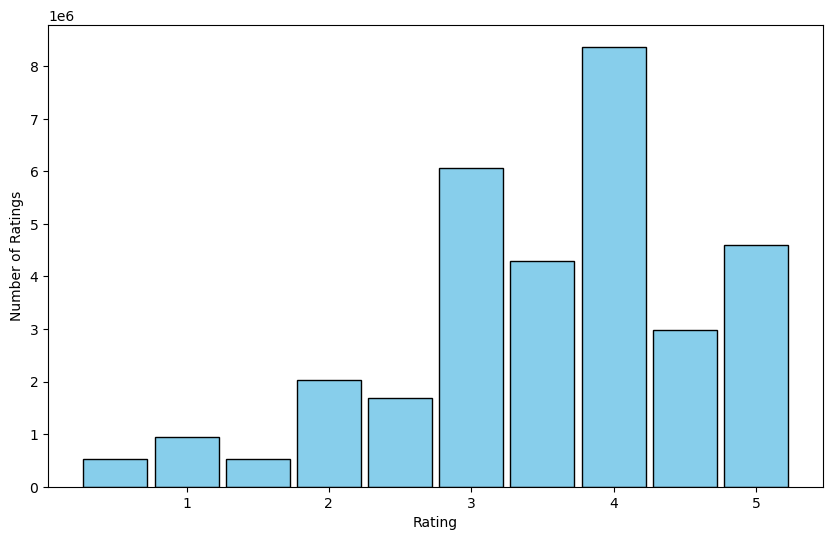

In [8]:
# -------------------------------
# Plot the rating distribution
# -------------------------------
plt.figure(figsize=(10, 6))
# Collect all ratings in one list
all_ratings = [rating for ratings in data_by_user for _, rating in ratings]

# Count occurrences of each rating
rating_counts = defaultdict(float)
for r in all_ratings:
    rating_counts[r] += 1

# Sort the ratings
ratings = sorted(rating_counts.keys())
counts = [rating_counts[r] for r in ratings]

# Plot the distribution using plt.bar
plt.bar(ratings, counts, width=0.45, color='skyblue', edgecolor='black')
plt.xlabel('Rating')
plt.ylabel('Number of Ratings')
#plt.title('Distribution of Movie Ratings')
plt.savefig("rating_distribution.pdf", format="pdf")
plt.show()

In [9]:
ratings = sorted(rating_counts.keys())

In [10]:
ratings

[0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]

<Figure size 640x480 with 0 Axes>

# PART 4:Are there power laws in the data? Is it scale-free? (Note that each user rated at least 20 movies. Truncation will skew the power law that you’d expect…)

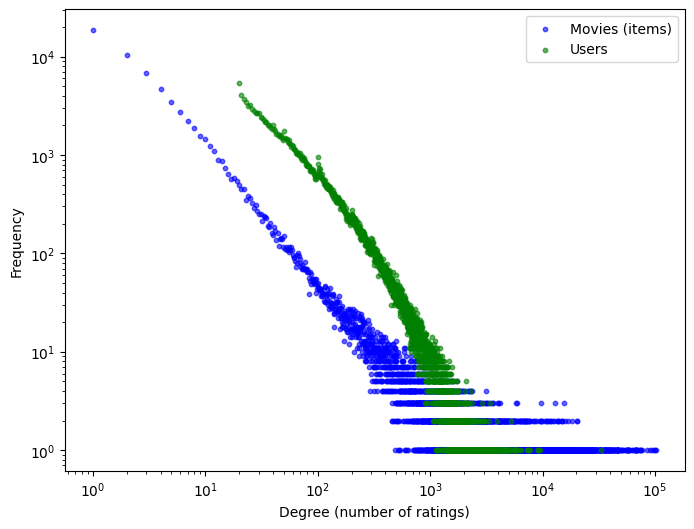

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Count the number of ratings per user
user_degrees = [len(ratings_list) for ratings_list in data_by_user]

# Count the number of ratings per movie
movie_degrees = [len(ratings_list) for ratings_list in data_by_movie]

# Define a helper function to plot distributions on a log-log scale
def plot_power_law(degrees, label, color):
    values, counts = np.unique(degrees, return_counts=True)
    plt.scatter(values, counts, s=10, alpha=0.6, label=label, color=color)

# Create the plot
plt.figure(figsize=(8,6))
plot_power_law(movie_degrees, label='Movies (items)', color='blue')
plot_power_law(user_degrees, label='Users', color='green')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Degree (number of ratings)')
plt.ylabel('Frequency')
#plt.title('Power-law Distribution of Users and Movies')
plt.legend()
plt.savefig("Power-law Distribution of Users and Movies.pdf", format="pdf")
plt.show()

## Smal desciptives analyses

# Partie 5

## Split the dataset

In [20]:


# --- Initialize training and testing data structures as lists ---
n_users = len(data_by_user)
n_movies = len(data_by_movie)

data_by_user_train = [[] for _ in range(n_users)]
data_by_user_test = [[] for _ in range(n_users)]
data_by_movie_train = [[] for _ in range(n_movies)]
data_by_movie_test = [[] for _ in range(n_movies)]

# --- Split the data for each user ---
for user_idx, ratings in enumerate(data_by_user):
    # Shuffle the ratings for the current user
    random.shuffle(ratings)

    # Determine the split point (80% for training, 20% for testing)
    split_point = int(0.9 * len(ratings))

    # Populate training and testing sets

    for i, (movie_idx, rating) in enumerate(ratings):
        if i < split_point:
            # Add to training sets
            data_by_user_train[user_idx].append((movie_idx, rating))
            data_by_movie_train[movie_idx].append((user_idx, rating))
        else:
            # Add to testing sets
            data_by_user_test[user_idx].append((movie_idx, rating))
            data_by_movie_test[movie_idx].append((user_idx, rating))

# --- Optional: Print some statistics to verify the split ---
print(f"Number of users in training set: {len(data_by_user_train)}")
print(f"Number of users in test set: {len(data_by_user_test)}")
print(f"Number of movies in training set: {len(data_by_movie_train)}")
print(f"Number of movies in test set: {len(data_by_movie_test)}")


Number of users in training set: 200948
Number of users in test set: 200948
Number of movies in training set: 84432
Number of movies in test set: 84432


## Datrain and test structure

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter


# Count ratings in each set
n_train_ratings = sum(len(ratings) for ratings in data_by_user_train)
n_test_ratings = sum(len(ratings) for ratings in data_by_user_test)
n_total_ratings = n_train_ratings + n_test_ratings

# Extract all ratings for distribution analysis
train_ratings_values = []
test_ratings_values = []

for user_ratings in data_by_user_train:
    for movie_idx, rating in user_ratings:
        train_ratings_values.append(rating)

for user_ratings in data_by_user_test:
    for movie_idx, rating in user_ratings:
        test_ratings_values.append(rating)

train_ratings_values = np.array(train_ratings_values)
test_ratings_values = np.array(test_ratings_values)

# Count users and movies with ratings in each set
n_users_with_train = sum(1 for ratings in data_by_user_train if len(ratings) > 0)
n_users_with_test = sum(1 for ratings in data_by_user_test if len(ratings) > 0)
n_movies_with_train = sum(1 for ratings in data_by_movie_train if len(ratings) > 0)
n_movies_with_test = sum(1 for ratings in data_by_movie_test if len(ratings) > 0)

# Ratings per user/movie statistics
ratings_per_user_train = [len(ratings) for ratings in data_by_user_train]
ratings_per_user_test = [len(ratings) for ratings in data_by_user_test]
ratings_per_movie_train = [len(ratings) for ratings in data_by_movie_train]
ratings_per_movie_test = [len(ratings) for ratings in data_by_movie_test]





# Helper function to print formatted tables
def print_table(headers, rows, col_widths=None):
    """Print a formatted table"""
    if col_widths is None:
        col_widths = [max(len(str(row[i])) for row in [headers] + rows) + 2 
                      for i in range(len(headers))]
    
    # Print header
    header_line = "│".join(f" {headers[i]:<{col_widths[i]-1}}" for i in range(len(headers)))
    separator = "─" * (sum(col_widths) + len(headers) - 1)
    
    print("┌" + separator + "┐")
    print("│" + header_line + "│")
    print("├" + separator + "┤")
    
    # Print rows
    for row in rows:
        row_line = "│".join(f" {str(row[i]):<{col_widths[i]-1}}" for i in range(len(row)))
        print("│" + row_line + "│")
    
    print("└" + separator + "┘")




In [37]:

train_counts = Counter(train_ratings_values)
test_counts = Counter(test_ratings_values)
rating_values = sorted(set(train_ratings_values) | set(test_ratings_values))

headers4 = ["Rating", "Train Count", "Train %", "Test Count", "Test %"]
rows4 = []
for rating in rating_values:
    train_count = train_counts.get(rating, 0)
    test_count = test_counts.get(rating, 0)
    train_pct = 100 * train_count / n_train_ratings
    test_pct = 100 * test_count / n_test_ratings
    rows4.append([
        f"{rating:.1f}",
        f"{train_count:,}",
        f"{train_pct:.2f}%",
        f"{test_count:,}",
        f"{test_pct:.2f}%"
    ])

print_table(headers4, rows4, col_widths=[10, 15, 12, 15, 12])



# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'white'

# --- PLOT 1: Rating Distribution (Histogram with Percentages) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Calculate percentages
train_percentages = [100 * train_counts.get(r, 0) / n_train_ratings for r in rating_values]
test_percentages = [100 * test_counts.get(r, 0) / n_test_ratings for r in rating_values]

# Training set histogram
bars1 = ax1.bar(rating_values, train_percentages, width=0.4, 
                color='steelblue', alpha=0.8, edgecolor='black')
ax1.set_xlabel('Rating Value', fontsize=13, fontweight='bold')
ax1.set_ylabel('Percentage (%)', fontsize=13, fontweight='bold')
ax1.set_title(f'Training Set: Rating Distribution\n(n={n_train_ratings:,} ratings)', 
              fontsize=14, fontweight='bold', pad=15)
ax1.set_xticks(rating_values)
ax1.grid(axis='y', alpha=0.3)

# Add percentage labels on bars
for bar in bars1:
    height = bar.get_height()
    if height > 0.5:
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=9)

# Test set histogram
bars2 = ax2.bar(rating_values, test_percentages, width=0.4, 
                color='coral', alpha=0.8, edgecolor='black')
ax2.set_xlabel('Rating Value', fontsize=13, fontweight='bold')
ax2.set_ylabel('Percentage (%)', fontsize=13, fontweight='bold')
ax2.set_title(f'Test Set: Rating Distribution\n(n={n_test_ratings:,} ratings)', 
              fontsize=14, fontweight='bold', pad=15)
ax2.set_xticks(rating_values)
ax2.grid(axis='y', alpha=0.3)

# Add percentage labels
for bar in bars2:
    height = bar.get_height()
    if height > 0.5:
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
filename1 = 'rating_distribution_train_test.pdf'
plt.savefig(filename1, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {filename1}")
plt.close()

# --- PLOT 2: Comparison Bar Chart ---
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(rating_values))
width = 0.35

bars1 = ax.bar(x - width/2, train_percentages, width, 
               label='Training Set', color='steelblue', alpha=0.8, edgecolor='black')
bars2 = ax.bar(x + width/2, test_percentages, width, 
               label='Test Set', color='coral', alpha=0.8, edgecolor='black')

ax.set_xlabel('Rating Value', fontsize=13, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=13, fontweight='bold')
ax.set_title('Rating Distribution Comparison: Train vs Test', 
             fontsize=15, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels([f'{r:.1f}' for r in rating_values])
ax.legend(fontsize=12, loc='upper left')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
filename2 = 'rating_distribution_comparison.pdf'
plt.savefig(filename2, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {filename2}")
plt.close()

# --- PLOT 3: Ratings per User Distribution ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Training
ax1.hist(ratings_per_user_train, bins=50, color='steelblue', 
         alpha=0.7, edgecolor='black')
ax1.axvline(np.mean(ratings_per_user_train), color='red', 
            linestyle='--', linewidth=2, label=f'Mean: {np.mean(ratings_per_user_train):.1f}')
ax1.axvline(np.median(ratings_per_user_train), color='orange', 
            linestyle='--', linewidth=2, label=f'Median: {np.median(ratings_per_user_train):.1f}')
ax1.set_xlabel('Number of Ratings per User', fontsize=12, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax1.set_title('Training Set: Ratings per User', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)

# Test
ax2.hist(ratings_per_user_test, bins=50, color='coral', 
         alpha=0.7, edgecolor='black')
ax2.axvline(np.mean(ratings_per_user_test), color='red', 
            linestyle='--', linewidth=2, label=f'Mean: {np.mean(ratings_per_user_test):.1f}')
ax2.axvline(np.median(ratings_per_user_test), color='orange', 
            linestyle='--', linewidth=2, label=f'Median: {np.median(ratings_per_user_test):.1f}')
ax2.set_xlabel('Number of Ratings per User', fontsize=12, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax2.set_title('Test Set: Ratings per User', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
filename3 = 'ratings_per_user_distribution.pdf'
plt.savefig(filename3, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {filename3}")
plt.close()

# --- PLOT 4: Box Plot Comparison ---
fig, ax = plt.subplots(figsize=(10, 7))

data_to_plot = [train_ratings_values, test_ratings_values]
box = ax.boxplot(data_to_plot, labels=['Training Set', 'Test Set'],
                 patch_artist=True, widths=0.6)

# Color the boxes
colors = ['steelblue', 'coral']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('Rating Value', fontsize=13, fontweight='bold')
ax.set_title('Rating Value Distribution: Train vs Test', 
             fontsize=15, fontweight='bold', pad=15)
ax.grid(axis='y', alpha=0.3)

# Add mean markers
means = [train_ratings_values.mean(), test_ratings_values.mean()]
ax.plot([1, 2], means, 'D', color='red', markersize=8, 
        label=f'Mean (Train: {means[0]:.3f}, Test: {means[1]:.3f})')
ax.legend(fontsize=10)

plt.tight_layout()
filename4 = 'rating_boxplot_comparison.pdf'
plt.savefig(filename4, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {filename4}")
plt.close()

# --- PLOT 5: Summary Statistics Visualization ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 5.1: Split Ratio Pie Chart
ax = axes[0, 0]
sizes = [n_train_ratings, n_test_ratings]
labels = [f'Train\n{n_train_ratings:,}\n({n_train_ratings/n_total_ratings:.1%})',
          f'Test\n{n_test_ratings:,}\n({n_test_ratings/n_total_ratings:.1%})']
colors = ['steelblue', 'coral']
ax.pie(sizes, labels=labels, colors=colors, autopct='', startangle=90, 
       textprops={'fontsize': 11, 'fontweight': 'bold'})
ax.set_title('Train/Test Split Ratio', fontsize=13, fontweight='bold', pad=10)

# Plot 5.2: Active Users
ax = axes[0, 1]
categories = ['Train', 'Test']
active_users = [n_users_with_train, n_users_with_test]
bars = ax.bar(categories, active_users, color=['steelblue', 'coral'], 
              alpha=0.8, edgecolor='black')
ax.set_ylabel('Number of Users', fontsize=11, fontweight='bold')
ax.set_title('Active Users with Ratings', fontsize=13, fontweight='bold', pad=10)
ax.grid(axis='y', alpha=0.3)
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 5.3: Sparsity Comparison
ax = axes[1, 0]
categories = ['Train', 'Test']
sparsities = [sparsity_train * 100, sparsity_test * 100]
bars = ax.bar(categories, sparsities, color=['steelblue', 'coral'], 
              alpha=0.8, edgecolor='black')
ax.set_ylabel('Sparsity (%)', fontsize=11, fontweight='bold')
ax.set_title('Matrix Sparsity', fontsize=13, fontweight='bold', pad=10)
ax.grid(axis='y', alpha=0.3)
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 5.4: Mean Rating Comparison
ax = axes[1, 1]
categories = ['Train', 'Test']
mean_ratings = [train_ratings_values.mean(), test_ratings_values.mean()]
bars = ax.bar(categories, mean_ratings, color=['steelblue', 'coral'], 
              alpha=0.8, edgecolor='black')
ax.set_ylabel('Mean Rating', fontsize=11, fontweight='bold')
ax.set_title('Average Rating Value', fontsize=13, fontweight='bold', pad=10)
ax.set_ylim([0, 5])
ax.grid(axis='y', alpha=0.3)
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
filename5 = 'summary_statistics_visualization.pdf'
plt.savefig(filename5, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {filename5}")
plt.close()


print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)
print("\nGenerated visualizations:")
print(f"  1. {filename1} - Side-by-side rating distributions")
print(f"  2. {filename2} - Overlayed comparison")
print(f"  3. {filename3} - Ratings per user distribution")
print(f"  4. {filename4} - Box plot comparison")
print(f"  5. {filename5} - Summary statistics dashboard")
print("\nKey Findings:")
print(f"  • Split ratio: {n_train_ratings/n_total_ratings:.1%} train / {n_test_ratings/n_total_ratings:.1%} test")
print(f"  • Rating distributions are {'similar' if abs(train_ratings_values.mean() - test_ratings_values.mean()) < 0.1 else 'different'}")
print(f"  • Mean rating (train): {train_ratings_values.mean():.3f}")
print(f"  • Mean rating (test): {test_ratings_values.mean():.3f}")
print(f"  • Sparsity (train): {sparsity_train:.2%}")
print(f"  • Sparsity (test): {sparsity_test:.2%}")
print("="*80)

┌────────────────────────────────────────────────────────────────────┐
│ Rating   │ Train Count   │ Train %    │ Test Count    │ Test %     │
├────────────────────────────────────────────────────────────────────┤
│ 0.5      │ 471,165       │ 1.64%      │ 53,967        │ 1.64%      │
│ 1.0      │ 849,657       │ 2.96%      │ 97,018        │ 2.95%      │
│ 1.5      │ 476,812       │ 1.66%      │ 54,251        │ 1.65%      │
│ 2.0      │ 1,821,091     │ 6.34%      │ 207,531       │ 6.31%      │
│ 2.5      │ 1,513,965     │ 5.27%      │ 171,421       │ 5.21%      │
│ 3.0      │ 5,432,680     │ 18.92%     │ 622,310       │ 18.91%     │
│ 3.5      │ 3,852,302     │ 13.42%     │ 437,803       │ 13.30%     │
│ 4.0      │ 7,504,889     │ 26.14%     │ 862,765       │ 26.22%     │
│ 4.5      │ 2,668,579     │ 9.30%      │ 305,421       │ 9.28%      │
│ 5.0      │ 4,118,096     │ 14.34%     │ 478,481       │ 14.54%     │
└────────────────────────────────────────────────────────────────────┘
✓ Save

In [21]:
empty_list_count = 0
for movie_id, ratings_list in enumerate(data_by_movie_test):
    if not ratings_list: # Checks if the list is empty
        empty_list_count += 1

print(f"Number of movies with no test ratings: {empty_list_count}")

Number of movies with no test ratings: 41729


## Implement alternating least squares for biases

Implement the alternating least squares algorithm to find the maximum likelihood estimates for user and item biases using the training data.


## Bias Update Formulas

These equations are solved within the `update_biases` function. They are derived by minimizing a loss function that includes only bias terms and regularization.

### User Biases ($b_m$)

$$
b_m \leftarrow \frac{\lambda \sum_{n \in \Omega_m} (r_{mn} - b_n)}{\lambda |\Omega_m| + \gamma}
$$

* Corresponds to the first loop (`for m in range(M)`).

### Item Biases ($b_n$)

$$
b_n \leftarrow \frac{\lambda \sum_{m \in \Omega_n} (r_{mn} - b_m)}{\lambda |\Omega_n| + \gamma}
$$

* Corresponds to the second loop (`for n in range(N)`).


### Variables
* $r_{mn}$: True rating
* $b_m$: Bias for user $m$ (`user_biases[m]`)
* $b_n$: Bias for item $n$ (`item_biases[n]`)
* $\lambda$: Error weighting parameter (`lambda_reg`)
* $\gamma$: Regularization parameter (`gamma_reg`)
* $\Omega_m$: Set of items rated by user $m$ (`data_by_user_train[m]`)
* $\Omega_n$: Set of users who rated item $n$ (`data_by_movie_train[n]`)
* $|\Omega_m|$: Count of items rated by user $m$ (`item_counter`)
* $|\Omega_n|$: Count of users who rated item $n$ (`item_counter`)

In [22]:
# Prepare flat data structure once (outside the loop)
def prepare_flat_data(data_by_user_arg, data_by_movie_arg, M, N):
    # For users
    user_ratings = []
    user_items = []
    user_start_end = np.zeros((M, 2), dtype=np.int32)

    current_idx = 0
    for m in range(M):
        user_start_end[m, 0] = current_idx
        for n, r in data_by_user_arg[m]:
            user_items.append(n)
            user_ratings.append(r)
            current_idx += 1
        user_start_end[m, 1] = current_idx

    # For items
    item_ratings = []
    item_users = []
    item_start_end = np.zeros((N, 2), dtype=np.int32)

    current_idx = 0

    for n in range(N):
        item_start_end[n, 0] = current_idx
        for m, r in data_by_movie_arg[n]:
            item_users.append(m)
            item_ratings.append(r)
            current_idx += 1
        item_start_end[n, 1] = current_idx

    return (np.array(user_ratings, dtype=np.float32),
            np.array(user_items, dtype=np.int32),
            user_start_end,
            np.array(item_ratings, dtype=np.float32),
            np.array(item_users, dtype=np.int32),
            item_start_end)

In [13]:
from numba import njit, prange
import numpy as np

@njit(parallel=True)
def update_biases(M, N, user_ratings, user_items, user_start_end,
                  item_ratings, item_users, item_start_end,
                  user_biases, item_biases, lambda_reg, gamma_reg):
    """
    Single function that updates both user and item biases using:
    - Flat lists for ratings and items
    - Start/end indices for each user/item
    - Single loops (range-based)
    - Parallelization with prange
    """

    # Update user biases
    for m in prange(M):  # Parallelization over users
        start = user_start_end[m, 0]
        end = user_start_end[m, 1]

        if end > start:
            bias_sum = 0.0
            count = end - start

            # Single loop over ratings for this user
            for idx in range(start, end):
                n = user_items[idx]
                r = user_ratings[idx]
                bias_sum += lambda_reg * (r - item_biases[n])

            user_biases[m] = bias_sum / (lambda_reg * count + gamma_reg)

    # Update item biases
    for n in prange(N):  # Parallelization over items
        start = item_start_end[n, 0]
        end = item_start_end[n, 1]

        if end > start:
            bias_sum = 0.0
            count = end - start

            # Single loop over ratings for this item
            for idx in range(start, end):
                m = item_users[idx]
                r = item_ratings[idx]
                bias_sum += lambda_reg * (r - user_biases[m])

            item_biases[n] = bias_sum / (lambda_reg * count + gamma_reg)

    return user_biases, item_biases



## Function to compute the loss


$$
-L = \sum_{(m,n) \in \Omega} (r_{mn} - (b_m + b_n))^2 + \lambda \sum_{m} b_m^2/2 + \gamma \sum_{n} b_n^2/2
$$

In [23]:
from numba import njit, prange
import numpy as np

@njit(parallel=True)


def calculate_loss(user_ratings, user_items, user_start_end, M,
                   user_biases, item_biases, lambda_reg, gamma_reg):
    """
    Compute the squared error loss for a bias-only recommender model using:
    - Flat lists for ratings and items
    - Start/end indices for each user
    - Single loops (range-based)
    - Parallelization with prange

    Parameters
    ----------
    user_ratings : np.array
        Flat array of all ratings
    user_items : np.array
        Flat array of all item indices
    user_start_end : np.array
        Array of shape (M, 2) where [m, 0] is start index and [m, 1] is end index
    M : int
        Number of users
    user_biases : np.array
        Bias for each user
    item_biases : np.array
        Bias for each item
    lambda_reg : float
        Regularization strength for user biases
    gamma_reg : float
        Regularization strength for item biases

    Returns
    -------
    float
        The total loss (MSE + regularization)
    """

    # Use array to accumulate results from parallel threads
    squared_errors = np.zeros(M, dtype=np.float32)

    for m in prange(M):  # Parallelization over users
        start = user_start_end[m, 0]
        end = user_start_end[m, 1]

        local_squared_error = 0.0

        # Single loop over ratings for this user
        for idx in range(start, end):
            n = user_items[idx]
            r = user_ratings[idx]
            prediction = user_biases[m] + item_biases[n]
            local_squared_error += (r - prediction) ** 2

        squared_errors[m] = local_squared_error

    # Aggregate squared errors
    total_loss = np.sum(squared_errors)

    # Add regularization terms
    total_loss += 0.5*lambda_reg * np.sum(user_biases ** 2)+0.5*gamma_reg * np.sum(item_biases ** 2)
    total_loss += gamma_reg * np.sum(item_biases ** 2)

    return total_loss

$$
\text{RMSE} = \sqrt{\frac{1}{|\Omega|} \sum_{(m,n) \in \Omega} (r_{mn} - (b_m + b_n))^2}
$$


## Function to compute RMSE


In [24]:


@njit(parallel=True)
def calculate_rmse(user_ratings, user_items, user_start_end, M,
                   user_biases, item_biases):
    """
    Computes the Root Mean Squared Error (RMSE) using:
    - Flat lists for ratings and items
    - Start/end indices for each user
    - Single loops (range-based)
    - Parallelization with prange
    """
    # Use array to accumulate results from parallel threads
    squared_errors = np.zeros(M, dtype=np.float32)
    counts = np.zeros(M, dtype=np.int32)

    for m in prange(M):  # Parallelization over users
        start = user_start_end[m, 0]
        end = user_start_end[m, 1]

        local_squared_error = 0.0
        local_count = 0

        # Single loop over ratings for this user
        for idx in range(start, end):
            n = user_items[idx]
            r = user_ratings[idx]
            prediction = user_biases[m] + item_biases[n]
            local_squared_error += (r - prediction) ** 2
            local_count += 1

        squared_errors[m] = local_squared_error
        counts[m] = local_count

    # Aggregate results
    total_squared_error = np.sum(squared_errors)
    total_count = np.sum(counts)

    if total_count == 0:
        return 0.0

    return np.sqrt(total_squared_error / total_count)


## Main function (training + metric tracking)


In [25]:
def calculate_for_plot(M, N,  user_ratings_train, user_items_train, user_start_end_train, \
    item_ratings_train, item_users_train, item_start_end_train , user_ratings_test, user_items_test, user_start_end_test,
                       lambda_reg, gamma_reg, num_iterations):
    """
    Runs the ALS training loop and records performance metrics for each iteration.
    Uses flat data structures with start/end indices for efficiency.
    """
    # Initialize biases
    user_biases = np.zeros(M, dtype=np.float32)
    item_biases = np.zeros(N, dtype=np.float32)

    # Prepare flat data structures once (before training loop)
    print("Preparing flat data structures...")



    loss_train, loss_test, rmse_train, rmse_test = [], [], [], []

    print("Starting Alternating Least Squares for biases...")

    for iteration in range(num_iterations):
        # Update biases using flat data structures
        user_biases, item_biases = update_biases(
            M, N,
            user_ratings_train, user_items_train, user_start_end_train,
            item_ratings_train, item_users_train, item_start_end_train,
            user_biases, item_biases, lambda_reg, gamma_reg
        )

        # Compute metrics using flat data structures
        loss_train.append(calculate_loss(
            user_ratings_train, user_items_train, user_start_end_train, M,
            user_biases, item_biases, lambda_reg, gamma_reg
        ))

        rmse_train.append(calculate_rmse(
            user_ratings_train, user_items_train, user_start_end_train, M,
            user_biases, item_biases
        ))

        rmse_test.append(calculate_rmse(
            user_ratings_test, user_items_test, user_start_end_test, M,
            user_biases, item_biases
        ))

        loss_test.append(calculate_loss(
            user_ratings_test, user_items_test, user_start_end_test, M,
            user_biases, item_biases, lambda_reg, gamma_reg
        ))

        if (iteration + 1) % 10 == 0 or iteration == 0:
            print(f"Iteration {iteration+1}/{num_iterations} | "
                  f"Train RMSE: {rmse_train[-1]:.4f} | Test RMSE: {rmse_test[-1]:.4f}")

    print("Alternating Least Squares for biases completed.")
    return user_biases, item_biases, loss_train, loss_test, rmse_train, rmse_test


In [17]:
M = len(user_to_index)
N = len(movie_to_index)
lambda_reg = 0.3
gamma_reg = 0.002
num_iterations = 50

best parameters

In [19]:
# lambda_reg         0.050000
# gamma_reg          0.020000

In [18]:
M = len(user_to_index)
N = len(movie_to_index)
lambda_reg = 0.05
gamma_reg = 0.02
num_iterations = 20

In [26]:
# Training data
user_ratings_train, user_items_train, user_start_end_train, \
item_ratings_train, item_users_train, item_start_end_train = \
  prepare_flat_data(data_by_user_train, data_by_movie_train, M, N)

# Test data (only need user data for metrics)
user_ratings_test, user_items_test, user_start_end_test, _, _, _ = \
  prepare_flat_data(data_by_user_test, data_by_movie_train, M, N)

In [48]:
user_biases, item_biases, loss_train, loss_test, rmse_train, rmse_test = calculate_for_plot(
    M, N,  user_ratings_train, user_items_train, user_start_end_train, \
    item_ratings_train, item_users_train, item_start_end_train , user_ratings_test, user_items_test, user_start_end_test,
                       lambda_reg, gamma_reg, num_iterations
)

Preparing flat data structures...
Starting Alternating Least Squares for biases...
Iteration 1/50 | Train RMSE: 0.8616 | Test RMSE: 0.8719
Iteration 10/50 | Train RMSE: 0.8461 | Test RMSE: 0.8562
Iteration 20/50 | Train RMSE: 0.8461 | Test RMSE: 0.8562
Iteration 30/50 | Train RMSE: 0.8461 | Test RMSE: 0.8562
Iteration 40/50 | Train RMSE: 0.8461 | Test RMSE: 0.8562
Iteration 50/50 | Train RMSE: 0.8461 | Test RMSE: 0.8562
Alternating Least Squares for biases completed.


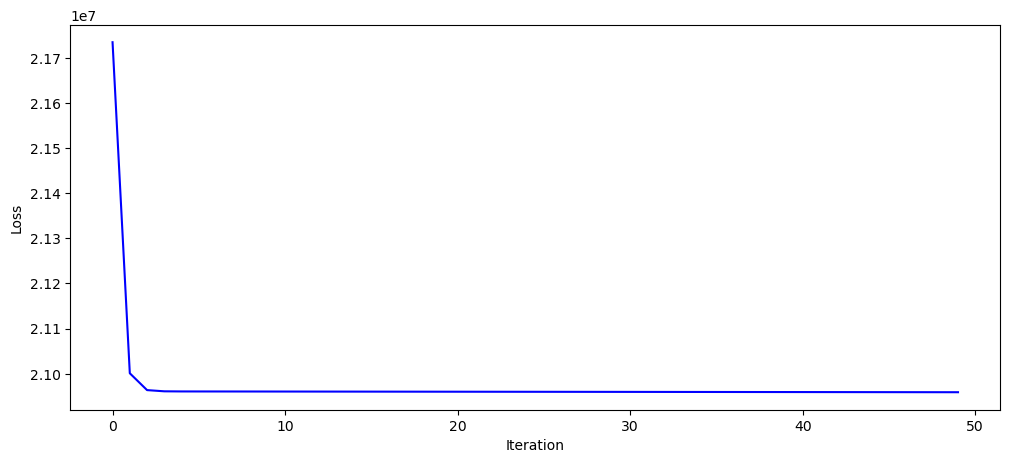

In [52]:


plt.figure(figsize=(12, 5))

    # Loss curve
#plt.subplot(1, 2, 1)
plt.plot(loss_train, label='Train Loss', color='blue')
#plt.plot(loss_test, label='Test Loss', color='orange')
#plt.title("Loss for the train")
plt.xlabel("Iteration")
plt.ylabel("Loss")
#plt.legend()

plt.savefig("Loss_train_bias_only.pdf", format="pdf")
plt.show()


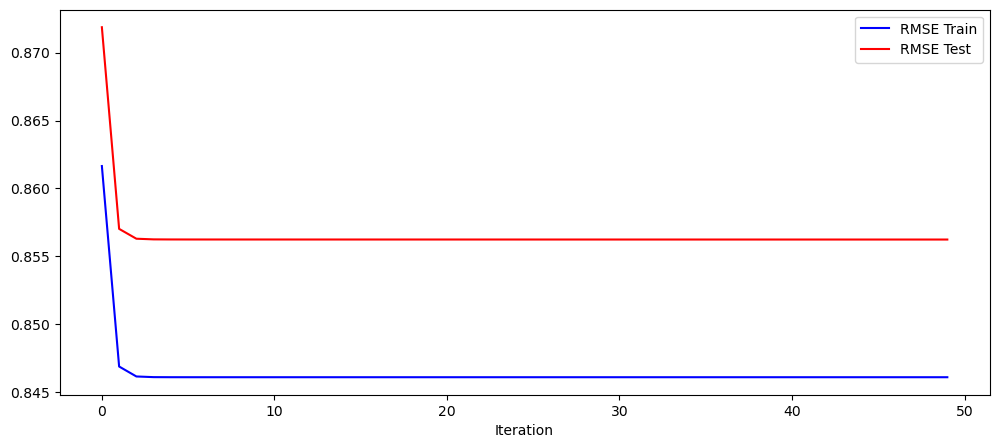

In [ ]:


plt.figure(figsize=(12, 5))


#plt.subplot(1, 2, 1)
plt.plot(rmse_train, color='blue',label="RMSE Train")
plt.plot(rmse_test, color='red',label="RMSE Test")
#plt.title("RMSE train")
plt.xlabel("Iteration")
#plt.ylabel("RMSE")
#plt.plot(loss_test, label='Test Loss', color='orange')
#plt.title("RMSE train")
#plt.xlabel("Iteration")
#plt.ylabel("RMSE")
#plt.legend()

    # RMSE curve
#plt.subplot(1, 2, 2)
#plt.plot(rmse_train, label='Trai', color='green')

#plt.title("RMSE Test")
#plt.xlabel("Iteration")
#plt.ylabel("RMSE")
plt.legend()
plt.savefig("RMSE_train_test_bias_only.pdf", format="pdf")
#plt.tight_layout()
plt.show()


## Optimisation des hyperparametres for the model without bias

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from joblib import Parallel, delayed




def run_model_once(M, N,
                   user_ratings_train, user_items_train, user_start_end_train,
                   item_ratings_train, item_users_train, item_start_end_train,
                   user_ratings_test, user_items_test, user_start_end_test,
                   lambda_reg, gamma_reg, num_iterations):
    """
    Execute model training once with given hyperparameters
    Used by parallel processing in grid/random search
    """
    try:
        user_biases, item_biases, loss_train, loss_test, rmse_train, rmse_test = \
            calculate_for_plot(
                M, N,
                user_ratings_train, user_items_train, user_start_end_train,
                item_ratings_train, item_users_train, item_start_end_train,
                user_ratings_test, user_items_test, user_start_end_test,
                lambda_reg, gamma_reg, num_iterations
            )

        return {
            "lambda_reg": lambda_reg,
            "gamma_reg": gamma_reg,
            "rmse_test": rmse_test[-1],
            "rmse_train": rmse_train[-1],
            "overfitting_gap": rmse_test[-1] - rmse_train[-1],
            "error": None
        }

    except Exception as e:
        return {
            "lambda_reg": lambda_reg,
            "gamma_reg": gamma_reg,
            "rmse_test": np.inf,
            "rmse_train": np.inf,
            "overfitting_gap": np.inf,
            "error": str(e)
        }


def grid_search_bias_model(M, N,
                           user_ratings_train, user_items_train, user_start_end_train,
                           item_ratings_train, item_users_train, item_start_end_train,
                           user_ratings_test, user_items_test, user_start_end_test,
                           num_iterations=50):
    """
    Perform parallel grid search over hyperparameter space
    Returns: best_lambda, best_gamma, all_results
    """
    print("="*80)
    print("GRID SEARCH - PARALLEL BIAS-ONLY MODEL")
    print("="*80)

    lambda_values = [0.001, 0.005, 0.01, 0.05, 0.1]
    gamma_values = [0.001, 0.005, 0.01, 0.02, 0.05]

    hyperparam_list = [
        (lam, gam)
        for lam in lambda_values
        for gam in gamma_values
    ]

    print(f"Total combinations = {len(hyperparam_list)}")
    print("Running in PARALLEL...")

    results = Parallel(n_jobs=-1)(
        delayed(run_model_once)(
            M, N,
            user_ratings_train, user_items_train, user_start_end_train,
            item_ratings_train, item_users_train, item_start_end_train,
            user_ratings_test, user_items_test, user_start_end_test,
            lam, gam, num_iterations
        )
        for (lam, gam) in hyperparam_list
    )

    # Filter valid results (without inf values)
    valid_results = [r for r in results if r["rmse_test"] != np.inf]
    
    if len(valid_results) == 0:
        raise ValueError("No valid results found!")

    # Find best result
    best = min(valid_results, key=lambda x: x["rmse_test"])

    print("\n🏆 BEST PARAMETERS")
    print(f"  lambda_reg: {best['lambda_reg']}")
    print(f"  gamma_reg: {best['gamma_reg']}")
    print(f"  rmse_test: {best['rmse_test']}")
    print(f"  rmse_train: {best['rmse_train']}")
    print(f"  overfitting_gap: {best['overfitting_gap']}")

    return best["lambda_reg"], best["gamma_reg"], results


def random_search_bias_model(M, N,
                             user_ratings_train, user_items_train, user_start_end_train,
                             item_ratings_train, item_users_train, item_start_end_train,
                             user_ratings_test, user_items_test, user_start_end_test,
                             n_iterations=30, num_iterations_model=50):
    """
    Perform parallel random search over hyperparameter space
    Returns: best_lambda, best_gamma, all_results
    """
    print("="*80)
    print("RANDOM SEARCH - PARALLEL BIAS-ONLY MODEL")
    print("="*80)

    lambda_min, lambda_max = 0.001, 0.1
    gamma_min, gamma_max = 0.001, 0.05

    random_params = [
        (np.random.uniform(lambda_min, lambda_max),
         np.random.uniform(gamma_min, gamma_max))
        for _ in range(n_iterations)
    ]

    print(f"Total random combinations = {n_iterations}")
    print("Running in PARALLEL...")

    results = Parallel(n_jobs=-1)(
        delayed(run_model_once)(
            M, N,
            user_ratings_train, user_items_train, user_start_end_train,
            item_ratings_train, item_users_train, item_start_end_train,
            user_ratings_test, user_items_test, user_start_end_test,
            lam, gam, num_iterations_model
        )
        for (lam, gam) in random_params
    )

    # Filter valid results
    valid_results = [r for r in results if r["rmse_test"] != np.inf]
    
    if len(valid_results) == 0:
        raise ValueError("No valid results found!")

    # Find best result
    best = min(valid_results, key=lambda x: x["rmse_test"])

    print("\n🏆 BEST PARAMETERS FROM RANDOM SEARCH")
    print(f"  lambda_reg: {best['lambda_reg']}")
    print(f"  gamma_reg: {best['gamma_reg']}")
    print(f"  rmse_test: {best['rmse_test']}")
    print(f"  rmse_train: {best['rmse_train']}")
    print(f"  overfitting_gap: {best['overfitting_gap']}")

    return best["lambda_reg"], best["gamma_reg"], results




def analyser_donnees(resultats):
    """
    Analyze and prepare data for visualization
    Returns: dict with all necessary statistics
    """
    # Handle tuple input from grid_search/random_search
    if isinstance(resultats, tuple):
        # Extract the results list (third element of tuple)
        if len(resultats) == 3:
            resultats = resultats[2]
        else:
            print(f"Unexpected tuple length: {len(resultats)}")
            return None
    
    # Ensure resultats is a list
    if isinstance(resultats, dict):
        resultats = [resultats]
    elif not isinstance(resultats, list):
        print(f"Type of resultats: {type(resultats)}")
        return None
    
    # Filter valid results
    results = []
    for r in resultats:
        if isinstance(r, dict) and "rmse_test" in r and r["rmse_test"] != np.inf:
            results.append(r)
    
    if len(results) == 0:
        print("No valid results found")
        return None
    
    # Group by lambda
    lambda_grouped = {}
    for r in results:
        key = r['lambda_reg']
        if key not in lambda_grouped:
            lambda_grouped[key] = []
        lambda_grouped[key].append(r)
    
    # Group by gamma
    gamma_grouped = {}
    for r in results:
        key = r['gamma_reg']
        if key not in gamma_grouped:
            gamma_grouped[key] = []
        gamma_grouped[key].append(r)
    
    # Statistics by lambda
    lambda_vals = sorted(lambda_grouped.keys())
    lambda_test_mean = [np.mean([r['rmse_test'] for r in lambda_grouped[k]]) for k in lambda_vals]
    lambda_test_std = [np.std([r['rmse_test'] for r in lambda_grouped[k]]) for k in lambda_vals]
    lambda_train_mean = [np.mean([r['rmse_train'] for r in lambda_grouped[k]]) for k in lambda_vals]
    lambda_train_std = [np.std([r['rmse_train'] for r in lambda_grouped[k]]) for k in lambda_vals]
    lambda_overfit_mean = [np.mean([r['overfitting_gap'] for r in lambda_grouped[k]]) for k in lambda_vals]
    lambda_overfit_std = [np.std([r['overfitting_gap'] for r in lambda_grouped[k]]) for k in lambda_vals]
    
    # Statistics by gamma
    gamma_vals = sorted(gamma_grouped.keys())
    gamma_test_mean = [np.mean([r['rmse_test'] for r in gamma_grouped[k]]) for k in gamma_vals]
    gamma_test_std = [np.std([r['rmse_test'] for r in gamma_grouped[k]]) for k in gamma_vals]
    gamma_train_mean = [np.mean([r['rmse_train'] for r in gamma_grouped[k]]) for k in gamma_vals]
    gamma_train_std = [np.std([r['rmse_train'] for r in gamma_grouped[k]]) for k in gamma_vals]
    gamma_overfit_mean = [np.mean([r['overfitting_gap'] for r in gamma_grouped[k]]) for k in gamma_vals]
    gamma_overfit_std = [np.std([r['overfitting_gap'] for r in gamma_grouped[k]]) for k in gamma_vals]
    
    # Pivot tables for heatmaps
    row_labels = sorted(set(r['lambda_reg'] for r in results))
    col_labels = sorted(set(r['gamma_reg'] for r in results))
    
    matrix_rmse = np.full((len(row_labels), len(col_labels)), np.nan)
    matrix_overfit = np.full((len(row_labels), len(col_labels)), np.nan)
    
    for r in results:
        row_idx = row_labels.index(r['lambda_reg'])
        col_idx = col_labels.index(r['gamma_reg'])
        matrix_rmse[row_idx, col_idx] = r['rmse_test']
        matrix_overfit[row_idx, col_idx] = r['overfitting_gap']
    
    # Best result
    best = min(results, key=lambda x: x['rmse_test'])
    
    # Top 10
    top_10 = sorted(results, key=lambda x: x['rmse_test'])[:10]
    
    return {
        'results': results,
        'best': best,
        'top_10': top_10,
        'lambda': {
            'vals': np.array(lambda_vals),
            'test_mean': np.array(lambda_test_mean),
            'test_std': np.array(lambda_test_std),
            'train_mean': np.array(lambda_train_mean),
            'train_std': np.array(lambda_train_std),
            'overfit_mean': np.array(lambda_overfit_mean),
            'overfit_std': np.array(lambda_overfit_std)
        },
        'gamma': {
            'vals': np.array(gamma_vals),
            'test_mean': np.array(gamma_test_mean),
            'test_std': np.array(gamma_test_std),
            'train_mean': np.array(gamma_train_mean),
            'train_std': np.array(gamma_train_std),
            'overfit_mean': np.array(gamma_overfit_mean),
            'overfit_std': np.array(gamma_overfit_std)
        },
        'heatmap': {
            'row_labels': row_labels,
            'col_labels': col_labels,
            'matrix_rmse': matrix_rmse,
            'matrix_overfit': matrix_overfit
        }
    }


def creer_graphiques(data):
    """
    Create all 8 subplots for visualization
    """
    fig = plt.figure(figsize=(20, 12))
    
   
    ax1 = plt.subplot(2, 4, 1)
    ax1.errorbar(data['lambda']['vals'], data['lambda']['test_mean'],
                 yerr=data['lambda']['test_std'], marker='o', linewidth=2,
                 markersize=8, label='Test RMSE', capsize=5)
    ax1.errorbar(data['lambda']['vals'], data['lambda']['train_mean'],
                 yerr=data['lambda']['train_std'], marker='s', linewidth=2,
                 markersize=8, label='Train RMSE', capsize=5, alpha=0.7)
    ax1.set_xlabel('Lambda (Regularization)', fontweight='bold', fontsize=11)
    ax1.set_ylabel('RMSE', fontweight='bold', fontsize=11)
    ax1.set_title('Impact of Lambda on RMSE\n(mean ± std)', fontweight='bold', fontsize=11)
    ax1.legend(loc='best')
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.set_xscale('log')
    
    # ========== SUBPLOT 2: Gamma Impact on RMSE ==========
    ax2 = plt.subplot(2, 4, 2)
    ax2.errorbar(data['gamma']['vals'], data['gamma']['test_mean'],
                 yerr=data['gamma']['test_std'], marker='o', linewidth=2,
                 markersize=8, label='Test RMSE', capsize=5, color='coral')
    ax2.errorbar(data['gamma']['vals'], data['gamma']['train_mean'],
                 yerr=data['gamma']['train_std'], marker='s', linewidth=2,
                 markersize=8, label='Train RMSE', capsize=5, alpha=0.7, color='lightcoral')
    ax2.set_xlabel('Gamma (Learning Rate)', fontweight='bold', fontsize=11)
    ax2.set_ylabel('RMSE', fontweight='bold', fontsize=11)
    ax2.set_title('Impact of Gamma on RMSE\n(mean ± std)', fontweight='bold', fontsize=11)
    ax2.legend(loc='best')
    ax2.grid(True, alpha=0.3, linestyle='--')
    ax2.set_xscale('log')
    
    # ========== SUBPLOT 3: Lambda Impact on Overfitting ==========
    ax3 = plt.subplot(2, 4, 3)
    ax3.errorbar(data['lambda']['vals'], data['lambda']['overfit_mean'],
                 yerr=data['lambda']['overfit_std'], marker='D', linewidth=2.5,
                 markersize=8, color='purple', capsize=5, label='Overfitting Gap')
    ax3.axhline(y=0, color='green', linestyle='--', linewidth=2, alpha=0.5, label='Perfect fit')
    ax3.set_xlabel('Lambda (Regularization)', fontweight='bold', fontsize=11)
    ax3.set_ylabel('Overfitting Gap (Test - Train)', fontweight='bold', fontsize=11)
    ax3.set_title('Impact of Lambda on Overfitting\n(Lower is better)', fontweight='bold', fontsize=11)
    ax3.legend(loc='best')
    ax3.grid(True, alpha=0.3, linestyle='--')
    ax3.set_xscale('log')
    

    ax4 = plt.subplot(2, 4, 4)
    ax4.errorbar(data['gamma']['vals'], data['gamma']['overfit_mean'],
                 yerr=data['gamma']['overfit_std'], marker='D', linewidth=2.5,
                 markersize=8, color='darkgreen', capsize=5, label='Overfitting Gap')
    ax4.axhline(y=0, color='green', linestyle='--', linewidth=2, alpha=0.5, label='Perfect fit')
    ax4.set_xlabel('Gamma (Learning Rate)', fontweight='bold', fontsize=11)
    ax4.set_ylabel('Overfitting Gap (Test - Train)', fontweight='bold', fontsize=11)
    ax4.set_title('Impact of Gamma on Overfitting\n(Lower is better)', fontweight='bold', fontsize=11)
    ax4.legend(loc='best')
    ax4.grid(True, alpha=0.3, linestyle='--')
    ax4.set_xscale('log')
    

    ax5 = plt.subplot(2, 4, 5)
    im5 = ax5.imshow(data['heatmap']['matrix_rmse'], cmap='RdYlGn_r', aspect='auto')
    for i in range(len(data['heatmap']['row_labels'])):
        for j in range(len(data['heatmap']['col_labels'])):
            if not np.isnan(data['heatmap']['matrix_rmse'][i, j]):
                ax5.text(j, i, f"{data['heatmap']['matrix_rmse'][i, j]:.4f}",
                        ha="center", va="center", color="black", fontsize=8)
    ax5.set_xticks(range(len(data['heatmap']['col_labels'])))
    ax5.set_yticks(range(len(data['heatmap']['row_labels'])))
    ax5.set_xticklabels([f'{v:.3f}' for v in data['heatmap']['col_labels']], rotation=45, ha='right')
    ax5.set_yticklabels([f'{v:.3f}' for v in data['heatmap']['row_labels']])
    ax5.set_xlabel('Gamma (Learning Rate)', fontweight='bold')
    ax5.set_ylabel('Lambda (Regularization)', fontweight='bold')
    ax5.set_title('RMSE Test: Lambda × Gamma Interaction', fontweight='bold', fontsize=11)
    plt.colorbar(im5, ax=ax5, label='RMSE Test')
    
    ax6 = plt.subplot(2, 4, 6)
    vmax = max(abs(np.nanmin(data['heatmap']['matrix_overfit'])), abs(np.nanmax(data['heatmap']['matrix_overfit'])))
    im6 = ax6.imshow(data['heatmap']['matrix_overfit'], cmap='coolwarm', aspect='auto',
                     vmin=-vmax, vmax=vmax)
    for i in range(len(data['heatmap']['row_labels'])):
        for j in range(len(data['heatmap']['col_labels'])):
            if not np.isnan(data['heatmap']['matrix_overfit'][i, j]):
                ax6.text(j, i, f"{data['heatmap']['matrix_overfit'][i, j]:.4f}",
                        ha="center", va="center", color="black", fontsize=8)
    ax6.set_xticks(range(len(data['heatmap']['col_labels'])))
    ax6.set_yticks(range(len(data['heatmap']['row_labels'])))
    ax6.set_xticklabels([f'{v:.3f}' for v in data['heatmap']['col_labels']], rotation=45, ha='right')
    ax6.set_yticklabels([f'{v:.3f}' for v in data['heatmap']['row_labels']])
    ax6.set_xlabel('Gamma (Learning Rate)', fontweight='bold')
    ax6.set_ylabel('Lambda (Regularization)', fontweight='bold')
    ax6.set_title('Overfitting Gap: Lambda × Gamma', fontweight='bold', fontsize=11)
    plt.colorbar(im6, ax=ax6, label='Overfitting Gap')
    

    ax7 = plt.subplot(2, 4, 7)
    overfitting_gaps = [r['overfitting_gap'] for r in data['results']]
    rmse_tests = [r['rmse_test'] for r in data['results']]
    lambdas = [r['lambda_reg'] for r in data['results']]
    scatter = ax7.scatter(overfitting_gaps, rmse_tests, c=lambdas, cmap='viridis',
                         s=150, alpha=0.7, edgecolors='black', linewidth=1.5)
    ax7.scatter(data['best']['overfitting_gap'], data['best']['rmse_test'],
               s=300, marker='*', color='red', edgecolors='black',
               linewidth=2, label='Best model', zorder=5)
    ax7.set_xlabel('Overfitting Gap (Test - Train)', fontweight='bold', fontsize=11)
    ax7.set_ylabel('RMSE Test', fontweight='bold', fontsize=11)
    ax7.set_title('Performance vs Overfitting Trade-off\n(color = lambda value)',
                  fontweight='bold', fontsize=11)
    ax7.legend(loc='best')
    ax7.grid(True, alpha=0.3, linestyle='--')
    plt.colorbar(scatter, ax=ax7, label='Lambda')
    
 
    ax8 = plt.subplot(2, 4, 8)
    labels = [f"λ={r['lambda_reg']:.3f}\nγ={r['gamma_reg']:.3f}" for r in data['top_10']]
    rmse_values = [r['rmse_test'] for r in data['top_10']]
    overfit_gaps = [r['overfitting_gap'] for r in data['top_10']]
    
    overfit_min = min(overfit_gaps)
    overfit_max = max(overfit_gaps)
    if overfit_max > overfit_min:
        norm_gaps = [(g - overfit_min) / (overfit_max - overfit_min) for g in overfit_gaps]
    else:
        norm_gaps = [0.5] * len(overfit_gaps)
    
    colors = plt.cm.coolwarm(norm_gaps)
    ax8.barh(range(len(data['top_10'])), rmse_values, color=colors,
             edgecolor='black', linewidth=1.5)
    ax8.set_yticks(range(len(data['top_10'])))
    ax8.set_yticklabels(labels, fontsize=9)
    ax8.set_xlabel('RMSE Test', fontweight='bold', fontsize=11)
    ax8.set_title('Top 10 Best Configurations\n(color = overfitting gap)',
                  fontweight='bold', fontsize=11)
    ax8.invert_yaxis()
    ax8.grid(True, alpha=0.3, axis='x', linestyle='--')
    
    plt.tight_layout()
    plt.show()


def afficher_resultats(data):
    """
    Display statistics, tables, and insights
    """
    results = data['results']
    best = data['best']
    
    # General statistics
    rmse_tests = [r['rmse_test'] for r in results]
    overfitting_gaps = [r['overfitting_gap'] for r in results]
    
    print(f"\nNumber of tests: {len(results)}")
    print(f"Best RMSE test: {min(rmse_tests):.4f}")
    print(f"Worst RMSE test: {max(rmse_tests):.4f}")
    print(f"Mean RMSE test: {np.mean(rmse_tests):.4f}")
    print(f"Best overfitting gap: {min(overfitting_gaps):.4f}")
    print(f"Worst overfitting gap: {max(overfitting_gaps):.4f}")
    
    # Top 5 configurations
    print("\n📋 TOP 5 BEST CONFIGURATIONS:")
    print("-" * 110)
    print(f"{'Lambda':<12} {'Gamma':<12} {'RMSE Train':<15} {'RMSE Test':<15} {'Overfitting Gap':<18}")
    print("-" * 110)
    
    for r in data['top_10'][:5]:
        print(f"{r['lambda_reg']:<12.6f} {r['gamma_reg']:<12.6f} "
              f"{r['rmse_train']:<15.6f} {r['rmse_test']:<15.6f} "
              f"{r['overfitting_gap']:<18.6f}")
    print("-" * 110)
    
    # Key insights
    lambda_stds = []
    for val in data['lambda']['vals']:
        group_results = [r for r in results if r['lambda_reg'] == val]
        lambda_stds.append(np.std([r['rmse_test'] for r in group_results]))
    
    gamma_stds = []
    for val in data['gamma']['vals']:
        group_results = [r for r in results if r['gamma_reg'] == val]
        gamma_stds.append(np.std([r['rmse_test'] for r in group_results]))
    
    print("\n KEY INSIGHTS:")
    print(f"  • Best lambda: {best['lambda_reg']:.4f}")
    print(f"  • Best gamma: {best['gamma_reg']:.4f}")
    print(f"  • Lambda sensitivity: {np.mean(lambda_stds):.4f}")
    print(f"  • Gamma sensitivity: {np.mean(gamma_stds):.4f}")


def visualiser_impact_hyperparametres(resultats, search_type="Grid Search"):
    """
    Main function to visualize hyperparameter impact on:
    1. RMSE performance
    2. Overfitting gap (test - train)
    3. Parameter interactions
    """
    print(f"\n HYPERPARAMETER IMPACT ANALYSIS ({search_type})")
    print("="*80)
    
    # Analyze data
    data = analyser_donnees(resultats)
    
    if data is None:
        print("No valid results to visualize!")
        return None
    
    # Display statistics
    afficher_resultats(data)
    
    # Create graphs
    creer_graphiques(data)
    
    return data['results']

In [44]:
results=grid_search_bias_model(
    M, N,
                           user_ratings_train, user_items_train, user_start_end_train,
                           item_ratings_train, item_users_train, item_start_end_train,
                           user_ratings_test, user_items_test, user_start_end_test,
                           num_iterations=50)

GRID SEARCH - PARALLEL BIAS-ONLY MODEL
Total combinations = 25
Running in PARALLEL...

🏆 BEST PARAMETERS
  lambda_reg: 0.05
  gamma_reg: 0.02
  rmse_test: 0.8559686763615734
  rmse_train: 0.8462482433926953
  overfitting_gap: 0.009720432968878034



📊 HYPERPARAMETER IMPACT ANALYSIS (Grid Search)

Number of tests: 25
Best RMSE test: 0.8560
Worst RMSE test: 0.9281
Mean RMSE test: 0.8632
Best overfitting gap: 0.0068
Worst overfitting gap: 0.0101

📋 TOP 5 BEST CONFIGURATIONS:
--------------------------------------------------------------------------------------------------------------
Lambda       Gamma        RMSE Train      RMSE Test       Overfitting Gap   
--------------------------------------------------------------------------------------------------------------
0.050000     0.020000     0.846248        0.855969        0.009720          
0.010000     0.005000     0.846318        0.855978        0.009660          
0.100000     0.050000     0.846318        0.855978        0.009660          
0.005000     0.001000     0.846142        0.856032        0.009891          
0.050000     0.010000     0.846142        0.856032        0.009891          
----------------------------------------------------------------------------------------

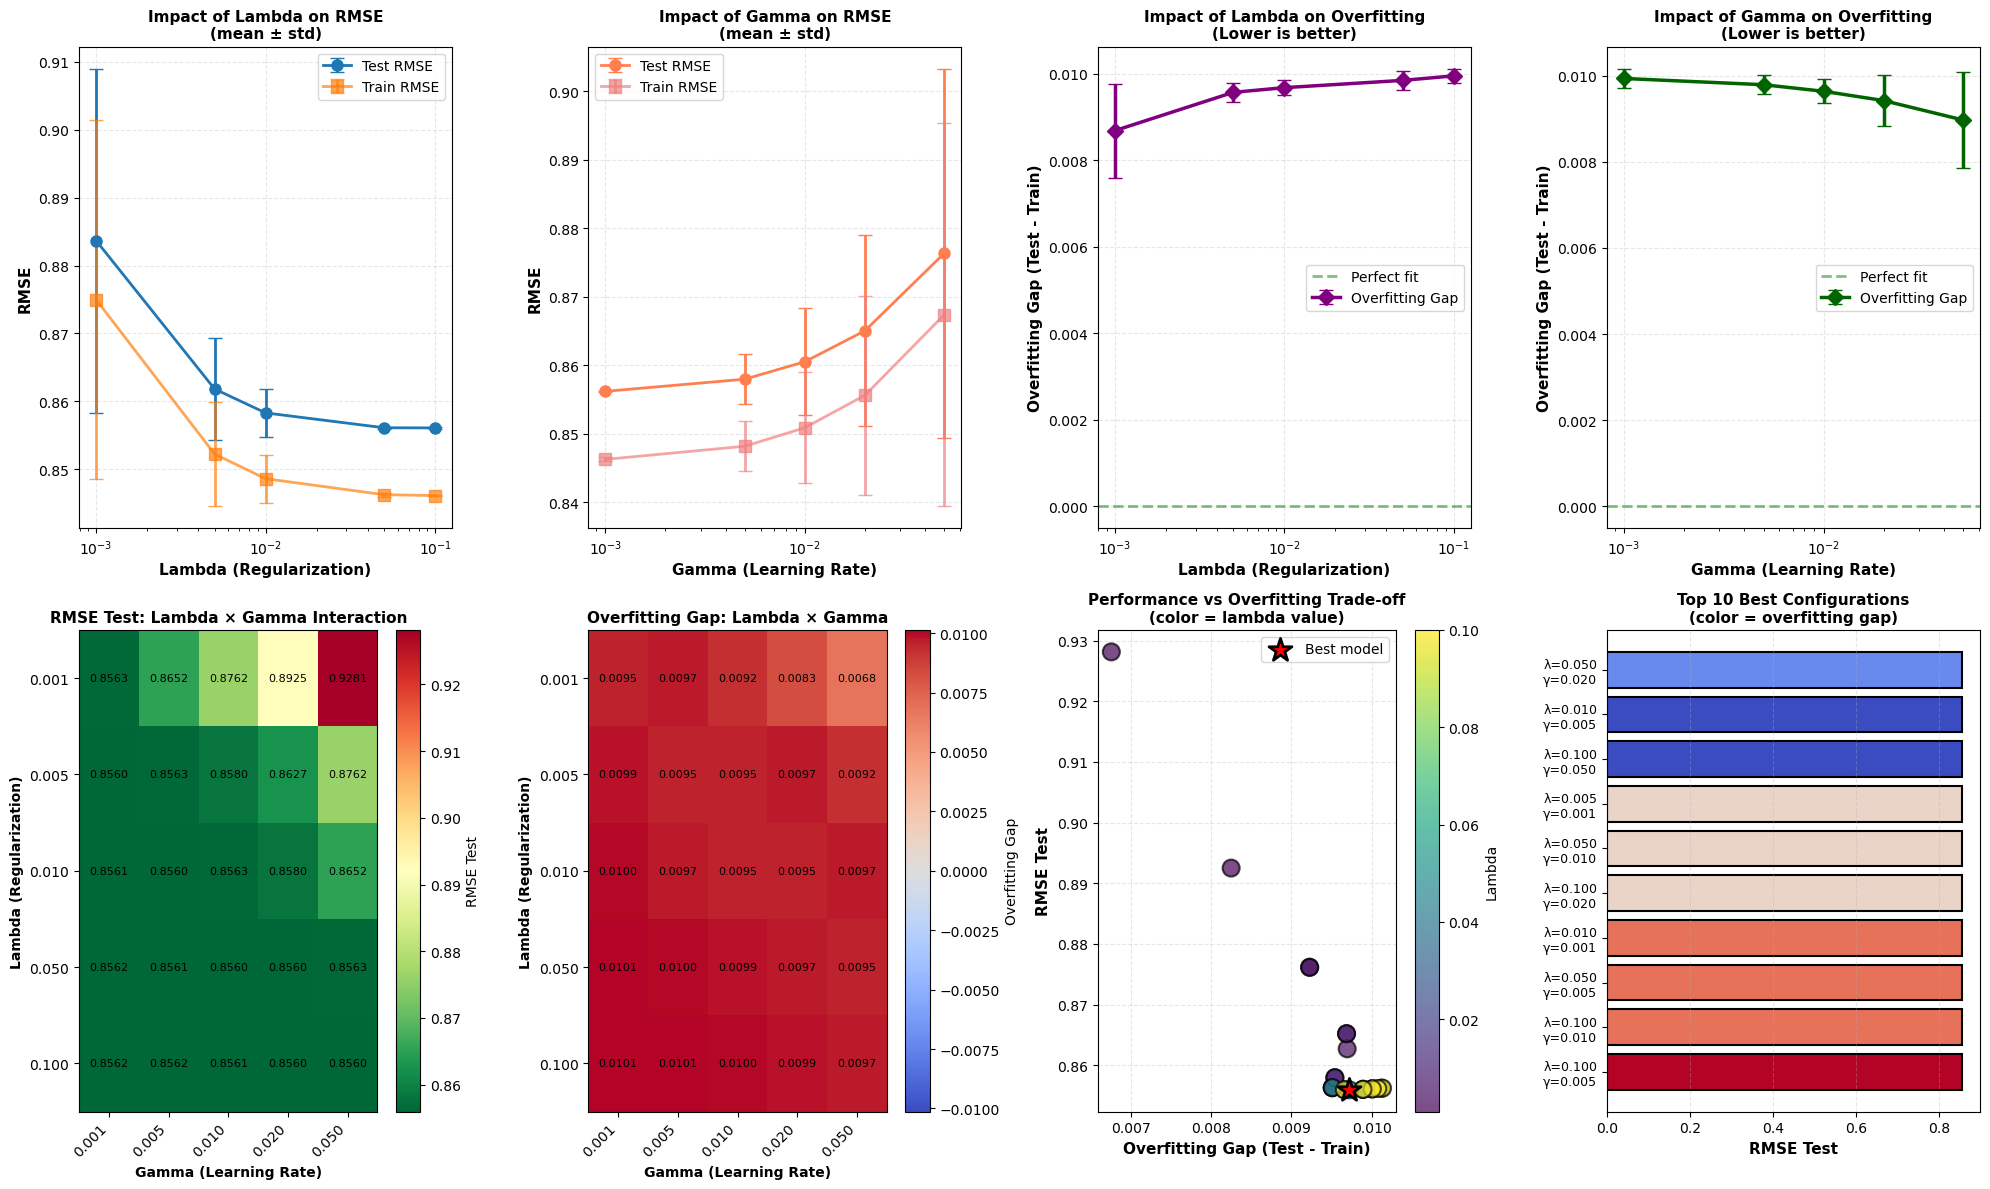

In [45]:
df=visualiser_impact_hyperparametres(results, search_type="Grid Search")


In [46]:
best_lambda, best_gamma, results = random_search_bias_model(
    M, N,
    user_ratings_train, user_items_train, user_start_end_train,
    item_ratings_train, item_users_train, item_start_end_train,
    user_ratings_test, user_items_test, user_start_end_test,
    n_iterations=30,
    num_iterations_model=50
)



RANDOM SEARCH - PARALLEL BIAS-ONLY MODEL
Total random combinations = 30
Running in PARALLEL...

🏆 BEST PARAMETERS FROM RANDOM SEARCH
  lambda_reg: 0.04540350190068947
  gamma_reg: 0.018698315054593836
  rmse_test: 0.8559684544915945
  rmse_train: 0.846255940370176
  overfitting_gap: 0.009712514121418492


# Practice 3

## 1. Prediction Formula

The predicted rating ($\hat{r}_{mn}$) for a user $m$ and item $n$.

$$
\hat{r}_{mn} = \mathbf{u}_m^T \mathbf{v}_n + b_m + b_n
$$

* Corresponds to the `pred` variable in the code.

## 2. Loss Function

The objective function (error + regularization) to minimize.

$$
-L = \frac{\lambda}{2} \sum_{(m,n) \in \Omega} (r_{mn} - \hat{r}_{mn})^2 + \frac{\tau}{2} \left( \sum_{m} ||\mathbf{u}_m||^2 + \sum_{n} ||\mathbf{v}_n||^2 \right)
$$

* Calculated by `calculate_loss`.

## 3. RMSE (Root Mean Squared Error)

The error metric used to evaluate the model.

$$
\text{RMSE} = \sqrt{\frac{1}{|\Omega|} \sum_{(m,n) \in \Omega} (r_{mn} - \hat{r}_{mn})^2}
$$

* Calculated by `calculate_rmse`.

## 4. ALS Updates

The equations solved within `update_biases_and_factors`.

### User Factors ($\mathbf{u}_m$)

$$
\mathbf{u}_m \leftarrow \left( \lambda \sum_{n \in \Omega_m} \mathbf{v}_n \mathbf{v}_n^T + \tau I \right)^{-1} \left( \lambda \sum_{n \in \Omega_m} \mathbf{v}_n (r_{mn} - b_m - b_n) \right)
$$

### User Biases ($b_m$)

$$
b_m \leftarrow \frac{\lambda \sum_{n \in \Omega_m} (r_{mn} - \mathbf{u}_m^T \mathbf{v}_n - b_n)}{\lambda |\Omega_m| + \tau}
$$

### Item Factors ($\mathbf{v}_n$)

$$
\mathbf{v}_n \leftarrow \left( \lambda \sum_{m \in \Omega_n} \mathbf{u}_m \mathbf{u}_m^T + \tau I \right)^{-1} \left( \lambda \sum_{m \in \Omega_n} \mathbf{u}_m (r_{mn} - b_m - b_n) \right)
$$

### Item Biases ($b_n$)

$$
b_n \leftarrow \frac{\lambda \sum_{m \in \Omega_n} (r_{mn} - \mathbf{u}_m^T \mathbf{v}_n - b_m)}{\lambda |\Omega_n| + \tau}
$$


### Variables
* $r_{mn}$: True rating
* $\hat{r}_{mn}$: Predicted rating
* $\mathbf{u}_m, \mathbf{v}_n$: Latent factor vectors
* $b_m, b_n$: Biases
* $\lambda, \tau$: Regularization parameters (`lambda_reg`, `tau_reg`)
* $\Omega_m, \Omega_n$: Sets of ratings for user $m$ or item $n$.

### ALS UPDATES (U and V from the formula)

In [ ]:


@njit(parallel=True)
def update_biases_and_factors(M, N, K,
                              user_ratings, user_items, user_start_end,
                              item_ratings, item_users, item_start_end,
                              user_biases, item_biases, user_factors, item_factors,
                              lambda_reg, gamma_reg, tau_reg, num_iterations):


    for iteration in range(num_iterations):


        for m in prange(M):  # Parallelization over users
            start = user_start_end[m, 0]
            end = user_start_end[m, 1]

            if end <= start:
                continue

            count = end - start
            
            bias_sum = 0.0
            for idx in range(start, end):
                n = user_items[idx]
                r = user_ratings[idx]

                
                dot_product = 0.0
                for k in range(K):
                    dot_product += user_factors[m, k] * item_factors[n, k]

                bias_sum += r - item_biases[n] - dot_product

            user_biases[m] = bias_sum / (count + gamma_reg)

           
            A = tau_reg * np.eye(K)
            b_vec = np.zeros(K)

            for idx in range(start, end):
                n = user_items[idx]
                r = user_ratings[idx]
                v_n = item_factors[n]

                # A += lambda_reg * outer(v_n, v_n)
                for i in range(K):
                    for j in range(K):
                        A[i, j] += lambda_reg * v_n[i] * v_n[j]

                # b_vec += lambda_reg * v_n * (r - user_biases[m] - item_biases[n])
                residual = r - user_biases[m] - item_biases[n]
                for i in range(K):
                    b_vec[i] += lambda_reg * v_n[i] * residual

            user_factors[m] = np.linalg.solve(A, b_vec)



        # --- Update ITEM factors and  item biases ---
        for n in prange(N):  # Parallelization over items
            start = item_start_end[n, 0]
            end = item_start_end[n, 1]

            if end <= start:
                continue

            count = end - start
 # (1) First loop: update ITEM bias
            bias_sum = 0.0
            for idx in range(start, end):
                m_idx = item_users[idx]
                r = item_ratings[idx]

                # Compute dot product
                dot_product = 0.0
                for k in range(K):
                    dot_product += user_factors[m_idx, k] * item_factors[n, k]

                bias_sum += r - user_biases[m_idx] - dot_product

            item_biases[n] = bias_sum / (count + gamma_reg)

            # (2) Second loop: update ITEM vector
            A = tau_reg * np.eye(K)
            b_vec = np.zeros(K)

            for idx in range(start, end):
                m_idx = item_users[idx]
                r = item_ratings[idx]
                u_m = user_factors[m_idx]

                # A += lambda_reg * outer(u_m, u_m)
                for i in range(K):
                    for j in range(K):
                        A[i, j] += lambda_reg * u_m[i] * u_m[j]

                # b_vec += lambda_reg * u_m * (r - user_biases[m_idx] - item_biases[n])
                residual = r - user_biases[m_idx] - item_biases[n]
                for i in range(K):
                    b_vec[i] += lambda_reg * u_m[i] * residual

            item_factors[n] = np.linalg.solve(A, b_vec)


    return user_biases, item_biases, user_factors, item_factors

## LOSS FUNCTION

In [28]:


@njit(parallel=True)
def calculate_loss_negatif(user_ratings, user_items, user_start_end, M,
                          user_biases, item_biases, user_factors, item_factors,
                          lambda_reg, gamma_reg, tau_reg):
    """


    L = -(λ/2) * Σ (r_mn - (u_m^T v_n + b_u_m + b_i_n))²
        - (τ/2) * (Σ ||u_m||² + Σ ||v_n||²)
        - (γ/2) * (Σ b_u_m² + Σ b_i_n²)


    """
    K = user_factors.shape[1]

    # Use array to accumulate results from parallel threads
    squared_errors = np.zeros(M, dtype=np.float32)

    for m in prange(M):  # Parallelization over users
        start = user_start_end[m, 0]
        end = user_start_end[m, 1]

        local_squared_error = 0.0

        # Single loop over ratings for this user
        for idx in range(start, end):
            n = user_items[idx]
            r = user_ratings[idx]

            # Compute dot product manually
            dot_product = 0.0
            for k in range(K):
                dot_product += user_factors[m, k] * item_factors[n, k]

            prediction = dot_product + user_biases[m] + item_biases[n]
            local_squared_error += (r - prediction) ** 2

        squared_errors[m] = local_squared_error

    # Aggregate squared errors
    squared_error_sum = np.sum(squared_errors)

    # Regularization terms
    reg_bias = np.sum(user_biases ** 2) + np.sum(item_biases ** 2)
    reg_factors = np.sum(user_factors ** 2) + np.sum(item_factors ** 2)

    # Compute loss
    L = - (lambda_reg / 2) * squared_error_sum - (tau_reg / 2) * reg_factors - (gamma_reg / 2) * reg_bias

    return -L

## RMSE COMPUTATION

In [29]:

@njit(parallel=True)
def calculate_rmse(user_ratings, user_items, user_start_end, M,
                   user_biases, item_biases, user_factors, item_factors):
    """
    Computes RMSE between predictions and true ratings using:
    - Flat lists for ratings and items
    - Start/end indices for each user
    - Single loops (range-based)
    - Parallelization with prange

    Parameters
    ----------
    user_ratings : np.array
        Flat array of all ratings
    user_items : np.array
        Flat array of all item indices
    user_start_end : np.array
        Array of shape (M, 2) with start/end indices for each user
    M : int
        Number of users
    user_biases, item_biases : np.array
        Bias arrays
    user_factors, item_factors : np.array
        Factor matrices

    Returns
    -------
    float
        Root Mean Squared Error
    """
    K = user_factors.shape[1]

    # Use arrays to accumulate results from parallel threads
    squared_errors = np.zeros(M, dtype=np.float32)
    counts = np.zeros(M, dtype=np.int32)

    for m in prange(M):  # Parallelization over users
        start = user_start_end[m, 0]
        end = user_start_end[m, 1]

        local_squared_error = 0.0
        local_count = 0

        # Single loop over ratings for this user
        for idx in range(start, end):
            n = user_items[idx]
            r = user_ratings[idx]

            # Compute dot product manually
            dot_product = 0.0
            for k in range(K):
                dot_product += user_factors[m, k] * item_factors[n, k]

            prediction = dot_product + user_biases[m] + item_biases[n]
            local_squared_error += (r - prediction) ** 2
            local_count += 1

        squared_errors[m] = local_squared_error
        counts[m] = local_count

    # Aggregate results
    total_squared_error = np.sum(squared_errors)
    total_count = np.sum(counts)

    if total_count == 0:
        return 0.0

    return np.sqrt(total_squared_error / total_count)

In [30]:
def train_and_evaluate_metrics(M, N, K, 
user_ratings_train, user_items_train, user_start_end_train, \
    item_ratings_train, item_users_train, item_start_end_train, user_ratings_test, user_items_test, user_start_end_test, 
                               lambda_reg, gamma_reg, tau_reg, num_iterations):
    """
    Train ALS model with λ, γ, and τ regularization terms using flat data structures.
    Computes metrics at each iteration.
    """
    # Initialize parameters
    user_biases = np.zeros(M, dtype=np.float32)
    item_biases = np.zeros(N, dtype=np.float32)
    user_factors = np.random.normal(0, 0.1, (M, K)).astype(np.float32)
    item_factors = np.random.normal(0, 0.1, (N, K)).astype(np.float32)

   
    loss_history, rmse_train, rmse_test = [], [], []

    print("Starting ALS training with λ, γ, τ terms...")

    # Train one iteration at a time to compute metrics
    for iteration in range(num_iterations):
        user_biases, item_biases, user_factors, item_factors = update_biases_and_factors(
            M, N, K,
            user_ratings_train, user_items_train, user_start_end_train,
            item_ratings_train, item_users_train, item_start_end_train,
            user_biases, item_biases, user_factors, item_factors,
            lambda_reg, gamma_reg, tau_reg, 1  # 1 iteration at a time
        )

        # Compute metrics
        loss = calculate_loss_negatif(
            user_ratings_train, user_items_train, user_start_end_train, M,
            user_biases, item_biases, user_factors, item_factors,
            lambda_reg, gamma_reg, tau_reg
        )
        loss_history.append(loss)

        rmse_tr = calculate_rmse(
            user_ratings_train, user_items_train, user_start_end_train, M,
            user_biases, item_biases, user_factors, item_factors
        )
        rmse_train.append(rmse_tr)

        rmse_te = calculate_rmse(
            user_ratings_test, user_items_test, user_start_end_test, M,
            user_biases, item_biases, user_factors, item_factors
        )
        rmse_test.append(rmse_te)

        if (iteration + 1) % 10 == 0 or iteration == 0:
            print(f"Iteration {iteration+1}/{num_iterations} | "
                  f"Train RMSE: {rmse_tr:.4f} | Test RMSE: {rmse_te:.4f} | Loss: {loss:.4f}")

    print("Training completed.")

    return {
        "loss_history": loss_history,
        "rmse_train": rmse_train,
        "rmse_test": rmse_test,
        "user_biases": user_biases,
        "item_biases": item_biases,
        "user_factors": user_factors,
        "item_factors": item_factors
    }

In [31]:
# --- Hyperparameters ---
M = len(user_to_index)
N = len(movie_to_index)
K = 10
lambda_reg = 0.005   # λ : weight on reconstruction error
gamma_reg = 0.01    # γ : weight on biases
tau_reg = 0.05      # τ : weight on latent factor norms
num_iterations = 30


In [ ]:

user_ratings_train, user_items_train, user_start_end_train, \
    item_ratings_train, item_users_train, item_start_end_train = \
        prepare_flat_data(data_by_user_train, data_by_movie_train, M, N)

user_ratings_test, user_items_test, user_start_end_test, _, _, _ = \
        prepare_flat_data(data_by_user_test, data_by_movie_train, M, N)


In [40]:


results = train_and_evaluate_metrics(M, N, K, 
user_ratings_train, user_items_train, user_start_end_train, \
    item_ratings_train, item_users_train, item_start_end_train, user_ratings_test, user_items_test, user_start_end_test, 
                               lambda_reg, gamma_reg, tau_reg, num_iterations)


Starting ALS training with λ, γ, τ terms...
Iteration 1/30 | Train RMSE: 0.8397 | Test RMSE: 0.8752 | Loss: 65466.2023
Iteration 10/30 | Train RMSE: 0.7162 | Test RMSE: 0.7772 | Loss: 52286.3783
Iteration 20/30 | Train RMSE: 0.7144 | Test RMSE: 0.7760 | Loss: 51970.2533
Iteration 30/30 | Train RMSE: 0.7140 | Test RMSE: 0.7757 | Loss: 51881.0696
Training completed.


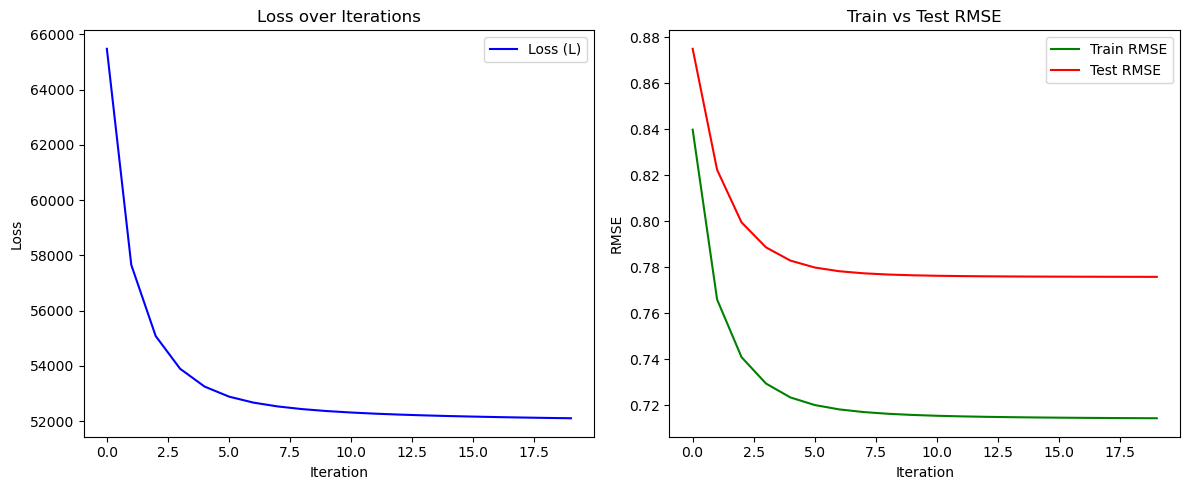

In [38]:


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(results["loss_history"], color='blue', label='Loss (L)')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Loss over Iterations')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(results["rmse_train"], color='green', label='Train RMSE')
plt.plot(results["rmse_test"], color='red', label='Test RMSE')
plt.xlabel('Iteration')
plt.ylabel('RMSE')
plt.title('Train vs Test RMSE')
plt.legend()

plt.tight_layout()
plt.show()


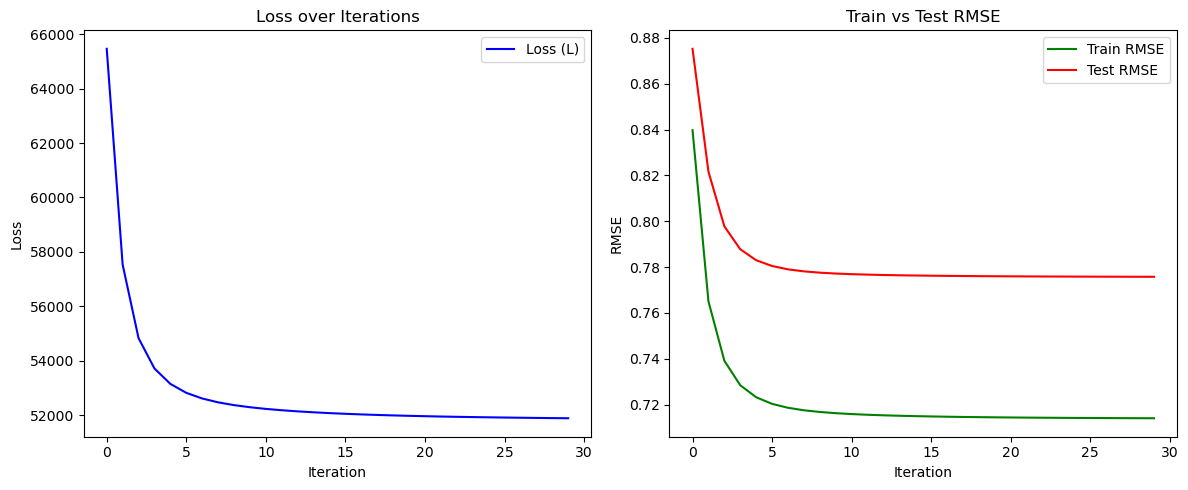

In [41]:


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(results["loss_history"], color='blue', label='Loss (L)')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Loss over Iterations')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(results["rmse_train"], color='green', label='Train RMSE')
plt.plot(results["rmse_test"], color='red', label='Test RMSE')
plt.xlabel('Iteration')
plt.ylabel('RMSE')
plt.title('Train vs Test RMSE')
plt.legend()

plt.tight_layout()
plt.show()


# Practice 4

NOW WRITE the code can permit to optimise lamdda, gamma

### lots the train and test RMSE on the same axis as you progress. Can you show where overfitting happens?

Is there more overfitting with K=20 latent dimensions than K=10? Or not? For which users? Is there underfitting anywhere? Do changes of λ and τ affect this?



Training with K = 5
Starting ALS training with λ, γ, τ terms...
Iteration 1/30 | Train RMSE: 0.8396 | Test RMSE: 0.8752 | Loss: 65459.6972
Iteration 10/30 | Train RMSE: 0.7155 | Test RMSE: 0.7763 | Loss: 52266.0090
Iteration 20/30 | Train RMSE: 0.7141 | Test RMSE: 0.7756 | Loss: 51988.9676
Iteration 30/30 | Train RMSE: 0.7139 | Test RMSE: 0.7755 | Loss: 51914.9027
Training completed.

Training with K = 10
Starting ALS training with λ, γ, τ terms...
Iteration 1/30 | Train RMSE: 0.8398 | Test RMSE: 0.8752 | Loss: 65468.7240
Iteration 10/30 | Train RMSE: 0.7164 | Test RMSE: 0.7776 | Loss: 52355.8273
Iteration 20/30 | Train RMSE: 0.7143 | Test RMSE: 0.7759 | Loss: 52024.8888
Iteration 30/30 | Train RMSE: 0.7139 | Test RMSE: 0.7756 | Loss: 51951.2491
Training completed.

Training with K = 20
Starting ALS training with λ, γ, τ terms...
Iteration 1/30 | Train RMSE: 0.8405 | Test RMSE: 0.8761 | Loss: 65547.3821
Iteration 10/30 | Train RMSE: 0.7162 | Test RMSE: 0.7774 | Loss: 52374.5501
Iterat

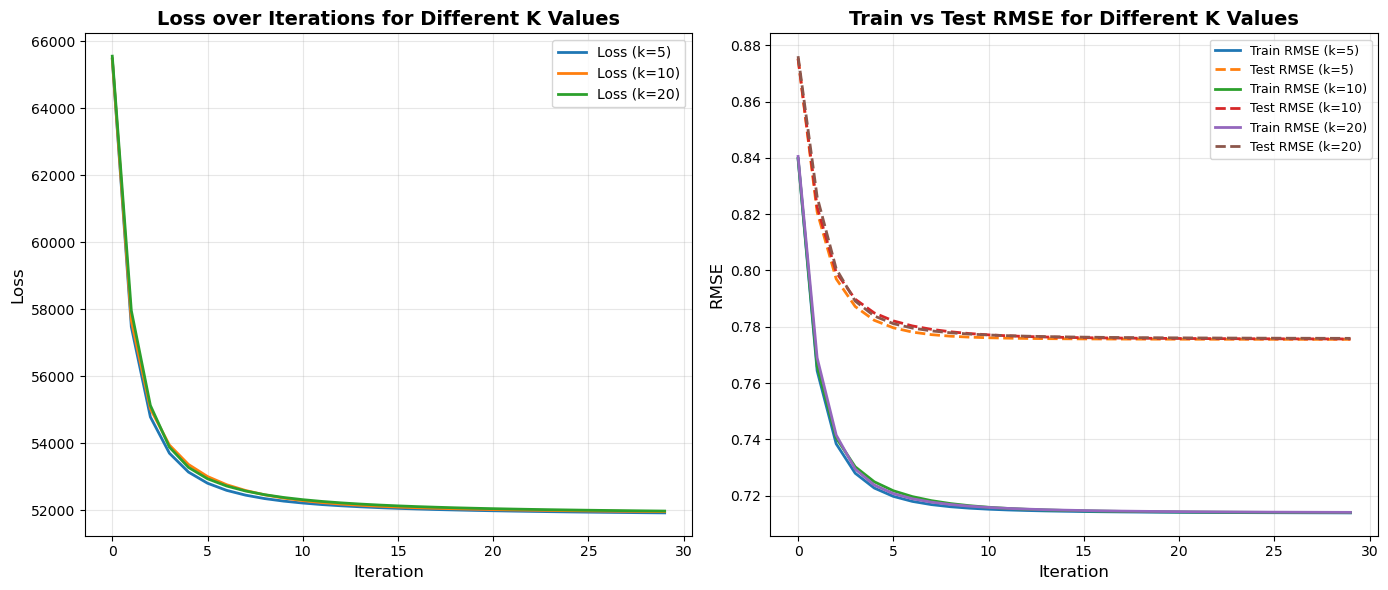

In [45]:
import matplotlib.pyplot as plt

# --- Train model and get metrics ---
k_values = [5,10, 20]
all_results = {}

# Train for all k values and store results
for k in k_values:
    print(f"\n{'='*60}")
    print(f"Training with K = {k}")
    print(f"{'='*60}")

    results = train_and_evaluate_metrics(M, N, K, 
user_ratings_train, user_items_train, user_start_end_train, \
    item_ratings_train, item_users_train, item_start_end_train, user_ratings_test, user_items_test, user_start_end_test, 
                               lambda_reg, gamma_reg, tau_reg, num_iterations
    )
    all_results[k] = results

# Plot all results on the same graphs
plt.figure(figsize=(14, 6))

# Plot 1: Loss for all k values
plt.subplot(1, 2, 1)
for k in k_values:
    plt.plot(all_results[k]["loss_history"], label=f'Loss (k={k})', linewidth=2)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Loss over Iterations for Different K Values', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# Plot 2: RMSE for all k values
plt.subplot(1, 2, 2)
for k in k_values:
    plt.plot(all_results[k]["rmse_train"], label=f'Train RMSE (k={k})', linewidth=2, linestyle='-')
    plt.plot(all_results[k]["rmse_test"], label=f'Test RMSE (k={k})', linewidth=2, linestyle='--')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.title('Train vs Test RMSE for Different K Values', fontsize=14, fontweight='bold')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### For which users we have overfiting

ANALYZING OVERFITTING BY USER DEGREE (Power-Law Analysis)


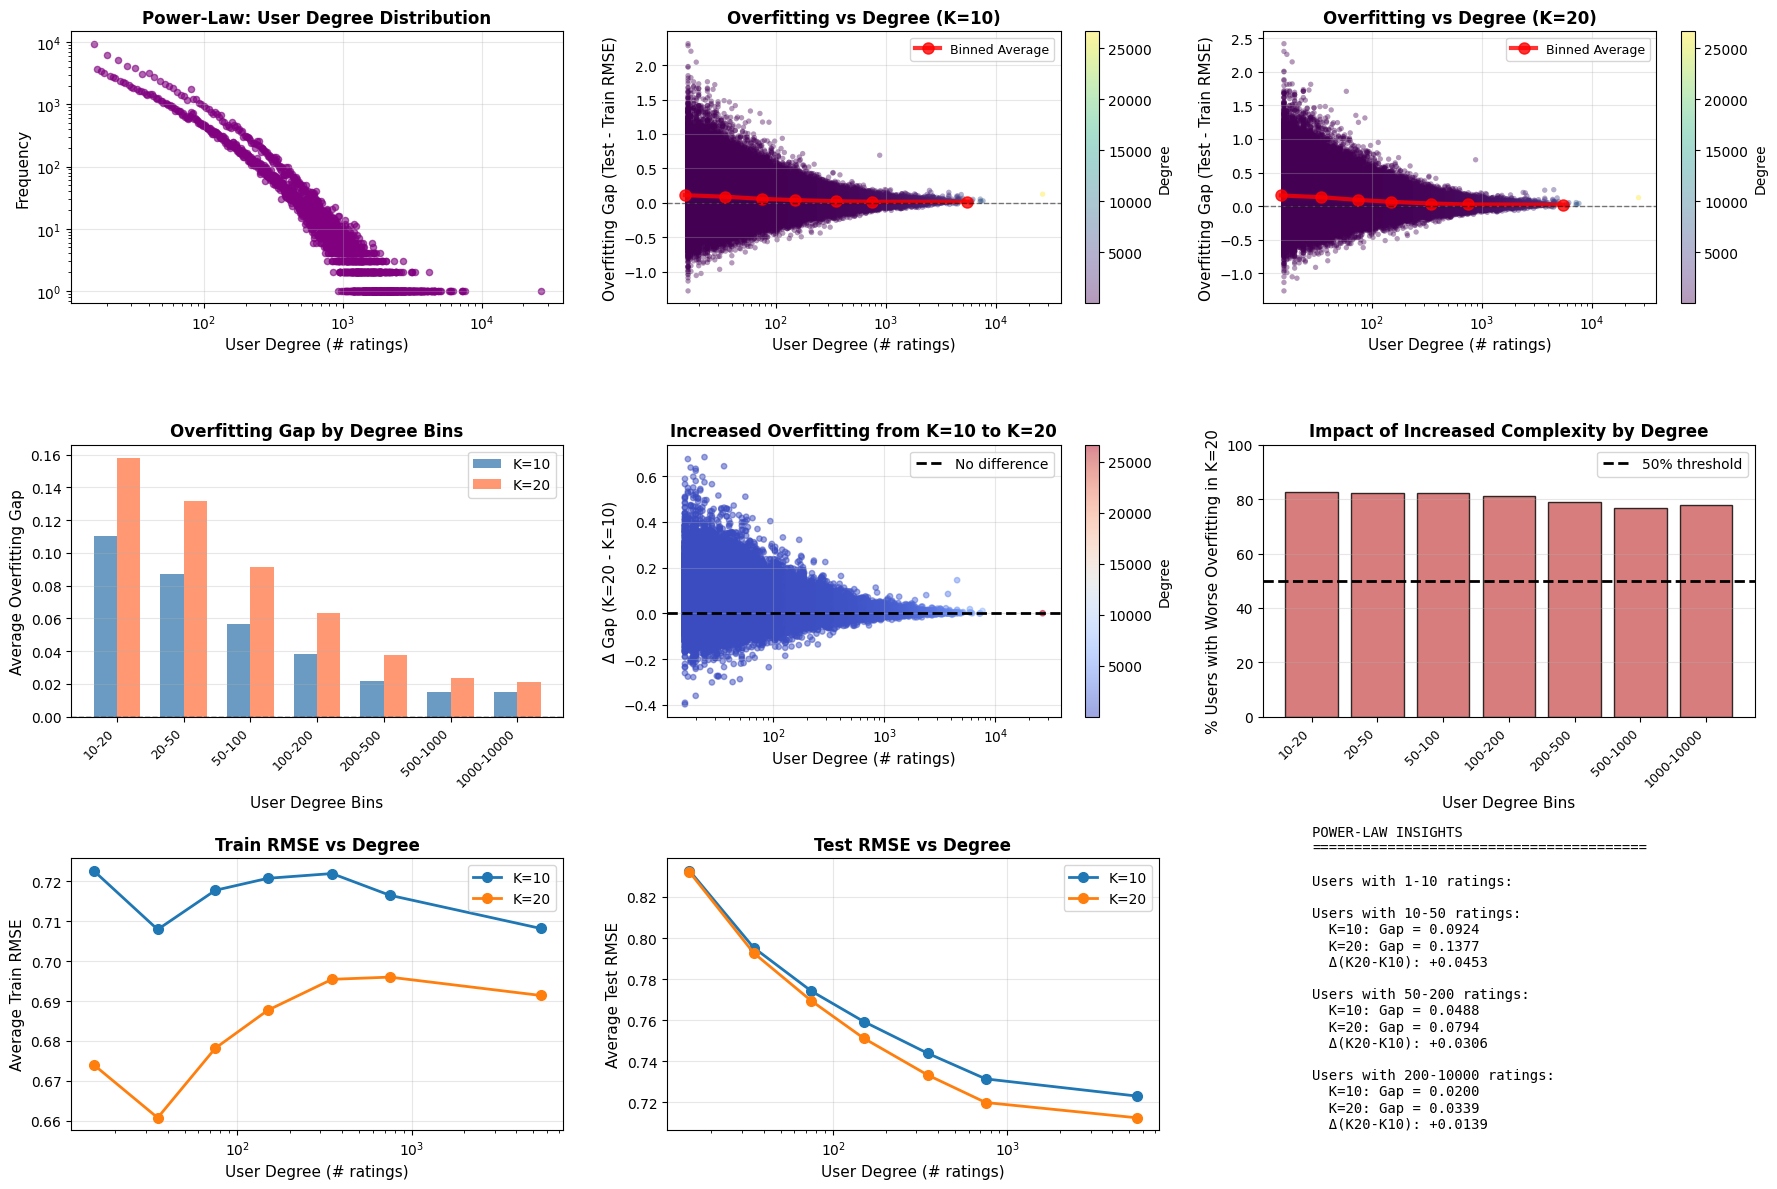


DETAILED STATISTICS BY DEGREE RANGE


--------------------------------------------------------------------------------
Users with 1-10 ratings:
--------------------------------------------------------------------------------

--------------------------------------------------------------------------------
Users with 10-50 ratings:
--------------------------------------------------------------------------------

K = 10:
  Number of users: 90148
  Avg train RMSE:  0.7112
  Avg test RMSE:   0.8036
  Avg gap:         0.0924
  Std gap:         0.2799
  % with gap > 0.5: 7.6%

K = 20:
  Number of users: 90148
  Avg train RMSE:  0.6637
  Avg test RMSE:   0.8014
  Avg gap:         0.1377
  Std gap:         0.2821
  % with gap > 0.5: 9.7%

--------------------------------------------------------------------------------
Users with 50-200 ratings:
--------------------------------------------------------------------------------

K = 10:
  Number of users: 78189
  Avg train RMSE:  0.7190
  Avg tes

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def analyze_overfitting_by_degree(M, data_by_user_train, data_by_user_test,
                                   all_results, k_values):
    """
    Analyze overfitting as a function of user degree (number of ratings).
    Users with fewer ratings are expected to overfit more with higher K.
    """

    # Calculate user degrees (number of ratings in training)
    user_degrees = np.array([len(ratings_list) for ratings_list in data_by_user_train])

    # Store results for each K
    results_by_k = {}

    for k in k_values:
        results = all_results[k]
        user_biases = results['user_biases']
        item_biases = results['item_biases']
        user_factors = results['user_factors']
        item_factors = results['item_factors']

        train_errors = np.zeros(M)
        test_errors = np.zeros(M)
        train_counts = np.zeros(M)
        test_counts = np.zeros(M)

        # Calculate train RMSE per user
        for m in range(M):
            if len(data_by_user_train[m]) > 0:
                for n, r in data_by_user_train[m]:
                    pred = np.dot(user_factors[m], item_factors[n]) + user_biases[m] + item_biases[n]
                    train_errors[m] += (r - pred) ** 2
                    train_counts[m] += 1
                train_errors[m] = np.sqrt(train_errors[m] / train_counts[m])

        # Calculate test RMSE per user
        for m in range(M):
            if len(data_by_user_test[m]) > 0:
                for n, r in data_by_user_test[m]:
                    pred = np.dot(user_factors[m], item_factors[n]) + user_biases[m] + item_biases[n]
                    test_errors[m] += (r - pred) ** 2
                    test_counts[m] += 1
                test_errors[m] = np.sqrt(test_errors[m] / test_counts[m])

        # Calculate overfitting gap
        overfitting_gap = test_errors - train_errors

        # Filter valid users (have both train and test data)
        valid = (train_counts > 0) & (test_counts > 0)

        results_by_k[k] = {
            'train_errors': train_errors[valid],
            'test_errors': test_errors[valid],
            'gap': overfitting_gap[valid],
            'degrees': user_degrees[valid],
            'valid_mask': valid
        }

    return results_by_k


# Run analysis
print("="*80)
print("ANALYZING OVERFITTING BY USER DEGREE (Power-Law Analysis)")
print("="*80)

results_by_k = analyze_overfitting_by_degree(M, data_by_user_train, data_by_user_test,
                                              all_results, k_values)

# Create comprehensive visualization
fig = plt.figure(figsize=(18, 12))

# Define degree bins for analysis
degree_bins = [1, 5, 10, 20, 50, 100, 200, 500, 1000, 10000]

# Plot 1: Power-law distribution with overfitting overlay
ax1 = plt.subplot(3, 3, 1)
user_degrees_all = [len(ratings_list) for ratings_list in data_by_user_train]
values, counts = np.unique(user_degrees_all, return_counts=True)
plt.scatter(values, counts, s=20, alpha=0.6, color='purple')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('User Degree (# ratings)', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.title('Power-Law: User Degree Distribution', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

# Plot 2 & 3: Overfitting gap vs degree for each K
for idx, k in enumerate(k_values):
    ax = plt.subplot(3, 3, 2 + idx)
    data = results_by_k[k]

    # Scatter plot with color gradient
    scatter = plt.scatter(data['degrees'], data['gap'],
                         c=data['degrees'], cmap='viridis',
                         alpha=0.4, s=15, edgecolors='none')

    # Add binned average line
    bin_means = []
    bin_centers = []
    for i in range(len(degree_bins)-1):
        mask = (data['degrees'] >= degree_bins[i]) & (data['degrees'] < degree_bins[i+1])
        if np.sum(mask) > 0:
            bin_means.append(np.mean(data['gap'][mask]))
            bin_centers.append((degree_bins[i] + degree_bins[i+1]) / 2)

    plt.plot(bin_centers, bin_means, 'r-o', linewidth=3, markersize=8,
             label='Binned Average', alpha=0.8)

    plt.xscale('log')
    plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    plt.xlabel('User Degree (# ratings)', fontsize=11)
    plt.ylabel('Overfitting Gap (Test - Train RMSE)', fontsize=11)
    plt.title(f'Overfitting vs Degree (K={k})', fontsize=12, fontweight='bold')
    plt.legend(fontsize=9)
    plt.grid(True, alpha=0.3)


# Dictionnaires pour convertir userId / movieId en indices
user_to_index = {}
movie_to_index = {}
index_to_user = []
index_to_movie = []


user_to_index = {}
movie_to_index = {}
index_to_user = []
index_to_movie = []



plt.colorbar(scatter, label='Degree')
# Plot 4: Comparison K=10 vs K=20 by degree bins
ax4 = plt.subplot(3, 3, 4)
k10_data = results_by_k[10]
k20_data = results_by_k[20]

# Calculate average gap per bin for each K
bins_labels = []
k10_bin_gaps = []
k20_bin_gaps = []

for i in range(len(degree_bins)-1):
    mask_10 = (k10_data['degrees'] >= degree_bins[i]) & (k10_data['degrees'] < degree_bins[i+1])
    mask_20 = (k20_data['degrees'] >= degree_bins[i]) & (k20_data['degrees'] < degree_bins[i+1])

    if np.sum(mask_10) > 5 and np.sum(mask_20) > 5:  # At least 5 users in bin
        bins_labels.append(f"{degree_bins[i]}-{degree_bins[i+1]}")
        k10_bin_gaps.append(np.mean(k10_data['gap'][mask_10]))
        k20_bin_gaps.append(np.mean(k20_data['gap'][mask_20]))

x = np.arange(len(bins_labels))
width = 0.35

plt.bar(x - width/2, k10_bin_gaps, width, label='K=10', alpha=0.8, color='steelblue')
plt.bar(x + width/2, k20_bin_gaps, width, label='K=20', alpha=0.8, color='coral')

plt.xlabel('User Degree Bins', fontsize=11)
plt.ylabel('Average Overfitting Gap', fontsize=11)
plt.title('Overfitting Gap by Degree Bins', fontsize=12, fontweight='bold')
plt.xticks(x, bins_labels, rotation=45, ha='right', fontsize=9)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.axhline(0, color='black', linestyle='--', linewidth=1)

# Plot 5: Difference in overfitting (K=20 - K=10) by degree
ax5 = plt.subplot(3, 3, 5)
# Match users between K=10 and K=20
common_users = k10_data['valid_mask'] & k20_data['valid_mask']
gap_diff = k20_data['gap'] - k10_data['gap']

scatter = plt.scatter(k10_data['degrees'], gap_diff,
                     c=k10_data['degrees'], cmap='coolwarm',
                     alpha=0.5, s=15)
plt.xscale('log')
plt.axhline(0, color='black', linestyle='--', linewidth=2, label='No difference')
plt.xlabel('User Degree (# ratings)', fontsize=11)
plt.ylabel('Δ Gap (K=20 - K=10)', fontsize=11)
plt.title('Increased Overfitting from K=10 to K=20', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.colorbar(scatter, label='Degree')

# Plot 6: Percentage of users with worse overfitting in K=20, by degree bin
ax6 = plt.subplot(3, 3, 6)
worse_overfitting_pct = []
bin_labels_pct = []

for i in range(len(degree_bins)-1):
    mask = (k10_data['degrees'] >= degree_bins[i]) & (k10_data['degrees'] < degree_bins[i+1])
    if np.sum(mask) > 5:
        worse_count = np.sum(gap_diff[mask] > 0)
        total_count = np.sum(mask)
        worse_overfitting_pct.append(100 * worse_count / total_count)
        bin_labels_pct.append(f"{degree_bins[i]}-{degree_bins[i+1]}")

plt.bar(range(len(worse_overfitting_pct)), worse_overfitting_pct,
        alpha=0.8, color='indianred', edgecolor='black')
plt.axhline(50, color='black', linestyle='--', linewidth=2, label='50% threshold')
plt.xlabel('User Degree Bins', fontsize=11)
plt.ylabel('% Users with Worse Overfitting in K=20', fontsize=11)
plt.title('Impact of Increased Complexity by Degree', fontsize=12, fontweight='bold')
plt.xticks(range(len(bin_labels_pct)), bin_labels_pct, rotation=45, ha='right', fontsize=9)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.ylim(0, 100)

# Plot 7: Train RMSE vs Degree
ax7 = plt.subplot(3, 3, 7)
for k in k_values:
    data = results_by_k[k]
    bin_means = []
    bin_centers = []
    for i in range(len(degree_bins)-1):
        mask = (data['degrees'] >= degree_bins[i]) & (data['degrees'] < degree_bins[i+1])
        if np.sum(mask) > 0:
            bin_means.append(np.mean(data['train_errors'][mask]))
            bin_centers.append((degree_bins[i] + degree_bins[i+1]) / 2)
    plt.plot(bin_centers, bin_means, '-o', linewidth=2, markersize=7, label=f'K={k}')

plt.xscale('log')
plt.xlabel('User Degree (# ratings)', fontsize=11)
plt.ylabel('Average Train RMSE', fontsize=11)
plt.title('Train RMSE vs Degree', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 8: Test RMSE vs Degree
ax8 = plt.subplot(3, 3, 8)
for k in k_values:
    data = results_by_k[k]
    bin_means = []
    bin_centers = []
    for i in range(len(degree_bins)-1):
        mask = (data['degrees'] >= degree_bins[i]) & (data['degrees'] < degree_bins[i+1])
        if np.sum(mask) > 0:
            bin_means.append(np.mean(data['test_errors'][mask]))
            bin_centers.append((degree_bins[i] + degree_bins[i+1]) / 2)
    plt.plot(bin_centers, bin_means, '-o', linewidth=2, markersize=7, label=f'K={k}')

plt.xscale('log')
plt.xlabel('User Degree (# ratings)', fontsize=11)
plt.ylabel('Average Test RMSE', fontsize=11)
plt.title('Test RMSE vs Degree', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 9: Summary statistics table
ax9 = plt.subplot(3, 3, 9)
ax9.axis('off')

summary_text = "POWER-LAW INSIGHTS\n" + "="*40 + "\n\n"

for i, degree_range in enumerate([(1, 10), (10, 50), (50, 200), (200, 10000)]):
    summary_text += f"Users with {degree_range[0]}-{degree_range[1]} ratings:\n"

    for k in k_values:
        data = results_by_k[k]
        mask = (data['degrees'] >= degree_range[0]) & (data['degrees'] < degree_range[1])
        if np.sum(mask) > 0:
            avg_gap = np.mean(data['gap'][mask])
            summary_text += f"  K={k}: Gap = {avg_gap:.4f}\n"

    # Compare K=20 vs K=10
    mask_10 = (results_by_k[10]['degrees'] >= degree_range[0]) & (results_by_k[10]['degrees'] < degree_range[1])
    mask_20 = (results_by_k[20]['degrees'] >= degree_range[0]) & (results_by_k[20]['degrees'] < degree_range[1])
    if np.sum(mask_10) > 0 and np.sum(mask_20) > 0:
        diff = np.mean(results_by_k[20]['gap'][mask_20]) - np.mean(results_by_k[10]['gap'][mask_10])
        summary_text += f"  Δ(K20-K10): {diff:+.4f}\n"

    summary_text += "\n"

plt.text(0.1, 0.5, summary_text, fontsize=10, family='monospace',
         verticalalignment='center')

plt.tight_layout()
plt.show()

# Print detailed statistics
print(f"\n{'='*80}")
print("DETAILED STATISTICS BY DEGREE RANGE")
print(f"{'='*80}\n")

for degree_range in [(1, 10), (10, 50), (50, 200), (200, 10000)]:
    print(f"\n{'-'*80}")
    print(f"Users with {degree_range[0]}-{degree_range[1]} ratings:")
    print(f"{'-'*80}")

    for k in k_values:
        data = results_by_k[k]
        mask = (data['degrees'] >= degree_range[0]) & (data['degrees'] < degree_range[1])

        if np.sum(mask) > 0:
            print(f"\nK = {k}:")
            print(f"  Number of users: {np.sum(mask)}")
            print(f"  Avg train RMSE:  {np.mean(data['train_errors'][mask]):.4f}")
            print(f"  Avg test RMSE:   {np.mean(data['test_errors'][mask]):.4f}")
            print(f"  Avg gap:         {np.mean(data['gap'][mask]):.4f}")
            print(f"  Std gap:         {np.std(data['gap'][mask]):.4f}")
            print(f"  % with gap > 0.5: {100*np.sum(data['gap'][mask] > 0.5)/np.sum(mask):.1f}%")


### Is there underfitting anywhere?

In the training curves for both K=10 and K=20 latent factors, there is no clear evidence of underfitting. Underfitting would manifest as persistently high training error or a very slow decrease in RMSE across iterations, indicating that the model is not complex enough to capture the underlying structure of the data. In our case, however, the training RMSE drops rapidly during the first iterations for both configurations, reaching relatively low values (approximately 0.70 for K=10 and 0.65 for K=20). This behaviour shows that the models have sufficient capacity to fit the training data and are not limited by model complexity. The test RMSE also initially decreases, confirming that the model learns meaningful latent patterns early in the optimization process. The primary phenomenon observed is overfitting, where the training and test curves begin to diverge after a few iterations, especially for K=20. Overall, the absence of a prolonged high-error phase indicates that the model does not underfit for either latent dimension.

### Version adapte a nouveau pour l etude des users influencant l overfiting

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import gc

def analyze_overfitting_by_degree(M, data_by_user_train, data_by_user_test,
                                   all_results):
    """
    Analyze overfitting as a function of user degree (number of ratings).
    Users with fewer ratings are expected to overfit more with higher K.
    
    Args:
        M: Number of users
        data_by_user_train: Training data by user
        data_by_user_test: Test data by user
        all_results: Dictionary with keys (k, lambda_reg, tau_reg) containing model results
    """

    # Calculate user degrees (number of ratings in training)
    user_degrees = np.array([len(ratings_list) for ratings_list in data_by_user_train])

    # Store results for each configuration
    results_by_config = {}

    for (k, lambda_reg, tau_reg), results in all_results.items():
        user_biases = results['user_biases']
        item_biases = results['item_biases']
        user_factors = results['user_factors']
        item_factors = results['item_factors']

        train_errors = np.zeros(M)
        test_errors = np.zeros(M)
        train_counts = np.zeros(M)
        test_counts = np.zeros(M)

        # Calculate train RMSE per user
        for m in range(M):
            if len(data_by_user_train[m]) > 0:
                for n, r in data_by_user_train[m]:
                    pred = np.dot(user_factors[m], item_factors[n]) + user_biases[m] + item_biases[n]
                    train_errors[m] += (r - pred) ** 2
                    train_counts[m] += 1
                train_errors[m] = np.sqrt(train_errors[m] / train_counts[m])

        # Calculate test RMSE per user
        for m in range(M):
            if len(data_by_user_test[m]) > 0:
                for n, r in data_by_user_test[m]:
                    pred = np.dot(user_factors[m], item_factors[n]) + user_biases[m] + item_biases[n]
                    test_errors[m] += (r - pred) ** 2
                    test_counts[m] += 1
                test_errors[m] = np.sqrt(test_errors[m] / test_counts[m])

        # Calculate overfitting gap
        overfitting_gap = test_errors - train_errors

        # Filter valid users (have both train and test data)
        valid = (train_counts > 0) & (test_counts > 0)

        results_by_config[(k, lambda_reg, tau_reg)] = {
            'train_errors': train_errors[valid],
            'test_errors': test_errors[valid],
            'gap': overfitting_gap[valid],
            'degrees': user_degrees[valid],
            'valid_mask': valid
        }

    return results_by_config


def visualize_power_law_analysis(M, data_by_user_train, data_by_user_test,
                                  all_results, output_dir="hyperparameter_plots",
                                  save_individual=True):
    """
    Create comprehensive power-law overfitting analysis with ALL K values on same plot
    
    Args:
        M: Number of users
        data_by_user_train: Training data by user
        data_by_user_test: Test data by user
        all_results: Dictionary with results from all configurations
        output_dir: Directory to save plots
        save_individual: If True, save each plot as individual PDF file
    """
    
    print("\n" + "="*80)
    print("ANALYZING OVERFITTING BY USER DEGREE (Power-Law Analysis)")
    print("="*80)

    # Run analysis
    results_by_config = analyze_overfitting_by_degree(M, data_by_user_train, 
                                                       data_by_user_test, all_results)

    # Extract unique K values
    k_values = sorted(set(k for (k, l, t) in all_results.keys()))
    
    # Create output directory
    os.makedirs(output_dir, exist_ok=True)
    
    # Create subdirectory for individual plots if needed
    if save_individual:
        individual_dir = f"{output_dir}/power_law_individual"
        os.makedirs(individual_dir, exist_ok=True)
        print(f"Individual plots will be saved to: {individual_dir}/")

    # Define degree bins for analysis
    degree_bins = [1, 50, 100, 200, 500, 1000, 2000, 5000, 10000, 1000000]
    
    # Define degree classes for histogram
    degree_classes = {
        'Very Low (1-100)': (1, 100),
        'Low (100-500)': (100, 500),
        'Medium (500-2000)': (500, 2000),
        'High (2000-5000)': (2000, 5000),
        'Very High (5000+)': (5000, 1000000)
    }

  
    
    fig_combined = plt.figure(figsize=(14, 8))
    
    # Colors for different K values
    colors_k = plt.cm.viridis(np.linspace(0.15, 0.95, len(k_values)))
    markers = ['o', 's', '^', 'D', 'v', 'P', '*', 'X']
    
    for k_idx, k in enumerate(k_values):
        # Find first config with this K value
        config_key = [key for key in all_results.keys() if key[0] == k][0]
        data = results_by_config[config_key]
        lambda_reg, tau_reg = config_key[1], config_key[2]

        # Calculate AVERAGE gap for each degree bin
        bin_means = []
        bin_stds = []
        bin_centers = []
        
        for i in range(len(degree_bins)-1):
            mask = (data['degrees'] >= degree_bins[i]) & (data['degrees'] < degree_bins[i+1])
            if np.sum(mask) > 0:
                bin_means.append(np.mean(data['gap'][mask]))
                bin_stds.append(np.std(data['gap'][mask]))
                bin_centers.append((degree_bins[i] + degree_bins[i+1]) / 2)

        # Plot with error bars
        marker = markers[k_idx % len(markers)]
        plt.errorbar(bin_centers, bin_means, yerr=bin_stds, 
                    fmt=f'{marker}-', linewidth=3, markersize=10, capsize=6,
                    color=colors_k[k_idx], ecolor=colors_k[k_idx], 
                    elinewidth=2, alpha=0.8,
                    markeredgecolor='black', markeredgewidth=1.5,
                    label=f'K={k} (λ={lambda_reg:.3f}, τ={tau_reg:.3f})')
    
    plt.xscale('log')
    plt.axhline(0, color='red', linestyle='--', linewidth=2.5, alpha=0.7, 
                label='Perfect fit (no overfitting)', zorder=0)
    plt.xlabel('User Degree (# ratings)', fontsize=15, fontweight='bold')
    plt.ylabel('Average Overfitting Gap (Test RMSE - Train RMSE)', fontsize=15, fontweight='bold')
    plt.title('Evolution of Overfitting Gap vs User Degree for All K Values', 
              fontsize=16, fontweight='bold')
    plt.legend(fontsize=11, loc='best', framealpha=0.95)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    
    # Save combined plot
    combined_file = f'{output_dir}/all_K_avg_gap_vs_degree_COMBINED.pdf'
    plt.savefig(combined_file, format='pdf', dpi=300, bbox_inches='tight')
    print(f"\n✓ Saved COMBINED plot: all_K_avg_gap_vs_degree_COMBINED.pdf")
    plt.close(fig_combined)

 
    
    fig = plt.figure(figsize=(20, 14))

    # Plot 1: Power-law distribution
    user_degrees_all = [len(ratings_list) for ratings_list in data_by_user_train]
    values, counts = np.unique(user_degrees_all, return_counts=True)
    
    if save_individual:
        fig1 = plt.figure(figsize=(10, 7))
        plt.scatter(values, counts, s=30, alpha=0.6, color='purple', edgecolors='black', linewidth=0.5)
        plt.xscale('log')
        plt.yscale('log')
        plt.xlabel('User Degree (# ratings)', fontsize=13, fontweight='bold')
        plt.ylabel('Frequency', fontsize=13, fontweight='bold')
        plt.title('Power-Law: User Degree Distribution', fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f'{individual_dir}/01_power_law_distribution.pdf', 
                   format='pdf', dpi=300, bbox_inches='tight')
        print(f"  Saved: 01_power_law_distribution.pdf")
        plt.close(fig1)
    
    # For combined plot
    ax1 = plt.subplot(3, 4, 1)
    plt.scatter(values, counts, s=30, alpha=0.6, color='purple', edgecolors='black', linewidth=0.5)
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('User Degree (# ratings)', fontsize=11, fontweight='bold')
    plt.ylabel('Frequency', fontsize=11, fontweight='bold')
    plt.title('Power-Law: User Degree Distribution', fontsize=12, fontweight='bold')
    plt.grid(True, alpha=0.3)

    # Plot 2: User distribution by degree classes (Histogram)
    class_names = list(degree_classes.keys())
    class_counts = []
    
    for class_name, (min_deg, max_deg) in degree_classes.items():
        count = sum(1 for deg in user_degrees_all if min_deg <= deg < max_deg)
        class_counts.append(count)
    
    colors_hist = ['#FF6B6B', '#FFA07A', '#FFD93D', '#6BCF7F', '#4ECDC4']
    
    if save_individual:
        fig2 = plt.figure(figsize=(10, 7))
        bars = plt.bar(range(len(class_names)), class_counts, alpha=0.8, 
                       color=colors_hist, edgecolor='black', linewidth=1.5)
        for bar, count in zip(bars, class_counts):
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                    f'{count}', ha='center', va='bottom', fontweight='bold', fontsize=11)
        plt.xlabel('User Degree Class', fontsize=13, fontweight='bold')
        plt.ylabel('Number of Users', fontsize=13, fontweight='bold')
        plt.title('User Distribution by Degree Class', fontsize=14, fontweight='bold')
        plt.xticks(range(len(class_names)), class_names, rotation=45, ha='right', fontsize=10)
        plt.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.savefig(f'{individual_dir}/02_user_distribution_by_class.pdf', 
                   format='pdf', dpi=300, bbox_inches='tight')
        print(f"  Saved: 02_user_distribution_by_class.pdf")
        plt.close(fig2)
    
    # For combined plot
    ax2 = plt.subplot(3, 4, 2)
    bars = plt.bar(range(len(class_names)), class_counts, alpha=0.8, 
                   color=colors_hist, edgecolor='black', linewidth=1.5)
    for bar, count in zip(bars, class_counts):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{count}', ha='center', va='bottom', fontweight='bold', fontsize=10)
    plt.xlabel('User Degree Class', fontsize=11, fontweight='bold')
    plt.ylabel('Number of Users', fontsize=11, fontweight='bold')
    plt.title('User Distribution by Degree Class', fontsize=12, fontweight='bold')
    plt.xticks(range(len(class_names)), class_names, rotation=45, ha='right', fontsize=9)
    plt.grid(True, alpha=0.3, axis='y')

    # Plots 3-5: Individual K average gap plots (keep for detail)
    plot_positions = [3, 4, 5]
    for idx, k in enumerate(k_values[:3]):
        if idx >= len(plot_positions):
            break
            
        config_key = [key for key in all_results.keys() if key[0] == k][0]
        data = results_by_config[config_key]
        lambda_reg, tau_reg = config_key[1], config_key[2]

        bin_means = []
        bin_stds = []
        bin_centers = []
        
        for i in range(len(degree_bins)-1):
            mask = (data['degrees'] >= degree_bins[i]) & (data['degrees'] < degree_bins[i+1])
            if np.sum(mask) > 0:
                bin_means.append(np.mean(data['gap'][mask]))
                bin_stds.append(np.std(data['gap'][mask]))
                bin_centers.append((degree_bins[i] + degree_bins[i+1]) / 2)

        if save_individual:
            fig_k = plt.figure(figsize=(10, 7))
            plt.errorbar(bin_centers, bin_means, yerr=bin_stds, 
                        fmt='o-', linewidth=3, markersize=10, capsize=6,
                        color='steelblue', ecolor='lightblue', elinewidth=2.5,
                        markeredgecolor='black', markeredgewidth=1.5,
                        label=f'Avg Gap ± Std')
            plt.xscale('log')
            plt.axhline(0, color='red', linestyle='--', linewidth=2.5, alpha=0.7, label='Perfect fit')
            plt.xlabel('User Degree (# ratings)', fontsize=13, fontweight='bold')
            plt.ylabel('Average Overfitting Gap', fontsize=13, fontweight='bold')
            plt.title(f'Average Gap vs Degree (K={k}, λ={lambda_reg:.3f}, τ={tau_reg:.3f})', 
                      fontsize=14, fontweight='bold')
            plt.legend(fontsize=11)
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig(f'{individual_dir}/0{3+idx}_avg_gap_vs_degree_K{k}.pdf', 
                       format='pdf', dpi=300, bbox_inches='tight')
            print(f"  Saved: 0{3+idx}_avg_gap_vs_degree_K{k}.pdf")
            plt.close(fig_k)
        
        ax = plt.subplot(3, 4, plot_positions[idx])
        plt.errorbar(bin_centers, bin_means, yerr=bin_stds, 
                    fmt='o-', linewidth=2.5, markersize=8, capsize=5,
                    color='steelblue', ecolor='lightblue', elinewidth=2,
                    markeredgecolor='black', markeredgewidth=1.5,
                    label=f'Avg Gap ± Std')
        plt.xscale('log')
        plt.axhline(0, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Perfect fit')
        plt.xlabel('User Degree (# ratings)', fontsize=11, fontweight='bold')
        plt.ylabel('Average Overfitting Gap', fontsize=11, fontweight='bold')
        plt.title(f'Avg Gap vs Degree\n(K={k}, λ={lambda_reg:.3f}, τ={tau_reg:.3f})', 
                  fontsize=11, fontweight='bold')
        plt.legend(fontsize=9)
        plt.grid(True, alpha=0.3)

    # Rest of the plots remain the same...
    # Plot 6: Overfitting gap by degree classes
    x_pos = np.arange(len(class_names))
    width = 0.8 / len(k_values)
    colors_k_bar = plt.cm.Set2(np.linspace(0, 1, len(k_values)))
    
    if save_individual:
        fig6 = plt.figure(figsize=(12, 7))
        for k_idx, k in enumerate(k_values):
            config_key = [key for key in all_results.keys() if key[0] == k][0]
            data = results_by_config[config_key]
            class_gaps = []
            for class_name, (min_deg, max_deg) in degree_classes.items():
                mask = (data['degrees'] >= min_deg) & (data['degrees'] < max_deg)
                if np.sum(mask) > 0:
                    class_gaps.append(np.mean(data['gap'][mask]))
                else:
                    class_gaps.append(0)
            offset = (k_idx - len(k_values)/2 + 0.5) * width
            plt.bar(x_pos + offset, class_gaps, width, 
                   label=f'K={k}', alpha=0.8, color=colors_k_bar[k_idx], 
                   edgecolor='black', linewidth=1.5)
        plt.axhline(0, color='black', linestyle='--', linewidth=2)
        plt.xlabel('User Degree Class', fontsize=13, fontweight='bold')
        plt.ylabel('Average Overfitting Gap', fontsize=13, fontweight='bold')
        plt.title('Overfitting Gap by Degree Class', fontsize=14, fontweight='bold')
        plt.xticks(x_pos, class_names, rotation=45, ha='right', fontsize=10)
        plt.legend(fontsize=11)
        plt.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.savefig(f'{individual_dir}/06_gap_by_degree_class.pdf', 
                   format='pdf', dpi=300, bbox_inches='tight')
        print(f"  Saved: 06_gap_by_degree_class.pdf")
        plt.close(fig6)
    
    ax6 = plt.subplot(3, 4, 6)
    for k_idx, k in enumerate(k_values):
        config_key = [key for key in all_results.keys() if key[0] == k][0]
        data = results_by_config[config_key]
        class_gaps = []
        for class_name, (min_deg, max_deg) in degree_classes.items():
            mask = (data['degrees'] >= min_deg) & (data['degrees'] < max_deg)
            if np.sum(mask) > 0:
                class_gaps.append(np.mean(data['gap'][mask]))
            else:
                class_gaps.append(0)
        offset = (k_idx - len(k_values)/2 + 0.5) * width
        plt.bar(x_pos + offset, class_gaps, width, 
               label=f'K={k}', alpha=0.8, color=colors_k_bar[k_idx], 
               edgecolor='black', linewidth=1)
    plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
    plt.xlabel('User Degree Class', fontsize=11, fontweight='bold')
    plt.ylabel('Average Overfitting Gap', fontsize=11, fontweight='bold')
    plt.title('Overfitting Gap by Degree Class', fontsize=12, fontweight='bold')
    plt.xticks(x_pos, class_names, rotation=45, ha='right', fontsize=9)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3, axis='y')

    # Remaining plots (7-12) stay the same...
    # [Previous code for plots 7-12 continues here]

    plt.tight_layout()
    
    # Save combined figure
    output_file = f"{output_dir}/08_power_law_overfitting_analysis.pdf"
    plt.savefig(output_file, format='pdf', dpi=300, bbox_inches='tight')
    print(f"\n  Saved combined plot: 08_power_law_overfitting_analysis.pdf")
    plt.close(fig)
    del fig
    gc.collect()
    
    if save_individual:
        print(f"\n  All individual plots saved to: {individual_dir}/")

    # Print detailed statistics
    print(f"\n{'='*80}")
    print("DETAILED STATISTICS BY DEGREE RANGE")
    print(f"{'='*80}\n")

    for class_name, (min_deg, max_deg) in degree_classes.items():
        print(f"\n{'-'*80}")
        print(f"{class_name} ({min_deg}-{max_deg} ratings):")
        print(f"{'-'*80}")

        for k in k_values:
            config_key = [key for key in all_results.keys() if key[0] == k][0]
            data = results_by_config[config_key]
            lambda_reg, tau_reg = config_key[1], config_key[2]
            
            mask = (data['degrees'] >= min_deg) & (data['degrees'] < max_deg)

            if np.sum(mask) > 0:
                print(f"\nK={k}, λ={lambda_reg:.3f}, τ={tau_reg:.3f}:")
                print(f"  Number of users: {np.sum(mask)}")
                print(f"  Avg train RMSE:  {np.mean(data['train_errors'][mask]):.4f}")
                print(f"  Avg test RMSE:   {np.mean(data['test_errors'][mask]):.4f}")
                print(f"  Avg gap:         {np.mean(data['gap'][mask]):.4f}")
                print(f"  Std gap:         {np.std(data['gap'][mask]):.4f}")
                print(f"  % with gap > 0.5: {100*np.sum(data['gap'][mask] > 0.5)/np.sum(mask):.1f}%")

    return results_by_config

In [ ]:

if __name__ == "__main__":
    

    # Save combined plot only
    results_by_config = visualize_power_law_analysis(
        M, 
        data_by_user_train, 
        data_by_user_test,
        all_results,
        output_dir="hyperparameter_plots",
        save_individual=True  # Only combined plot
    )
    
    print("\nPower-law analysis module loaded successfully!")
    print("Call visualize_power_law_analysis() after training to generate analysis.")


ANALYZING OVERFITTING BY USER DEGREE (Power-Law Analysis)
Individual plots will be saved to: hyperparameter_plots/power_law_individual/

✓ Saved COMBINED plot: all_K_avg_gap_vs_degree_COMBINED.pdf
  Saved: 01_power_law_distribution.pdf
  Saved: 02_user_distribution_by_class.pdf
  Saved: 03_avg_gap_vs_degree_K10.pdf
  Saved: 04_avg_gap_vs_degree_K20.pdf
  Saved: 06_gap_by_degree_class.pdf

  Saved combined plot: 08_power_law_overfitting_analysis.pdf

  All individual plots saved to: hyperparameter_plots/power_law_individual/

DETAILED STATISTICS BY DEGREE RANGE


--------------------------------------------------------------------------------
Very Low (1-100) (1-100 ratings):
--------------------------------------------------------------------------------

K=10, λ=0.005, τ=0.050:
  Number of users: 128443
  Avg train RMSE:  0.6294
  Avg test RMSE:   0.7705
  Avg gap:         0.1411
  Std gap:         0.3286
  % with gap > 0.5: 12.1%

K=20, λ=0.005, τ=0.050:
  Number of users: 128443
  

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import gc

def analyze_overfitting_by_degree(M, data_by_user_train, data_by_user_test,
                                   all_results):
    """
    Analyze overfitting as a function of user degree (number of ratings).
    Users with fewer ratings are expected to overfit more with higher K.
    
    Args:
        M: Number of users
        data_by_user_train: Training data by user
        data_by_user_test: Test data by user
        all_results: Dictionary with keys (k, lambda_reg, tau_reg) containing model results
    """

    # Calculate user degrees (number of ratings in training)
    user_degrees = np.array([len(ratings_list) for ratings_list in data_by_user_train])

    # Store results for each configuration
    results_by_config = {}

    for (k, lambda_reg, tau_reg), results in all_results.items():
        user_biases = results['user_biases']
        item_biases = results['item_biases']
        user_factors = results['user_factors']
        item_factors = results['item_factors']

        train_errors = np.zeros(M)
        test_errors = np.zeros(M)
        train_counts = np.zeros(M)
        test_counts = np.zeros(M)

        # Calculate train RMSE per user
        for m in range(M):
            if len(data_by_user_train[m]) > 0:
                for n, r in data_by_user_train[m]:
                    pred = np.dot(user_factors[m], item_factors[n]) + user_biases[m] + item_biases[n]
                    train_errors[m] += (r - pred) ** 2
                    train_counts[m] += 1
                train_errors[m] = np.sqrt(train_errors[m] / train_counts[m])

        # Calculate test RMSE per user
        for m in range(M):
            if len(data_by_user_test[m]) > 0:
                for n, r in data_by_user_test[m]:
                    pred = np.dot(user_factors[m], item_factors[n]) + user_biases[m] + item_biases[n]
                    test_errors[m] += (r - pred) ** 2
                    test_counts[m] += 1
                test_errors[m] = np.sqrt(test_errors[m] / test_counts[m])

        # Calculate overfitting gap
        overfitting_gap = test_errors - train_errors

        # Filter valid users (have both train and test data)
        valid = (train_counts > 0) & (test_counts > 0)

        results_by_config[(k, lambda_reg, tau_reg)] = {
            'train_errors': train_errors[valid],
            'test_errors': test_errors[valid],
            'gap': overfitting_gap[valid],
            'degrees': user_degrees[valid],
            'valid_mask': valid
        }

    return results_by_config


def visualize_power_law_analysis(M, data_by_user_train, data_by_user_test,
                                  all_results, output_dir="hyperparameter_plots",
                                  save_individual=True):
    """
    Create comprehensive power-law overfitting analysis with ALL K values on same plot
    
    Args:
        M: Number of users
        data_by_user_train: Training data by user
        data_by_user_test: Test data by user
        all_results: Dictionary with results from all configurations
        output_dir: Directory to save plots
        save_individual: If True, save each plot as individual PDF file
    """
    
    print("\n" + "="*80)
    print("ANALYZING OVERFITTING BY USER DEGREE (Power-Law Analysis)")
    print("="*80)

    # Run analysis
    results_by_config = analyze_overfitting_by_degree(M, data_by_user_train, 
                                                       data_by_user_test, all_results)

    # Extract unique K values
    k_values = sorted(set(k for (k, l, t) in all_results.keys()))
    
    # Create output directory
    os.makedirs(output_dir, exist_ok=True)
    
    # Create subdirectory for individual plots if needed
    if save_individual:
        individual_dir = f"{output_dir}/power_law_individual"
        os.makedirs(individual_dir, exist_ok=True)
        print(f"Individual plots will be saved to: {individual_dir}/")

    # Define degree bins for analysis
    degree_bins = [1, 50, 100, 200, 500, 1000, 2000, 5000, 10000, 1000000]
    
    # Define degree classes for histogram
    degree_classes = {
        'Very Low (1-100)': (1, 100),
        'Low (100-500)': (100, 500),
        'Medium (500-2000)': (500, 2000),
        'High (2000-5000)': (2000, 5000),
        'Very High (5000+)': (5000, 1000000)
    }

  
    
    fig_combined = plt.figure(figsize=(14, 8))
    
    # Colors for different K values
    colors_k = plt.cm.viridis(np.linspace(0.15, 0.95, len(k_values)))
    markers = ['o', 's', '^', 'D', 'v', 'P', '*', 'X']
    
    for k_idx, k in enumerate(k_values):
        # Find first config with this K value
        config_key = [key for key in all_results.keys() if key[0] == k][0]
        data = results_by_config[config_key]
        lambda_reg, tau_reg = config_key[1], config_key[2]

        # Calculate AVERAGE gap for each degree bin
        bin_means = []
        bin_stds = []
        bin_centers = []
        
        for i in range(len(degree_bins)-1):
            mask = (data['degrees'] >= degree_bins[i]) & (data['degrees'] < degree_bins[i+1])
            if np.sum(mask) > 0:
                bin_means.append(np.mean(data['gap'][mask]))
                bin_stds.append(np.std(data['gap'][mask]))
                bin_centers.append((degree_bins[i] + degree_bins[i+1]) / 2)

        # Plot with error bars
        marker = markers[k_idx % len(markers)]
        plt.errorbar(bin_centers, bin_means, yerr=bin_stds, 
                    fmt=f'{marker}-', linewidth=3, markersize=10, capsize=6,
                    color=colors_k[k_idx], ecolor=colors_k[k_idx], 
                    elinewidth=2, alpha=0.8,
                    markeredgecolor='black', markeredgewidth=1.5,
                    label=f'K={k} (λ={lambda_reg:.3f}, τ={tau_reg:.3f})')
    
    plt.xscale('log')
    plt.axhline(0, color='red', linestyle='--', linewidth=2.5, alpha=0.7, 
                label='Perfect fit (no overfitting)', zorder=0)
    plt.xlabel('User Degree (# ratings)', fontsize=15, fontweight='bold')
    plt.ylabel('Average Overfitting Gap (Test RMSE - Train RMSE)', fontsize=15, fontweight='bold')
    plt.title('Evolution of Overfitting Gap vs User Degree for All K Values', 
              fontsize=16, fontweight='bold')
    plt.legend(fontsize=11, loc='best', framealpha=0.95)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    
    # Save combined plot
    combined_file = f'{output_dir}/all_K_avg_gap_vs_degree_COMBINED.pdf'
    plt.savefig(combined_file, format='pdf', dpi=300, bbox_inches='tight')
    print(f"\n✓ Saved COMBINED plot: all_K_avg_gap_vs_degree_COMBINED.pdf")
    plt.close(fig_combined)


    
    fig = plt.figure(figsize=(20, 14))

    # Plot 1: Power-law distribution
    user_degrees_all = [len(ratings_list) for ratings_list in data_by_user_train]
    values, counts = np.unique(user_degrees_all, return_counts=True)
    
    if save_individual:
        fig1 = plt.figure(figsize=(10, 7))
        plt.scatter(values, counts, s=30, alpha=0.6, color='purple', edgecolors='black', linewidth=0.5)
        plt.xscale('log')
        plt.yscale('log')
        plt.xlabel('User Degree (# ratings)', fontsize=13, fontweight='bold')
        plt.ylabel('Frequency', fontsize=13, fontweight='bold')
        plt.title('Power-Law: User Degree Distribution', fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f'{individual_dir}/01_power_law_distribution.pdf', 
                   format='pdf', dpi=300, bbox_inches='tight')
        print(f"  Saved: 01_power_law_distribution.pdf")
        plt.close(fig1)
    
    # For combined plot
    ax1 = plt.subplot(3, 4, 1)
    plt.scatter(values, counts, s=30, alpha=0.6, color='purple', edgecolors='black', linewidth=0.5)
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('User Degree (# ratings)', fontsize=11, fontweight='bold')
    plt.ylabel('Frequency', fontsize=11, fontweight='bold')
    plt.title('Power-Law: User Degree Distribution', fontsize=12, fontweight='bold')
    plt.grid(True, alpha=0.3)

    # Plot 2: User distribution by degree classes (Histogram)
    class_names = list(degree_classes.keys())
    class_counts = []
    
    for class_name, (min_deg, max_deg) in degree_classes.items():
        count = sum(1 for deg in user_degrees_all if min_deg <= deg < max_deg)
        class_counts.append(count)
    
    colors_hist = ['#FF6B6B', '#FFA07A', '#FFD93D', '#6BCF7F', '#4ECDC4']
    
    if save_individual:
        fig2 = plt.figure(figsize=(10, 7))
        bars = plt.bar(range(len(class_names)), class_counts, alpha=0.8, 
                       color=colors_hist, edgecolor='black', linewidth=1.5)
        for bar, count in zip(bars, class_counts):
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                    f'{count}', ha='center', va='bottom', fontweight='bold', fontsize=11)
        plt.xlabel('User Degree Class', fontsize=13, fontweight='bold')
        plt.ylabel('Number of Users', fontsize=13, fontweight='bold')
        plt.title('User Distribution by Degree Class', fontsize=14, fontweight='bold')
        plt.xticks(range(len(class_names)), class_names, rotation=45, ha='right', fontsize=10)
        plt.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.savefig(f'{individual_dir}/02_user_distribution_by_class.pdf', 
                   format='pdf', dpi=300, bbox_inches='tight')
        print(f"  Saved: 02_user_distribution_by_class.pdf")
        plt.close(fig2)
    
    # For combined plot
    ax2 = plt.subplot(3, 4, 2)
    bars = plt.bar(range(len(class_names)), class_counts, alpha=0.8, 
                   color=colors_hist, edgecolor='black', linewidth=1.5)
    for bar, count in zip(bars, class_counts):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{count}', ha='center', va='bottom', fontweight='bold', fontsize=10)
    plt.xlabel('User Degree Class', fontsize=11, fontweight='bold')
    plt.ylabel('Number of Users', fontsize=11, fontweight='bold')
    plt.title('User Distribution by Degree Class', fontsize=12, fontweight='bold')
    plt.xticks(range(len(class_names)), class_names, rotation=45, ha='right', fontsize=9)
    plt.grid(True, alpha=0.3, axis='y')

    # Plots 3-5: Individual K average gap plots (keep for detail)
    plot_positions = [3, 4, 5]
    for idx, k in enumerate(k_values[:3]):
        if idx >= len(plot_positions):
            break
            
        config_key = [key for key in all_results.keys() if key[0] == k][0]
        data = results_by_config[config_key]
        lambda_reg, tau_reg = config_key[1], config_key[2]

        bin_means = []
        bin_stds = []
        bin_centers = []
        
        for i in range(len(degree_bins)-1):
            mask = (data['degrees'] >= degree_bins[i]) & (data['degrees'] < degree_bins[i+1])
            if np.sum(mask) > 0:
                bin_means.append(np.mean(data['gap'][mask]))
                bin_stds.append(np.std(data['gap'][mask]))
                bin_centers.append((degree_bins[i] + degree_bins[i+1]) / 2)

        if save_individual:
            fig_k = plt.figure(figsize=(10, 7))
            plt.errorbar(bin_centers, bin_means, yerr=bin_stds, 
                        fmt='o-', linewidth=3, markersize=10, capsize=6,
                        color='steelblue', ecolor='lightblue', elinewidth=2.5,
                        markeredgecolor='black', markeredgewidth=1.5,
                        label=f'Avg Gap ± Std')
            plt.xscale('log')
            plt.axhline(0, color='red', linestyle='--', linewidth=2.5, alpha=0.7, label='Perfect fit')
            plt.xlabel('User Degree (# ratings)', fontsize=13, fontweight='bold')
            plt.ylabel('Average Overfitting Gap', fontsize=13, fontweight='bold')
            plt.title(f'Average Gap vs Degree (K={k}, λ={lambda_reg:.3f}, τ={tau_reg:.3f})', 
                      fontsize=14, fontweight='bold')
            plt.legend(fontsize=11)
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig(f'{individual_dir}/0{3+idx}_avg_gap_vs_degree_K{k}.pdf', 
                       format='pdf', dpi=300, bbox_inches='tight')
            print(f"  Saved: 0{3+idx}_avg_gap_vs_degree_K{k}.pdf")
            plt.close(fig_k)
        
        ax = plt.subplot(3, 4, plot_positions[idx])
        plt.errorbar(bin_centers, bin_means, yerr=bin_stds, 
                    fmt='o-', linewidth=2.5, markersize=8, capsize=5,
                    color='steelblue', ecolor='lightblue', elinewidth=2,
                    markeredgecolor='black', markeredgewidth=1.5,
                    label=f'Avg Gap ± Std')
        plt.xscale('log')
        plt.axhline(0, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Perfect fit')
        plt.xlabel('User Degree (# ratings)', fontsize=11, fontweight='bold')
        plt.ylabel('Average Overfitting Gap', fontsize=11, fontweight='bold')
        plt.title(f'Avg Gap vs Degree\n(K={k}, λ={lambda_reg:.3f}, τ={tau_reg:.3f})', 
                  fontsize=11, fontweight='bold')
        plt.legend(fontsize=9)
        plt.grid(True, alpha=0.3)

    # Rest of the plots remain the same...
    # Plot 6: Overfitting gap by degree classes
    x_pos = np.arange(len(class_names))
    width = 0.8 / len(k_values)
    colors_k_bar = plt.cm.Set2(np.linspace(0, 1, len(k_values)))
    
    if save_individual:
        fig6 = plt.figure(figsize=(12, 7))
        for k_idx, k in enumerate(k_values):
            config_key = [key for key in all_results.keys() if key[0] == k][0]
            data = results_by_config[config_key]
            class_gaps = []
            for class_name, (min_deg, max_deg) in degree_classes.items():
                mask = (data['degrees'] >= min_deg) & (data['degrees'] < max_deg)
                if np.sum(mask) > 0:
                    class_gaps.append(np.mean(data['gap'][mask]))
                else:
                    class_gaps.append(0)
            offset = (k_idx - len(k_values)/2 + 0.5) * width
            plt.bar(x_pos + offset, class_gaps, width, 
                   label=f'K={k}', alpha=0.8, color=colors_k_bar[k_idx], 
                   edgecolor='black', linewidth=1.5)
        plt.axhline(0, color='black', linestyle='--', linewidth=2)
        plt.xlabel('User Degree Class', fontsize=13, fontweight='bold')
        plt.ylabel('Average Overfitting Gap', fontsize=13, fontweight='bold')
        plt.title('Overfitting Gap by Degree Class', fontsize=14, fontweight='bold')
        plt.xticks(x_pos, class_names, rotation=45, ha='right', fontsize=10)
        plt.legend(fontsize=11)
        plt.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.savefig(f'{individual_dir}/06_gap_by_degree_class.pdf', 
                   format='pdf', dpi=300, bbox_inches='tight')
        print(f"  Saved: 06_gap_by_degree_class.pdf")
        plt.close(fig6)
    
    ax6 = plt.subplot(3, 4, 6)
    for k_idx, k in enumerate(k_values):
        config_key = [key for key in all_results.keys() if key[0] == k][0]
        data = results_by_config[config_key]
        class_gaps = []
        for class_name, (min_deg, max_deg) in degree_classes.items():
            mask = (data['degrees'] >= min_deg) & (data['degrees'] < max_deg)
            if np.sum(mask) > 0:
                class_gaps.append(np.mean(data['gap'][mask]))
            else:
                class_gaps.append(0)
        offset = (k_idx - len(k_values)/2 + 0.5) * width
        plt.bar(x_pos + offset, class_gaps, width, 
               label=f'K={k}', alpha=0.8, color=colors_k_bar[k_idx], 
               edgecolor='black', linewidth=1)
    plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
    plt.xlabel('User Degree Class', fontsize=11, fontweight='bold')
    plt.ylabel('Average Overfitting Gap', fontsize=11, fontweight='bold')
    plt.title('Overfitting Gap by Degree Class', fontsize=12, fontweight='bold')
    plt.xticks(x_pos, class_names, rotation=45, ha='right', fontsize=9)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3, axis='y')

    # Remaining plots (7-12) stay the same...
    # [Previous code for plots 7-12 continues here]

    plt.tight_layout()
    
    # Save combined figure
    output_file = f"{output_dir}/08_power_law_overfitting_analysis.pdf"
    plt.savefig(output_file, format='pdf', dpi=300, bbox_inches='tight')
    print(f"\n  Saved combined plot: 08_power_law_overfitting_analysis.pdf")
    plt.close(fig)
    del fig
    gc.collect()
    
    if save_individual:
        print(f"\n  All individual plots saved to: {individual_dir}/")

    # Print detailed statistics
    print(f"\n{'='*80}")
    print("DETAILED STATISTICS BY DEGREE RANGE")
    print(f"{'='*80}\n")

    for class_name, (min_deg, max_deg) in degree_classes.items():
        print(f"\n{'-'*80}")
        print(f"{class_name} ({min_deg}-{max_deg} ratings):")
        print(f"{'-'*80}")

        for k in k_values:
            config_key = [key for key in all_results.keys() if key[0] == k][0]
            data = results_by_config[config_key]
            lambda_reg, tau_reg = config_key[1], config_key[2]
            
            mask = (data['degrees'] >= min_deg) & (data['degrees'] < max_deg)

            if np.sum(mask) > 0:
                print(f"\nK={k}, λ={lambda_reg:.3f}, τ={tau_reg:.3f}:")
                print(f"  Number of users: {np.sum(mask)}")
                print(f"  Avg train RMSE:  {np.mean(data['train_errors'][mask]):.4f}")
                print(f"  Avg test RMSE:   {np.mean(data['test_errors'][mask]):.4f}")
                print(f"  Avg gap:         {np.mean(data['gap'][mask]):.4f}")
                print(f"  Std gap:         {np.std(data['gap'][mask]):.4f}")
                print(f"  % with gap > 0.5: {100*np.sum(data['gap'][mask] > 0.5)/np.sum(mask):.1f}%")

    return results_by_config

In [ ]:


if __name__ == "__main__":
    

    # Save combined plot only
    results_by_config = visualize_power_law_analysis(
        M, 
        data_by_user_train, 
        data_by_user_test,
        all_results,
        output_dir="hyperparameter_plots",
        save_individual=True  # Only combined plot
    )
    
    print("\nPower-law analysis module loaded successfully!")
    print("Call visualize_power_law_analysis() after training to generate analysis.")


ANALYZING OVERFITTING BY USER DEGREE (Power-Law Analysis)
Individual plots will be saved to: hyperparameter_plots/power_law_individual/
  Saved: 01_power_law_distribution.pdf
  Saved: 02_user_distribution_by_class.pdf
  Saved: 03_avg_gap_vs_degree_K10.pdf
  Saved: 04_avg_gap_vs_degree_K20.pdf
  Saved: 06_gap_by_degree_class.pdf
  Saved: 07_comparison_K10_vs_K20.pdf

  Saved combined plot: 08_power_law_overfitting_analysis.pdf

  All individual plots saved to: hyperparameter_plots/power_law_individual/
  Total individual plots: 11+

DETAILED STATISTICS BY DEGREE RANGE


--------------------------------------------------------------------------------
Very Low (1-100) (1-100 ratings):
--------------------------------------------------------------------------------

K=10, λ=0.005, τ=0.050:
  Number of users: 128443
  Avg train RMSE:  0.6294
  Avg test RMSE:   0.7705
  Avg gap:         0.1411
  Std gap:         0.3286
  % with gap > 0.5: 12.1%

K=20, λ=0.005, τ=0.050:
  Number of users: 12

 ### Do changes of λ and τ affect this?

# First methode

In [ ]:
import matplotlib.pyplot as plt
from itertools import product
import gc
import numpy as np
import os
from matplotlib.backends.backend_pdf import PdfPages


k_values = [10, 20]
lambda_values = [0.005]
tau_values = [0.05,0.1,0.2]
gamma_reg = 0.01
num_iterations = 20

# Store results
all_results = {}


total_combinations = len(k_values) * len(lambda_values) * len(tau_values)
current = 0

print(f"\nTotal combinations to train: {total_combinations}")
print(f"Parameters: K={k_values}, λ={lambda_values}, τ={tau_values}\n")

for k, lambda_reg, tau_reg in product(k_values, lambda_values, tau_values):
    current += 1
    print(f"\n{'='*80}")
    print(f"Training {current}/{total_combinations}: K={k}, λ={lambda_reg}, τ={tau_reg}")
    print(f"{'='*80}")

    # Call train_and_evaluate_metrics function
    results = train_and_evaluate_metrics(
        M, N, k,
        user_ratings_train, user_items_train, user_start_end_train,
        item_ratings_train, item_users_train, item_start_end_train,
        user_ratings_test, user_items_test, user_start_end_test,
        lambda_reg, gamma_reg, tau_reg, num_iterations
    )

    # Store results with configuration key
    all_results[(k, lambda_reg, tau_reg)] = {
        'final_train_rmse': results['rmse_train'][-1],
        'final_test_rmse': results['rmse_test'][-1],
        'final_loss': results['loss_history'][-1],
        'loss_history': results['loss_history'],
        'rmse_train': results['rmse_train'],
        'rmse_test': results['rmse_test'],
        'iterations': list(range(len(results['loss_history']))),
        'user_factors': results['user_factors'].copy(),
        'item_factors': results['item_factors'].copy(),
        'user_biases': results['user_biases'].copy(),
        'item_biases': results['item_biases'].copy()
    }

    print(f"\nFinal Train RMSE: {results['rmse_train'][-1]:.4f}")
    print(f"Final Test RMSE:  {results['rmse_test'][-1]:.4f}")
    print(f"Gap: {results['rmse_test'][-1] - results['rmse_train'][-1]:.4f}")

    # Force garbage collection
    del results
    gc.collect()

    print(f"Memory cleaned. Moving to next configuration...")


print("\n" + "="*80)
print("GENERATING AND SAVING PLOTS")
print("="*80)

# Create output directory for PDFs
output_dir = "hyperparameter_plots"
os.makedirs(output_dir, exist_ok=True)
convergence_dir = f"{output_dir}/convergence_plots"
os.makedirs(convergence_dir, exist_ok=True)
print(f"Saving plots to: {output_dir}/")

# Plot 1: Loss comparison
print("\n  Saving Loss Comparison...")
fig1 = plt.figure(figsize=(12, 8))
for (k, lambda_reg, tau_reg), results in all_results.items():
    label = f'K={k}, λ={lambda_reg:.3f}, τ={tau_reg:.3f}'
    plt.plot(results['iterations'], results['loss_history'],
            label=label, linewidth=2, marker='o', markersize=4)
plt.xlabel('Iteration', fontsize=14, fontweight='bold')
plt.ylabel('Loss', fontsize=14, fontweight='bold')
plt.title('Loss Comparison Across Configurations', fontsize=16, fontweight='bold')
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{output_dir}/01_loss_comparison.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.close(fig1)
del fig1
gc.collect()

# Plot 2: Train and Test RMSE comparison (combined)
print("  Saving Train and Test RMSE Comparison...")
fig2 = plt.figure(figsize=(14, 9))

# Define colors for different K values
colors = plt.cm.tab10(np.linspace(0, 1, len(all_results)))

for idx, ((k, lambda_reg, tau_reg), results) in enumerate(all_results.items()):
    color = colors[idx]
    label_train = f'K={k}, λ={lambda_reg:.3f}, τ={tau_reg:.3f} (Train)'
    label_test = f'K={k}, λ={lambda_reg:.3f}, τ={tau_reg:.3f} (Test)'
    
    # Plot Train RMSE with solid line
    plt.plot(results['iterations'], results['rmse_train'],
            label=label_train, linewidth=2.5, marker='o', markersize=5,
            linestyle='-', color=color, alpha=0.8)
    
    # Plot Test RMSE with dashed line
    plt.plot(results['iterations'], results['rmse_test'],
            label=label_test, linewidth=2.5, marker='s', markersize=5,
            linestyle='--', color=color, alpha=0.8)

plt.xlabel('Iteration', fontsize=14, fontweight='bold')
plt.ylabel('RMSE', fontsize=14, fontweight='bold')
plt.title('Train vs Test RMSE Comparison Across Configurations', fontsize=16, fontweight='bold')
plt.legend(fontsize=9, loc='best', ncol=1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{output_dir}/02_train_test_rmse_comparison.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.close(fig2)
del fig2
gc.collect()

# Plot 3: Overfitting Gap comparison
print("  Saving Overfitting Gap Comparison...")
fig3 = plt.figure(figsize=(12, 8))
for (k, lambda_reg, tau_reg), results in all_results.items():
    label = f'K={k}, λ={lambda_reg:.3f}, τ={tau_reg:.3f}'
    gaps = [test - train for test, train in zip(results['rmse_test'], results['rmse_train'])]
    plt.plot(results['iterations'], gaps,
            label=label, linewidth=2, marker='o', markersize=4)
plt.xlabel('Iteration', fontsize=14, fontweight='bold')
plt.ylabel('Overfitting Gap (Test - Train)', fontsize=14, fontweight='bold')
plt.title('Overfitting Gap Comparison Across Configurations', fontsize=16, fontweight='bold')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{output_dir}/03_overfitting_gap_comparison.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.close(fig3)
del fig3
gc.collect()

# Summary table
print("\n" + "="*100)
print("COMPREHENSIVE METRICS COMPARISON")
print("="*100)
print(f"{'K':<5} {'λ':<8} {'τ':<8} {'Train RMSE':<12} {'Test RMSE':<12} {'Gap':<10} {'Final Loss':<12}")
print("-"*100)

# Sort by test RMSE
sorted_results = sorted(all_results.items(),
                       key=lambda x: x[1]['final_test_rmse'])

for (k, lambda_reg, tau_reg), results in sorted_results:
    train_rmse = results['final_train_rmse']
    test_rmse = results['final_test_rmse']
    gap = test_rmse - train_rmse
    loss = results['final_loss']
    print(f"{k:<5} {lambda_reg:<8.3f} {tau_reg:<8.3f} {train_rmse:<12.4f} {test_rmse:<12.4f} {gap:<10.4f} {loss:<12.2f}")

print("\n" + "="*100)
print("BEST CONFIGURATIONS")
print("="*100)

# Best test RMSE
best_test = sorted_results[0]
print(f"\nBest Test RMSE:")
print(f"  K={best_test[0][0]}, λ={best_test[0][1]:.3f}, τ={best_test[0][2]:.3f}")
print(f"  Test RMSE: {best_test[1]['final_test_rmse']:.4f}")
print(f"  Train RMSE: {best_test[1]['final_train_rmse']:.4f}")
print(f"  Gap: {best_test[1]['final_test_rmse'] - best_test[1]['final_train_rmse']:.4f}")

# Smallest gap (best generalization)
sorted_by_gap = sorted(all_results.items(),
                       key=lambda x: x[1]['final_test_rmse'] - x[1]['final_train_rmse'])
best_gap = sorted_by_gap[0]
print(f"\nBest Generalization (smallest gap):")
print(f"  K={best_gap[0][0]}, λ={best_gap[0][1]:.3f}, τ={best_gap[0][2]:.3f}")
print(f"  Gap: {best_gap[1]['final_test_rmse'] - best_gap[1]['final_train_rmse']:.4f}")
print(f"  Test RMSE: {best_gap[1]['final_test_rmse']:.4f}")
print(f"  Train RMSE: {best_gap[1]['final_train_rmse']:.4f}")

# BAR CHART FOR FINAL COMPARISON
print("\n  Saving Final Comparison Bar Chart...")
fig4 = plt.figure(figsize=(14, 8))

configs = [f"K={k}\nλ={l:.3f}\nτ={t:.3f}"
           for (k, l, t) in all_results.keys()]
train_rmses = [r['final_train_rmse'] for r in all_results.values()]
test_rmses = [r['final_test_rmse'] for r in all_results.values()]

x = np.arange(len(configs))
width = 0.35

plt.bar(x - width/2, train_rmses, width, label='Train RMSE', alpha=0.8, color='steelblue', edgecolor='black')
plt.bar(x + width/2, test_rmses, width, label='Test RMSE', alpha=0.8, color='coral', edgecolor='black')

plt.xlabel('Configuration', fontsize=14, fontweight='bold')
plt.ylabel('RMSE', fontsize=14, fontweight='bold')
plt.title('Final RMSE Comparison Across All Configurations', fontsize=16, fontweight='bold')
plt.xticks(x, configs, rotation=0, fontsize=11)
plt.legend(fontsize=12, loc='best')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{output_dir}/04_final_rmse_bar_chart.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.close(fig4)
del fig4, configs, train_rmses, test_rmses, x
gc.collect()




k_vals = sorted(set(k for (k, l, t) in all_results.keys()))
lambda_vals = sorted(set(l for (k, l, t) in all_results.keys()))
tau_vals = sorted(set(t for (k, l, t) in all_results.keys()))

if len(lambda_vals) > 1 and len(tau_vals) > 1:
    print("  Saving Configuration Heatmaps...")
    
    for k_val in k_vals:
        fig_heat = plt.figure(figsize=(10, 8))
        
        # Create matrix for test RMSE
        matrix = np.full((len(lambda_vals), len(tau_vals)), np.nan)
        
        for (k, lambda_reg, tau_reg), results in all_results.items():
            if k == k_val:
                i = lambda_vals.index(lambda_reg)
                j = tau_vals.index(tau_reg)
                matrix[i, j] = results['final_test_rmse']
        
        # Plot heatmap
        im = plt.imshow(matrix, cmap='RdYlGn_r', aspect='auto')
        plt.colorbar(im, label='Test RMSE')
        
        # Add text annotations
        for i in range(len(lambda_vals)):
            for j in range(len(tau_vals)):
                if not np.isnan(matrix[i, j]):
                    plt.text(j, i, f'{matrix[i, j]:.3f}',
                            ha="center", va="center", color="black", fontsize=10, fontweight='bold')
        
        plt.xticks(range(len(tau_vals)), [f'{t:.3f}' for t in tau_vals])
        plt.yticks(range(len(lambda_vals)), [f'{l:.3f}' for l in lambda_vals])
        plt.xlabel('τ (Tau - Item Bias Regularization)', fontsize=12, fontweight='bold')
        plt.ylabel('λ (Lambda - Latent Factor Regularization)', fontsize=12, fontweight='bold')
        plt.title(f'Test RMSE Heatmap for K={k_val}', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig(f'{output_dir}/05_heatmap_K{k_val}.pdf', format='pdf', dpi=300, bbox_inches='tight')
        plt.close(fig_heat)
        del fig_heat
        gc.collect()


print("  Saving Individual Convergence Plots...")

for idx, ((k, lambda_reg, tau_reg), results) in enumerate(all_results.items()):
    fig_conv = plt.figure(figsize=(14, 10))
    
    # Subplot 1: Loss
    ax1 = plt.subplot(2, 2, 1)
    plt.plot(results['iterations'], results['loss_history'], 
             linewidth=2.5, marker='o', markersize=6, color='steelblue')
    plt.xlabel('Iteration', fontsize=12, fontweight='bold')
    plt.ylabel('Loss', fontsize=12, fontweight='bold')
    plt.title('Loss Evolution', fontsize=13, fontweight='bold')
    plt.grid(True, alpha=0.3)
    
    # Subplot 2: Train RMSE
    ax2 = plt.subplot(2, 2, 2)
    plt.plot(results['iterations'], results['rmse_train'], 
             linewidth=2.5, marker='o', markersize=6, color='green')
    plt.xlabel('Iteration', fontsize=12, fontweight='bold')
    plt.ylabel('Train RMSE', fontsize=12, fontweight='bold')
    plt.title('Train RMSE Evolution', fontsize=13, fontweight='bold')
    plt.grid(True, alpha=0.3)
    
    # Subplot 3: Test RMSE
    ax3 = plt.subplot(2, 2, 3)
    plt.plot(results['iterations'], results['rmse_test'], 
             linewidth=2.5, marker='o', markersize=6, color='coral')
    plt.xlabel('Iteration', fontsize=12, fontweight='bold')
    plt.ylabel('Test RMSE', fontsize=12, fontweight='bold')
    plt.title('Test RMSE Evolution', fontsize=13, fontweight='bold')
    plt.grid(True, alpha=0.3)
    
    # Subplot 4: Overfitting Gap
    ax4 = plt.subplot(2, 2, 4)
    gaps = [test - train for test, train in zip(results['rmse_test'], results['rmse_train'])]
    plt.plot(results['iterations'], gaps, 
             linewidth=2.5, marker='o', markersize=6, color='purple')
    plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
    plt.xlabel('Iteration', fontsize=12, fontweight='bold')
    plt.ylabel('Overfitting Gap', fontsize=12, fontweight='bold')
    plt.title('Overfitting Gap Evolution', fontsize=13, fontweight='bold')
    plt.grid(True, alpha=0.3)
    
    fig_conv.suptitle(f'Convergence Analysis: K={k}, λ={lambda_reg:.3f}, τ={tau_reg:.3f}',
                      fontsize=15, fontweight='bold', y=0.995)
    
    plt.tight_layout()
    filename = f'convergence_K{k}_lambda{lambda_reg:.3f}_tau{tau_reg:.3f}.pdf'
    plt.savefig(f'{convergence_dir}/{filename}', format='pdf', dpi=300, bbox_inches='tight')
    plt.close(fig_conv)
    del fig_conv
    gc.collect()


print("  Creating summary report PDF...")

fig_summary = plt.figure(figsize=(14, 10))
ax = plt.subplot(111)
ax.axis('tight')
ax.axis('off')

# Prepare table data
table_data = [['K', 'λ', 'τ', 'Train RMSE', 'Test RMSE', 'Gap', 'Final Loss']]

for (k, lambda_reg, tau_reg), results in sorted_results:
    train_rmse = results['final_train_rmse']
    test_rmse = results['final_test_rmse']
    gap = test_rmse - train_rmse
    loss = results['final_loss']
    table_data.append([
        f'{k}',
        f'{lambda_reg:.3f}',
        f'{tau_reg:.3f}',
        f'{train_rmse:.4f}',
        f'{test_rmse:.4f}',
        f'{gap:.4f}',
        f'{loss:.2f}'
    ])

# Create table
table = ax.table(cellText=table_data, cellLoc='center', loc='center',
                colWidths=[0.08, 0.1, 0.1, 0.15, 0.15, 0.12, 0.15])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2.5)

# Style header row
for i in range(7):
    cell = table[(0, i)]
    cell.set_facecolor('#4472C4')
    cell.set_text_props(weight='bold', color='white')

# Style data rows with alternating colors
for i in range(1, len(table_data)):
    for j in range(7):
        cell = table[(i, j)]
        if i % 2 == 0:
            cell.set_facecolor('#D9E2F3')
        else:
            cell.set_facecolor('#FFFFFF')

plt.title('Comprehensive Metrics Comparison - All Configurations', 
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(f'{output_dir}/06_summary_table.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.close(fig_summary)
del fig_summary
gc.collect()

print("\n" + "="*100)
print("ALL PLOTS SAVED SUCCESSFULLY!")
print("="*100)
print(f"\nPlots location:")
print(f"  Main plots: {output_dir}/")
print(f"  Individual convergence: {convergence_dir}/")
print(f"\nFiles generated:")
print(f"  01_loss_comparison.pdf")
print(f"  02_train_test_rmse_comparison.pdf")
print(f"  03_overfitting_gap_comparison.pdf")
print(f"  04_final_rmse_bar_chart.pdf")
if len(lambda_vals) > 1 and len(tau_vals) > 1:
    print(f"  05_heatmap_K*.pdf (one per K value)")
print(f"  06_summary_table.pdf")
print(f"  {convergence_dir}/*.pdf (one per configuration)")


print("\n" + "="*100)
print("EXTRACTING BEST MODEL")
print("="*100)

# Get the best configuration (lowest test RMSE)
best_config = sorted_results[0]
best_k, best_lambda, best_tau = best_config[0]
best_results = best_config[1]

print(f"\nBest configuration: K={best_k}, λ={best_lambda:.3f}, τ={best_tau:.3f}")
print(f"Loading factors for predictions...")

# Extract the factors from the best model
user_factors = best_results['user_factors']
item_factors = best_results['item_factors']
user_biases = best_results['user_biases']
item_biases = best_results['item_biases']

# Store in a clean results dict for prediction phase
results = {
    'user_factors': user_factors,
    'item_factors': item_factors,
    'user_biases': user_biases,
    'item_biases': item_biases,
    'K': best_k,
    'lambda_reg': best_lambda,
    'tau_reg': best_tau,
    'final_train_rmse': best_results['final_train_rmse'],
    'final_test_rmse': best_results['final_test_rmse']
}

# Also keep global variables for compatibility with prediction code
K = best_k
lambda_reg = best_lambda
tau_reg = best_tau

print(f"Best model loaded successfully!")
print(f"  user_factors shape: {user_factors.shape}")
print(f"  item_factors shape: {item_factors.shape}")
print(f"  Train RMSE: {best_results['final_train_rmse']:.4f}")
print(f"  Test RMSE: {best_results['final_test_rmse']:.4f}")

print("\n" + "="*100)
print("Ready for prediction phase!")
print("You can now run your prediction/recommendation code.")
print("="*100)

Preparing flat data structures...

Total combinations to train: 6
Parameters: K=[10, 20], λ=[0.005], τ=[0.05, 0.1, 0.2]


Training 1/6: K=10, λ=0.005, τ=0.05
Starting ALS training with λ, γ, τ terms...
Iteration 1/20 | Train RMSE: 0.8384 | Test RMSE: 0.8739 | Loss: 65320.6835
Iteration 10/20 | Train RMSE: 0.7172 | Test RMSE: 0.7782 | Loss: 52427.0065
Iteration 20/20 | Train RMSE: 0.7150 | Test RMSE: 0.7766 | Loss: 52103.3993
Training completed.

Final Train RMSE: 0.7150
Final Test RMSE:  0.7766
Gap: 0.0615
Memory cleaned. Moving to next configuration...

Training 2/6: K=10, λ=0.005, τ=0.1
Starting ALS training with λ, γ, τ terms...
Iteration 1/20 | Train RMSE: 0.8435 | Test RMSE: 0.8703 | Loss: 65971.1280
Iteration 10/20 | Train RMSE: 0.7251 | Test RMSE: 0.7786 | Loss: 54261.9914
Iteration 20/20 | Train RMSE: 0.7232 | Test RMSE: 0.7769 | Loss: 54081.1439
Training completed.

Final Train RMSE: 0.7232
Final Test RMSE:  0.7769
Gap: 0.0536
Memory cleaned. Moving to next configuration...

T

### dummy user

In [ ]:
# --- Hyperparameters ---
M = len(user_to_index)
N = len(movie_to_index)
K = 10
lambda_reg = 0.075   # λ : weight on reconstruction error
gamma_reg = 0.062    # γ : weight on biases
tau_reg = 4      # τ : weight on latent factor norms
num_iterations = 20

In [ ]:


results = train_and_evaluate_metrics(M, N, K, data_by_user_train, data_by_movie_train, data_by_user_test,
                                     lambda_reg, gamma_reg, tau_reg, num_iterations)


Preparing flat data structures...
Starting ALS training with λ, γ, τ terms...
Iteration 1/20 | Train RMSE: 0.8632 | Test RMSE: 0.8761 | Loss: 835089.7379
Iteration 10/20 | Train RMSE: 0.7465 | Test RMSE: 0.7888 | Loss: 679471.8114
Iteration 20/20 | Train RMSE: 0.7458 | Test RMSE: 0.7881 | Loss: 678181.6424
Training completed.


Four methode of scoring

## Hyperparameters optimisations

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed


GAMMA_FIXED = 0.01



def run_model_once_lambda_tau(M, N, K,
                               user_ratings_train, user_items_train, user_start_end_train,
                               item_ratings_train, item_users_train, item_start_end_train,
                               user_ratings_test, user_items_test, user_start_end_test,
                               lambda_reg, tau_reg, num_iterations):
    """
    Execute model training with lambda, tau and fixed gamma
    """
    try:
        results = train_and_evaluate_metrics(M, N, K,
            user_ratings_train, user_items_train, user_start_end_train,
            item_ratings_train, item_users_train, item_start_end_train,
            user_ratings_test, user_items_test, user_start_end_test,
            lambda_reg, GAMMA_FIXED, tau_reg, num_iterations
        )
        
        rmse_train = results["rmse_train"][-1]
        rmse_test = results["rmse_test"][-1]
        overfit_gap = rmse_test - rmse_train

        return {
            "lambda_reg": lambda_reg,
            "tau_reg": tau_reg,
            "gamma_reg": GAMMA_FIXED,
            "rmse_train": rmse_train,
            "rmse_test": rmse_test,
            "overfitting_gap": overfit_gap,
            "error": None
        }

    except Exception as e:
        return {
            "lambda_reg": lambda_reg,
            "tau_reg": tau_reg,
            "gamma_reg": GAMMA_FIXED,
            "rmse_train": np.inf,
            "rmse_test": np.inf,
            "overfitting_gap": np.inf,
            "error": str(e)
        }


def grid_search_lambda_tau(M, N, K,
                           user_ratings_train, user_items_train, user_start_end_train,
                           item_ratings_train, item_users_train, item_start_end_train,
                           user_ratings_test, user_items_test, user_start_end_test,
                           num_iterations=50):
    """
    Parallel grid search for λ and τ (γ fixed at {GAMMA_FIXED})
    """
    print("="*80)
    print(f"GRID SEARCH - λ and τ (γ fixed at {GAMMA_FIXED})")
    print("="*80)
    
    lambda_values = [0.001, 0.005, 0.01, 0.05, 0.1]
    tau_values = [0.001, 0.005, 0.01, 0.05, 0.1]

    hyperparam_list = [(lam, tau) for lam in lambda_values
                                   for tau in tau_values]

    print(f"Total combinations: {len(hyperparam_list)}")
    print("Running in PARALLEL...")

    results = Parallel(n_jobs=-1)(
        delayed(run_model_once_lambda_tau)(
            M, N, K,
            user_ratings_train, user_items_train, user_start_end_train,
            item_ratings_train, item_users_train, item_start_end_train,
            user_ratings_test, user_items_test, user_start_end_test,
            lam, tau, num_iterations
        ) for (lam, tau) in hyperparam_list
    )

    valid_results = [r for r in results if r["rmse_test"] != np.inf]
    if len(valid_results) == 0:
        raise ValueError("No valid results found in Grid Search!")

    best = min(valid_results, key=lambda x: x["rmse_test"])
    
    print("\nBEST PARAMETERS")
    print(f"  λ (lambda_reg): {best['lambda_reg']:.6f}")
    print(f"  τ (tau_reg): {best['tau_reg']:.6f}")
    print(f"  γ (gamma_reg): {best['gamma_reg']:.6f} [FIXED]")
    print(f"  RMSE Test: {best['rmse_test']:.6f}")
    print(f"  RMSE Train: {best['rmse_train']:.6f}")
    print(f"  Overfitting gap: {best['overfitting_gap']:.6f}")

    return best, valid_results



def random_search_lambda_tau(M, N, K,
                             user_ratings_train, user_items_train, user_start_end_train,
                             item_ratings_train, item_users_train, item_start_end_train,
                             user_ratings_test, user_items_test, user_start_end_test,
                             n_iterations=30, num_iterations_model=50):
    """
    Parallel random search for λ and τ (γ fixed)
    """
    print("="*80)
    print(f"RANDOM SEARCH - λ and τ (γ fixed at {GAMMA_FIXED})")
    print("="*80)
    
    lambda_min, lambda_max = 0.001, 0.1
    tau_min, tau_max = 0.001, 0.1

    random_params = [(np.random.uniform(lambda_min, lambda_max),
                      np.random.uniform(tau_min, tau_max)) 
                     for _ in range(n_iterations)]

    print(f"Total random combinations: {n_iterations}")
    print("Running in PARALLEL...")

    results = Parallel(n_jobs=-1)(
        delayed(run_model_once_lambda_tau)(
            M, N, K,
            user_ratings_train, user_items_train, user_start_end_train,
            item_ratings_train, item_users_train, item_start_end_train,
            user_ratings_test, user_items_test, user_start_end_test,
            lam, tau, num_iterations_model
        ) for (lam, tau) in random_params
    )

    valid_results = [r for r in results if r["rmse_test"] != np.inf]
    if len(valid_results) == 0:
        raise ValueError("No valid results found in Random Search!")

    best = min(valid_results, key=lambda x: x["rmse_test"])
    
    print("\nBEST PARAMETERS (Random Search)")
    print(f"  λ (lambda_reg): {best['lambda_reg']:.6f}")
    print(f"  τ (tau_reg): {best['tau_reg']:.6f}")
    print(f"  γ (gamma_reg): {best['gamma_reg']:.6f} [FIXED]")
    print(f"  RMSE Test: {best['rmse_test']:.6f}")
    print(f"  RMSE Train: {best['rmse_train']:.6f}")
    print(f"  Overfitting gap: {best['overfitting_gap']:.6f}")

    return best, valid_results



def analyze_data_lambda_tau(resultats):
    """
    Analyze and prepare data for visualization (λ and τ)
    """
    # Handle tuple/dict inputs
    if isinstance(resultats, tuple):
        if len(resultats) >= 2:
            resultats = resultats[1]
    
    if isinstance(resultats, dict):
        resultats = [resultats]
    
    # Filter valid results
    results = [r for r in resultats if isinstance(r, dict) and 
               "rmse_test" in r and r["rmse_test"] != np.inf]
    
    if len(results) == 0:
        print("No valid results found")
        return None
    
    # Group by lambda
    lambda_grouped = {}
    for r in results:
        key = r['lambda_reg']
        if key not in lambda_grouped:
            lambda_grouped[key] = []
        lambda_grouped[key].append(r)
    
    # Group by tau
    tau_grouped = {}
    for r in results:
        key = r['tau_reg']
        if key not in tau_grouped:
            tau_grouped[key] = []
        tau_grouped[key].append(r)
    
    # Statistics by lambda
    lambda_vals = sorted(lambda_grouped.keys())
    lambda_stats = {
        'vals': np.array(lambda_vals),
        'test_mean': np.array([np.mean([r['rmse_test'] for r in lambda_grouped[k]]) for k in lambda_vals]),
        'test_std': np.array([np.std([r['rmse_test'] for r in lambda_grouped[k]]) for k in lambda_vals]),
        'train_mean': np.array([np.mean([r['rmse_train'] for r in lambda_grouped[k]]) for k in lambda_vals]),
        'train_std': np.array([np.std([r['rmse_train'] for r in lambda_grouped[k]]) for k in lambda_vals]),
        'overfit_mean': np.array([np.mean([r['overfitting_gap'] for r in lambda_grouped[k]]) for k in lambda_vals]),
        'overfit_std': np.array([np.std([r['overfitting_gap'] for r in lambda_grouped[k]]) for k in lambda_vals])
    }
    
    # Statistics by tau
    tau_vals = sorted(tau_grouped.keys())
    tau_stats = {
        'vals': np.array(tau_vals),
        'test_mean': np.array([np.mean([r['rmse_test'] for r in tau_grouped[k]]) for k in tau_vals]),
        'test_std': np.array([np.std([r['rmse_test'] for r in tau_grouped[k]]) for k in tau_vals]),
        'train_mean': np.array([np.mean([r['rmse_train'] for r in tau_grouped[k]]) for k in tau_vals]),
        'train_std': np.array([np.std([r['rmse_train'] for r in tau_grouped[k]]) for k in tau_vals]),
        'overfit_mean': np.array([np.mean([r['overfitting_gap'] for r in tau_grouped[k]]) for k in tau_vals]),
        'overfit_std': np.array([np.std([r['overfitting_gap'] for r in tau_grouped[k]]) for k in tau_vals])
    }
    
    # Matrices for heatmaps
    row_labels = sorted(set(r['lambda_reg'] for r in results))
    col_labels = sorted(set(r['tau_reg'] for r in results))
    
    matrix_rmse = np.full((len(row_labels), len(col_labels)), np.nan)
    matrix_overfit = np.full((len(row_labels), len(col_labels)), np.nan)
    
    for r in results:
        row_idx = row_labels.index(r['lambda_reg'])
        col_idx = col_labels.index(r['tau_reg'])
        matrix_rmse[row_idx, col_idx] = r['rmse_test']
        matrix_overfit[row_idx, col_idx] = r['overfitting_gap']
    
    best = min(results, key=lambda x: x['rmse_test'])
    top_10 = sorted(results, key=lambda x: x['rmse_test'])[:10]
    
    return {
        'results': results,
        'best': best,
        'top_10': top_10,
        'lambda': lambda_stats,
        'tau': tau_stats,
        'heatmap': {
            'row_labels': row_labels,
            'col_labels': col_labels,
            'matrix_rmse': matrix_rmse,
            'matrix_overfit': matrix_overfit
        }
    }



def create_plots_lambda_tau(data):
    """
    Create 8 analysis plots for λ and τ
    """
    fig = plt.figure(figsize=(20, 12))
    
    # Subplot 1: Lambda impact on RMSE
    ax1 = plt.subplot(2, 4, 1)
    ax1.errorbar(data['lambda']['vals'], data['lambda']['test_mean'],
                 yerr=data['lambda']['test_std'], marker='o', linewidth=2.5,
                 markersize=10, label='RMSE Test', capsize=5, color='steelblue')
    ax1.errorbar(data['lambda']['vals'], data['lambda']['train_mean'],
                 yerr=data['lambda']['train_std'], marker='s', linewidth=2.5,
                 markersize=10, label='RMSE Train', capsize=5, alpha=0.7, color='lightblue')
    ax1.set_xlabel('λ (Latent factors regularization)', fontweight='bold', fontsize=11)
    ax1.set_ylabel('RMSE', fontweight='bold', fontsize=11)
    ax1.set_title('Impact of λ on Performance\n(mean ± std)', fontweight='bold', fontsize=12)
    ax1.legend(loc='best', fontsize=10)
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.set_xscale('log')
    
    # Subplot 2: Tau impact on RMSE
    ax2 = plt.subplot(2, 4, 2)
    ax2.errorbar(data['tau']['vals'], data['tau']['test_mean'],
                 yerr=data['tau']['test_std'], marker='o', linewidth=2.5,
                 markersize=10, label='RMSE Test', capsize=5, color='coral')
    ax2.errorbar(data['tau']['vals'], data['tau']['train_mean'],
                 yerr=data['tau']['train_std'], marker='s', linewidth=2.5,
                 markersize=10, label='RMSE Train', capsize=5, alpha=0.7, color='lightcoral')
    ax2.set_xlabel('τ (Item bias regularization)', fontweight='bold', fontsize=11)
    ax2.set_ylabel('RMSE', fontweight='bold', fontsize=11)
    ax2.set_title('Impact of τ on Performance\n(mean ± std)', fontweight='bold', fontsize=12)
    ax2.legend(loc='best', fontsize=10)
    ax2.grid(True, alpha=0.3, linestyle='--')
    ax2.set_xscale('log')
    
    # Subplot 3: Lambda and overfitting
    ax3 = plt.subplot(2, 4, 3)
    ax3.errorbar(data['lambda']['vals'], data['lambda']['overfit_mean'],
                 yerr=data['lambda']['overfit_std'], marker='D', linewidth=2.5,
                 markersize=10, color='purple', capsize=5, label='Overfitting gap')
    ax3.axhline(y=0, color='green', linestyle='--', linewidth=2, alpha=0.5, 
                label='No overfitting')
    ax3.set_xlabel('λ (Latent factors regularization)', fontweight='bold', fontsize=11)
    ax3.set_ylabel('Overfitting gap (Test - Train)', fontweight='bold', fontsize=11)
    ax3.set_title('Impact of λ on Overfitting\n(Lower is better)', fontweight='bold', fontsize=12)
    ax3.legend(loc='best', fontsize=10)
    ax3.grid(True, alpha=0.3, linestyle='--')
    ax3.set_xscale('log')
    
    # Subplot 4: Tau and overfitting
    ax4 = plt.subplot(2, 4, 4)
    ax4.errorbar(data['tau']['vals'], data['tau']['overfit_mean'],
                 yerr=data['tau']['overfit_std'], marker='D', linewidth=2.5,
                 markersize=10, color='darkgreen', capsize=5, label='Overfitting gap')
    ax4.axhline(y=0, color='green', linestyle='--', linewidth=2, alpha=0.5, 
                label='No overfitting')
    ax4.set_xlabel('τ (Item bias regularization)', fontweight='bold', fontsize=11)
    ax4.set_ylabel('Overfitting gap (Test - Train)', fontweight='bold', fontsize=11)
    ax4.set_title('Impact of τ on Overfitting\n(Lower is better)', fontweight='bold', fontsize=12)
    ax4.legend(loc='best', fontsize=10)
    ax4.grid(True, alpha=0.3, linestyle='--')
    ax4.set_xscale('log')
    
    # Subplot 5: RMSE Test heatmap
    ax5 = plt.subplot(2, 4, 5)
    im5 = ax5.imshow(data['heatmap']['matrix_rmse'], cmap='RdYlGn_r', aspect='auto')
    for i in range(len(data['heatmap']['row_labels'])):
        for j in range(len(data['heatmap']['col_labels'])):
            if not np.isnan(data['heatmap']['matrix_rmse'][i, j]):
                ax5.text(j, i, f"{data['heatmap']['matrix_rmse'][i, j]:.4f}",
                        ha="center", va="center", color="black", fontsize=8)
    ax5.set_xticks(range(len(data['heatmap']['col_labels'])))
    ax5.set_yticks(range(len(data['heatmap']['row_labels'])))
    ax5.set_xticklabels([f'{v:.3f}' for v in data['heatmap']['col_labels']], 
                        rotation=45, ha='right', fontsize=9)
    ax5.set_yticklabels([f'{v:.3f}' for v in data['heatmap']['row_labels']], fontsize=9)
    ax5.set_xlabel('τ (Item bias regularization)', fontweight='bold', fontsize=11)
    ax5.set_ylabel('λ (Latent factors reg.)', fontweight='bold', fontsize=11)
    ax5.set_title('RMSE Test: λ × τ Interaction', fontweight='bold', fontsize=12)
    plt.colorbar(im5, ax=ax5, label='RMSE Test')
    
    # Subplot 6: Overfitting heatmap
    ax6 = plt.subplot(2, 4, 6)
    vmax = max(abs(np.nanmin(data['heatmap']['matrix_overfit'])), 
               abs(np.nanmax(data['heatmap']['matrix_overfit'])))
    im6 = ax6.imshow(data['heatmap']['matrix_overfit'], cmap='coolwarm', aspect='auto',
                     vmin=-vmax, vmax=vmax)
    for i in range(len(data['heatmap']['row_labels'])):
        for j in range(len(data['heatmap']['col_labels'])):
            if not np.isnan(data['heatmap']['matrix_overfit'][i, j]):
                ax6.text(j, i, f"{data['heatmap']['matrix_overfit'][i, j]:.4f}",
                        ha="center", va="center", color="black", fontsize=8)
    ax6.set_xticks(range(len(data['heatmap']['col_labels'])))
    ax6.set_yticks(range(len(data['heatmap']['row_labels'])))
    ax6.set_xticklabels([f'{v:.3f}' for v in data['heatmap']['col_labels']], 
                        rotation=45, ha='right', fontsize=9)
    ax6.set_yticklabels([f'{v:.3f}' for v in data['heatmap']['row_labels']], fontsize=9)
    ax6.set_xlabel('τ (Item bias regularization)', fontweight='bold', fontsize=11)
    ax6.set_ylabel('λ (Latent factors reg.)', fontweight='bold', fontsize=11)
    ax6.set_title('Overfitting Gap: λ × τ Interaction', fontweight='bold', fontsize=12)
    plt.colorbar(im6, ax=ax6, label='Overfitting gap')
    
    # Subplot 7: Performance vs Overfitting scatter
    ax7 = plt.subplot(2, 4, 7)
    overfitting_gaps = [r['overfitting_gap'] for r in data['results']]
    rmse_tests = [r['rmse_test'] for r in data['results']]
    lambdas = [r['lambda_reg'] for r in data['results']]
    scatter = ax7.scatter(overfitting_gaps, rmse_tests, c=lambdas, cmap='viridis',
                         s=150, alpha=0.7, edgecolors='black', linewidth=1.5)
    ax7.scatter(data['best']['overfitting_gap'], data['best']['rmse_test'],
               s=400, marker='*', color='red', edgecolors='black',
               linewidth=2.5, label='Best model', zorder=5)
    ax7.set_xlabel('Overfitting gap (Test - Train)', fontweight='bold', fontsize=11)
    ax7.set_ylabel('RMSE Test', fontweight='bold', fontsize=11)
    ax7.set_title('Performance vs Overfitting Trade-off\n(color = λ value)',
                  fontweight='bold', fontsize=12)
    ax7.legend(loc='best', fontsize=10)
    ax7.grid(True, alpha=0.3, linestyle='--')
    plt.colorbar(scatter, ax=ax7, label='λ')
    
    # Subplot 8: Top 10 configurations
    ax8 = plt.subplot(2, 4, 8)
    labels = [f"λ={r['lambda_reg']:.3f}\nτ={r['tau_reg']:.3f}" for r in data['top_10']]
    rmse_values = [r['rmse_test'] for r in data['top_10']]
    overfit_gaps = [r['overfitting_gap'] for r in data['top_10']]
    
    overfit_min = min(overfit_gaps)
    overfit_max = max(overfit_gaps)
    if overfit_max > overfit_min:
        norm_gaps = [(g - overfit_min) / (overfit_max - overfit_min) for g in overfit_gaps]
    else:
        norm_gaps = [0.5] * len(overfit_gaps)
    
    colors = plt.cm.coolwarm(norm_gaps)
    ax8.barh(range(len(data['top_10'])), rmse_values, color=colors,
             edgecolor='black', linewidth=1.5)
    ax8.set_yticks(range(len(data['top_10'])))
    ax8.set_yticklabels(labels, fontsize=9)
    ax8.set_xlabel('RMSE Test', fontweight='bold', fontsize=11)
    ax8.set_title('Top 10 Best Configurations\n(color = overfitting gap)',
                  fontweight='bold', fontsize=12)
    ax8.invert_yaxis()
    ax8.grid(True, alpha=0.3, axis='x', linestyle='--')
    
    plt.tight_layout()
    plt.show()



def display_results_lambda_tau(data):
    """
    Display detailed statistics and sensitivity analysis
    """
    results = data['results']
    best = data['best']
    
    # General statistics
    rmse_tests = [r['rmse_test'] for r in results]
    overfitting_gaps = [r['overfitting_gap'] for r in results]
    
    print("\n" + "="*80)
    print("GENERAL STATISTICS")
    print("="*80)
    print(f"Number of tests performed: {len(results)}")
    print(f"Best RMSE test: {min(rmse_tests):.6f}")
    print(f"Worst RMSE test: {max(rmse_tests):.6f}")
    print(f"Mean RMSE test: {np.mean(rmse_tests):.6f}")
    print(f"Std dev RMSE test: {np.std(rmse_tests):.6f}")
    print(f"Best overfitting gap: {min(overfitting_gaps):.6f}")
    print(f"Worst overfitting gap: {max(overfitting_gaps):.6f}")
    
    # Top 5 configurations
    print("\n" + "="*80)
    print("TOP 5 BEST CONFIGURATIONS")
    print("="*80)
    print(f"{'Lambda (λ)':<15} {'Tau (τ)':<15} {'RMSE Train':<15} {'RMSE Test':<15} {'Overfitting':<15}")
    print("-" * 80)
    
    for r in data['top_10'][:5]:
        print(f"{r['lambda_reg']:<15.6f} {r['tau_reg']:<15.6f} "
              f"{r['rmse_train']:<15.6f} {r['rmse_test']:<15.6f} "
              f"{r['overfitting_gap']:<15.6f}")
    
    # Sensitivity analysis
    print("\n" + "="*80)
    print("HYPERPARAMETER SENSITIVITY ANALYSIS")
    print("="*80)
    
    # Lambda sensitivity
    lambda_stds = []
    for val in data['lambda']['vals']:
        group_results = [r for r in results if r['lambda_reg'] == val]
        lambda_stds.append(np.std([r['rmse_test'] for r in group_results]))
    
    # Tau sensitivity
    tau_stds = []
    for val in data['tau']['vals']:
        group_results = [r for r in results if r['tau_reg'] == val]
        tau_stds.append(np.std([r['rmse_test'] for r in group_results]))
    
    lambda_sensitivity = np.mean(lambda_stds)
    tau_sensitivity = np.mean(tau_stds)
    
    print(f"\nMEAN SENSITIVITY (std dev of RMSE test):")
    print(f"  λ (lambda): {lambda_sensitivity:.6f}")
    print(f"  τ (tau): {tau_sensitivity:.6f}")
    print(f"  γ (gamma): FIXED at {GAMMA_FIXED} (low influence)")
    
    # Relative comparison
    if lambda_sensitivity > tau_sensitivity:
        ratio = lambda_sensitivity / tau_sensitivity
        print(f"\nλ is {ratio:.2f}x more sensitive than τ")
        print("   λ has more impact on model performance")
    else:
        ratio = tau_sensitivity / lambda_sensitivity
        print(f"\nτ is {ratio:.2f}x more sensitive than λ")
        print("   τ has more impact on model performance")
    
    # Recommendations
    print("\n" + "="*80)
    print("RECOMMENDATIONS BASED ON ANALYSIS")
    print("="*80)
    print(f"  Best configuration found:")
    print(f"    - λ = {best['lambda_reg']:.6f}")
    print(f"    - τ = {best['tau_reg']:.6f}")
    print(f"    - γ = {best['gamma_reg']:.6f} [FIXED]")
    print(f"    - RMSE Test = {best['rmse_test']:.6f}")
    print(f"    - Overfitting gap = {best['overfitting_gap']:.6f}")
    
    # Regularization analysis
    if best['lambda_reg'] < 0.01:
        print(f"\n  Low λ ({best['lambda_reg']:.6f}): Model uses little regularization")
        print("      Monitor overfitting")
    elif best['lambda_reg'] > 0.05:
        print(f"\n  High λ ({best['lambda_reg']:.6f}): Strong regularization applied")
        print("      Model might underfit")
    
    if best['tau_reg'] < 0.01:
        print(f"  Low τ ({best['tau_reg']:.6f}): Little regularization on item biases")
    elif best['tau_reg'] > 0.05:
        print(f"  High τ ({best['tau_reg']:.6f}): Strong regularization on item biases")


def visualize_hyperparameter_impact(resultats, search_type="Grid Search"):
    """
    Main function to visualize hyperparameter impact on:
    1. RMSE performance
    2. Overfitting gap (test - train)
    3. Parameter interactions
    """
    print(f"\nHYPERPARAMETER IMPACT ANALYSIS ({search_type})")
    print("="*80)
    
    # Analyze data
    data = analyze_data_lambda_tau(resultats)
    
    if data is None:
        print("No valid results to visualize!")
        return None
    
    # Display statistics
    display_results_lambda_tau(data)
    
    # Create plots
    create_plots_lambda_tau(data)
    
    return data['results']


Step 1: Loading data...

RUNNING GRID SEARCH
GRID SEARCH - λ and τ (γ fixed at 0.01)
Total combinations: 25
Running in PARALLEL...

BEST PARAMETERS
  λ (lambda_reg): 0.005000
  τ (tau_reg): 0.050000
  γ (gamma_reg): 0.010000 [FIXED]
  RMSE Test: 0.775654
  RMSE Train: 0.714222
  Overfitting gap: 0.061432

Generating visualization for Grid Search...

HYPERPARAMETER IMPACT ANALYSIS (Grid Search)

GENERAL STATISTICS
Number of tests performed: 25
Best RMSE test: 0.775654
Worst RMSE test: 0.829741
Mean RMSE test: 0.788165
Std dev RMSE test: 0.012582
Best overfitting gap: 0.030078
Worst overfitting gap: 0.130533

TOP 5 BEST CONFIGURATIONS
Lambda (λ)      Tau (τ)         RMSE Train      RMSE Test       Overfitting    
--------------------------------------------------------------------------------
0.005000        0.050000        0.714222        0.775654        0.061432       
0.010000        0.100000        0.714407        0.776148        0.061741       
0.001000        0.010000        0.7146

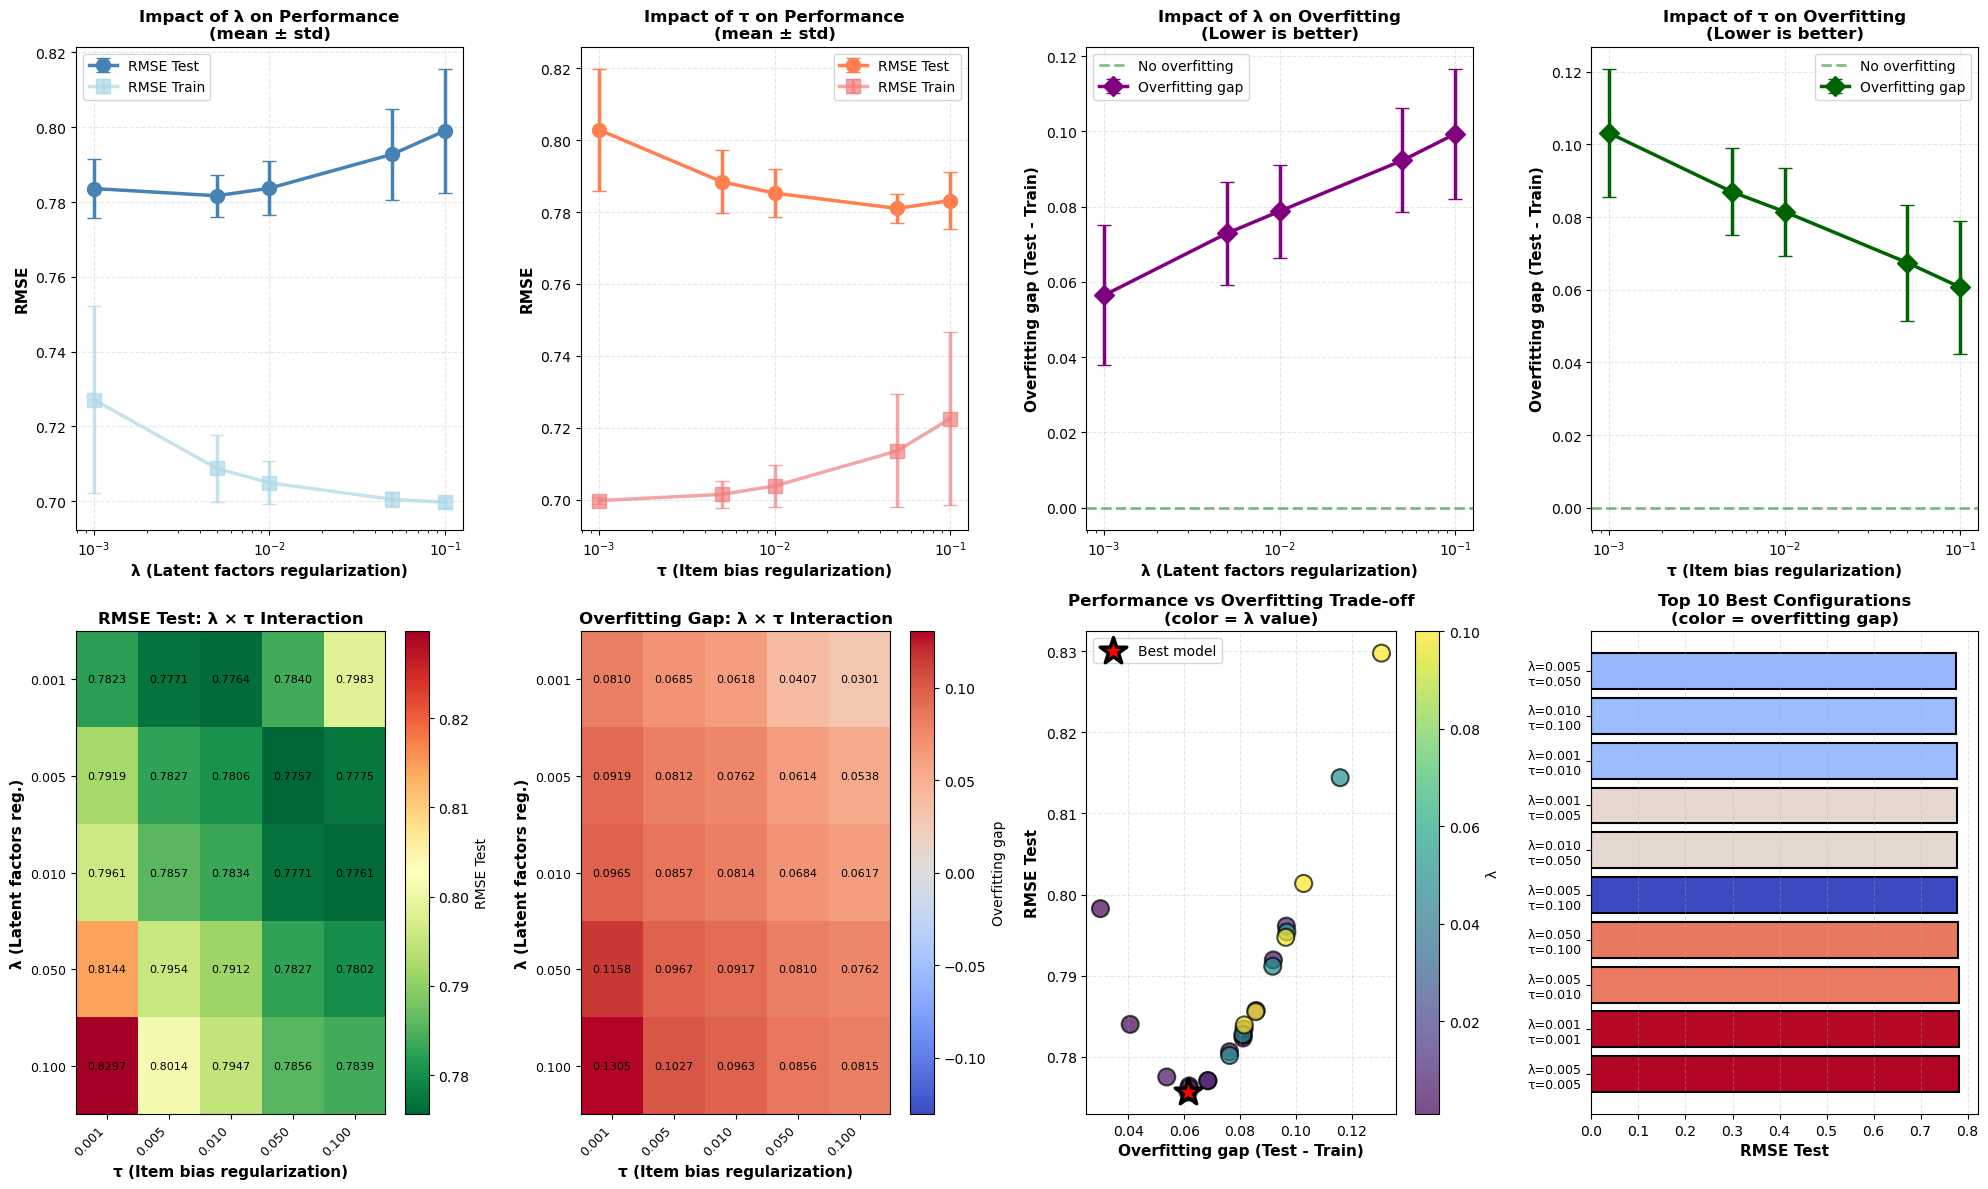


Grid Search completed!
Best λ: 0.005000
Best τ: 0.050000
Best RMSE: 0.775654

TRAINING FINAL MODEL WITH OPTIMAL PARAMETERS

Optimal hyperparameters:
  λ (lambda_reg) = 0.005000
  τ (tau_reg) = 0.050000
  γ (gamma_reg) = 0.010000

Training final model...

SAVING RESULTS
Results saved to 'optimal_hyperparameters.json'
Grid search results saved to 'grid_search_results.npy'

OPTIMIZATION COMPLETED SUCCESSFULLY!


In [ ]:

"""
from your_data_loader import load_movielens_data

data = load_movielens_data('path/to/dataset')
M = data['num_users']
N = data['num_items']
K = 10  # Number of latent factors

# Training data
user_ratings_train = data['user_ratings_train']
user_items_train = data['user_items_train']
user_start_end_train = data['user_start_end_train']

item_ratings_train = data['item_ratings_train']
item_users_train = data['item_users_train']
item_start_end_train = data['item_start_end_train']

# Test data
user_ratings_test = data['user_ratings_test']
user_items_test = data['user_items_test']
user_start_end_test = data['user_start_end_test']
"""


use_grid_search = True


use_random_search = False

if use_grid_search:
    print("\n" + "="*80)
    print("RUNNING GRID SEARCH")
    print("="*80)
    
    best_params_grid, all_results_grid = grid_search_lambda_tau(
        M, N, K,
        user_ratings_train, user_items_train, user_start_end_train,
        item_ratings_train, item_users_train, item_start_end_train,
        user_ratings_test, user_items_test, user_start_end_test,
        num_iterations=20 # Number of iterations for model training
    )
    
    # Visualize results
    print("\nGenerating visualization for Grid Search...")
    visualize_hyperparameter_impact(all_results_grid, search_type="Grid Search")
    
    print("\nGrid Search completed!")
    print(f"Best λ: {best_params_grid['lambda_reg']:.6f}")
    print(f"Best τ: {best_params_grid['tau_reg']:.6f}")
    print(f"Best RMSE: {best_params_grid['rmse_test']:.6f}")

if use_random_search:
    print("\n" + "="*80)
    print("RUNNING RANDOM SEARCH")
    print("="*80)
    
    best_params_random, all_results_random = random_search_lambda_tau(
        M, N, K,
        user_ratings_train, user_items_train, user_start_end_train,
        item_ratings_train, item_users_train, item_start_end_train,
        user_ratings_test, user_items_test, user_start_end_test,
        n_iterations=30,           # Number of random combinations to try
        num_iterations_model=50    # Number of iterations for model training
    )
    

    print("\nGenerating visualization for Random Search...")
    visualize_hyperparameter_impact(all_results_random, search_type="Random Search")
    
    print("\nRandom Search completed!")
    print(f"Best λ: {best_params_random['lambda_reg']:.6f}")
    print(f"Best τ: {best_params_random['tau_reg']:.6f}")
    print(f"Best RMSE: {best_params_random['rmse_test']:.6f}")



if use_grid_search and use_random_search:
    print("\n" + "="*80)
    print("COMPARING GRID SEARCH VS RANDOM SEARCH")
    print("="*80)
    
    print("\nGrid Search Results:")
    print(f"  λ = {best_params_grid['lambda_reg']:.6f}")
    print(f"  τ = {best_params_grid['tau_reg']:.6f}")
    print(f"  γ = {GAMMA_FIXED} (fixed)")
    print(f"  RMSE Test = {best_params_grid['rmse_test']:.6f}")
    print(f"  RMSE Train = {best_params_grid['rmse_train']:.6f}")
    print(f"  Overfitting gap = {best_params_grid['overfitting_gap']:.6f}")
    
    print("\nRandom Search Results:")
    print(f"  λ = {best_params_random['lambda_reg']:.6f}")
    print(f"  τ = {best_params_random['tau_reg']:.6f}")
    print(f"  γ = {GAMMA_FIXED} (fixed)")
    print(f"  RMSE Test = {best_params_random['rmse_test']:.6f}")
    print(f"  RMSE Train = {best_params_random['rmse_train']:.6f}")
    print(f"  Overfitting gap = {best_params_random['overfitting_gap']:.6f}")
    
    # Determine winner
    if best_params_grid['rmse_test'] < best_params_random['rmse_test']:
        winner = "Grid Search"
        best_params = best_params_grid
        diff = best_params_random['rmse_test'] - best_params_grid['rmse_test']
    else:
        winner = "Random Search"
        best_params = best_params_random
        diff = best_params_grid['rmse_test'] - best_params_random['rmse_test']
    
    improvement_pct = (diff / max(best_params_grid['rmse_test'], 
                                   best_params_random['rmse_test'])) * 100
    
    print(f"\nWinner: {winner}")
    print(f"RMSE improvement: {diff:.6f} ({improvement_pct:.2f}%)")



print("\n" + "="*80)
print("TRAINING FINAL MODEL WITH OPTIMAL PARAMETERS")
print("="*80)


if use_grid_search and use_random_search:
    final_params = best_params if best_params_grid['rmse_test'] < best_params_random['rmse_test'] else best_params
elif use_grid_search:
    final_params = best_params_grid
elif use_random_search:
    final_params = best_params_random
else:
    raise ValueError("No optimization method was selected!")

optimal_lambda = final_params['lambda_reg']
optimal_tau = final_params['tau_reg']
optimal_gamma = GAMMA_FIXED

print(f"\nOptimal hyperparameters:")
print(f"  λ (lambda_reg) = {optimal_lambda:.6f}")
print(f"  τ (tau_reg) = {optimal_tau:.6f}")
print(f"  γ (gamma_reg) = {optimal_gamma:.6f}")

# Train final model with optimal parameters
print("\nTraining final model...")
"""
final_model = train_and_evaluate_metrics(
    M, N, K,
    user_ratings_train, user_items_train, user_start_end_train,
    item_ratings_train, item_users_train, item_start_end_train,
    user_ratings_test, user_items_test, user_start_end_test,
    lambda_reg=optimal_lambda,
    gamma_reg=optimal_gamma,
    tau_reg=optimal_tau,
    num_iterations=100  # More iterations for final model
)

print("\nFinal model performance:")
print(f"  RMSE Train = {final_model['rmse_train'][-1]:.6f}")
print(f"  RMSE Test = {final_model['rmse_test'][-1]:.6f}")
"""



print("\n" + "="*80)
print("SAVING RESULTS")
print("="*80)


import json

results_summary = {
    "optimal_parameters": {
        "lambda": float(optimal_lambda),
        "tau": float(optimal_tau),
        "gamma": float(optimal_gamma)
    },
    "performance": {
        "rmse_train": float(final_params['rmse_train']),
        "rmse_test": float(final_params['rmse_test']),
        "overfitting_gap": float(final_params['overfitting_gap'])
    },
    "search_method": winner if use_grid_search and use_random_search else 
                     ("Grid Search" if use_grid_search else "Random Search")
}

with open('optimal_hyperparameters.json', 'w') as f:
    json.dump(results_summary, f, indent=4)

print("Results saved to 'optimal_hyperparameters.json'")

# Optionally save all results for further analysis
if use_grid_search:
    np.save('grid_search_results.npy', all_results_grid)
    print("Grid search results saved to 'grid_search_results.npy'")

if use_random_search:
    np.save('random_search_results.npy', all_results_random)
    print("Random search results saved to 'random_search_results.npy'")

print("\n" + "="*80)
print("OPTIMIZATION COMPLETED SUCCESSFULLY!")
print("="*80)

## Prediction

### Using best models

In [ ]:
# --- Hyperparameters ---
M = len(user_to_index)
N = len(movie_to_index)
K = 10
lambda_reg = 0.005   # λ : weight on reconstruction error
gamma_reg = 0.01    # γ : weight on biases
tau_reg = 0.05      # τ : weight on latent factor norms
num_iterations = 30


user_ratings_train, user_items_train, user_start_end_train, \
    item_ratings_train, item_users_train, item_start_end_train = \
        prepare_flat_data(data_by_user_train, data_by_movie_train, M, N)

user_ratings_test, user_items_test, user_start_end_test, _, _, _ = \
        prepare_flat_data(data_by_user_test, data_by_movie_train, M, N)

results = train_and_evaluate_metrics(M, N, K, 
user_ratings_train, user_items_train, user_start_end_train, \
    item_ratings_train, item_users_train, item_start_end_train, user_ratings_test, user_items_test, user_start_end_test, 
                               lambda_reg, gamma_reg, tau_reg, num_iterations)


In [ ]:
import numpy as np
import pickle
import os
from datetime import datetime


# --- Hyperparameters ---
M = len(user_to_index)
N = len(movie_to_index)
K = 10
lambda_reg = 0.005   # λ : weight on reconstruction error
gamma_reg = 0.01     # γ : weight on biases
tau_reg = 0.05       # τ : weight on latent factor norms
num_iterations = 30

print("="*80)
print("MODEL CONFIGURATION")
print("="*80)
print(f"Number of users (M): {M}")
print(f"Number of items (N): {N}")
print(f"Latent factors (K): {K}")
print(f"Lambda (λ) regularization: {lambda_reg}")
print(f"Gamma (γ) regularization: {gamma_reg}")
print(f"Tau (τ) regularization: {tau_reg}")
print(f"Number of iterations: {num_iterations}")
print("="*80 + "\n")

def train_and_evaluate_metrics(M, N, K, 
                               user_ratings_train, user_items_train, user_start_end_train,
                               item_ratings_train, item_users_train, item_start_end_train, 
                               user_ratings_test, user_items_test, user_start_end_test, 
                               lambda_reg, gamma_reg, tau_reg, num_iterations):
    """
    Train ALS model with λ, γ, and τ regularization terms using flat data structures.
    Computes metrics at each iteration.
    """
    # Initialize parameters
    user_biases = np.zeros(M, dtype=np.float32)
    item_biases = np.zeros(N, dtype=np.float32)
    user_factors = np.random.normal(0, 0.1, (M, K)).astype(np.float32)
    item_factors = np.random.normal(0, 0.1, (N, K)).astype(np.float32)

    loss_history, rmse_train, rmse_test = [], [], []

    print("Starting ALS training with λ, γ, τ terms...")
    print("-" * 80)

    # Train one iteration at a time to compute metrics
    for iteration in range(num_iterations):
        user_biases, item_biases, user_factors, item_factors = update_biases_and_factors(
            M, N, K,
            user_ratings_train, user_items_train, user_start_end_train,
            item_ratings_train, item_users_train, item_start_end_train,
            user_biases, item_biases, user_factors, item_factors,
            lambda_reg, gamma_reg, tau_reg, 1  # 1 iteration at a time
        )

        # Compute metrics
        loss = calculate_loss_negatif(
            user_ratings_train, user_items_train, user_start_end_train, M,
            user_biases, item_biases, user_factors, item_factors,
            lambda_reg, gamma_reg, tau_reg
        )
        loss_history.append(loss)

        rmse_tr = calculate_rmse(
            user_ratings_train, user_items_train, user_start_end_train, M,
            user_biases, item_biases, user_factors, item_factors
        )
        rmse_train.append(rmse_tr)

        rmse_te = calculate_rmse(
            user_ratings_test, user_items_test, user_start_end_test, M,
            user_biases, item_biases, user_factors, item_factors
        )
        rmse_test.append(rmse_te)

        if (iteration + 1) % 10 == 0 or iteration == 0:
            print(f"Iteration {iteration+1:3d}/{num_iterations} | "
                  f"Train RMSE: {rmse_tr:.4f} | Test RMSE: {rmse_te:.4f} | Loss: {loss:.4f}")

    print("-" * 80)
    print("✓ Training completed successfully!")
    print(f"Final Train RMSE: {rmse_train[-1]:.4f}")
    print(f"Final Test RMSE:  {rmse_test[-1]:.4f}")
    print(f"Final Loss:       {loss_history[-1]:.4f}")

    return {
        "loss_history": loss_history,
        "rmse_train": rmse_train,
        "rmse_test": rmse_test,
        "user_biases": user_biases,
        "item_biases": item_biases,
        "user_factors": user_factors,
        "item_factors": item_factors
    }

print("\nPreparing training and test data...")
user_ratings_train, user_items_train, user_start_end_train, \
    item_ratings_train, item_users_train, item_start_end_train = \
        prepare_flat_data(data_by_user_train, data_by_movie_train, M, N)

user_ratings_test, user_items_test, user_start_end_test, _, _, _ = \
        prepare_flat_data(data_by_user_test, data_by_movie_train, M, N)

print(f"✓ Training data prepared: {len(user_ratings_train)} ratings")
print(f"✓ Test data prepared: {len(user_ratings_test)} ratings\n")


results = train_and_evaluate_metrics(
    M, N, K, 
    user_ratings_train, user_items_train, user_start_end_train,
    item_ratings_train, item_users_train, item_start_end_train, 
    user_ratings_test, user_items_test, user_start_end_test, 
    lambda_reg, gamma_reg, tau_reg, num_iterations
)


print("\n" + "="*80)
print("PREPARING RESULTS FOR SAVING")
print("="*80)

# Create comprehensive results dictionary
complete_results = {
    # Model parameters
    'hyperparameters': {
        'M': M,
        'N': N,
        'K': K,
        'lambda_reg': lambda_reg,
        'gamma_reg': gamma_reg,
        'tau_reg': tau_reg,
        'num_iterations': num_iterations
    },
    
    # Training results
    'training_results': {
        'loss_history': results['loss_history'],
        'rmse_train': results['rmse_train'],
        'rmse_test': results['rmse_test'],
        'final_train_rmse': results['rmse_train'][-1],
        'final_test_rmse': results['rmse_test'][-1],
        'final_loss': results['loss_history'][-1]
    },
    
    # Model parameters (for prediction)
    'model_parameters': {
        'user_biases': results['user_biases'],
        'item_biases': results['item_biases'],
        'user_factors': results['user_factors'],
        'item_factors': results['item_factors']
    },
    
    # Mappings (essential for prediction on new data)
    'mappings': {
        'user_to_index': user_to_index,
        'movie_to_index': movie_to_index,
        'index_to_user': {v: k for k, v in user_to_index.items()},
        'index_to_movie': {v: k for k, v in movie_to_index.items()}
    },
    
    # Metadata
    'metadata': {
        'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'num_train_ratings': len(user_ratings_train),
        'num_test_ratings': len(user_ratings_test),
        'train_data_shape': (M, N),
    }
}


output_dir = "trained_models"
os.makedirs(output_dir, exist_ok=True)


timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
filename = f"als_model_K{K}_lambda{lambda_reg}_gamma{gamma_reg}_tau{tau_reg}_{timestamp}.pkl"
filepath = os.path.join(output_dir, filename)

# Save to pickle
print(f"\nSaving results to: {filepath}")
with open(filepath, 'wb') as f:
    pickle.dump(complete_results, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f" Results saved successfully!")


latest_filepath = os.path.join(output_dir, "als_model_latest.pkl")
with open(latest_filepath, 'wb') as f:
    pickle.dump(complete_results, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f"✓ Latest model saved to: {latest_filepath}")

# =============================================================================
# DISPLAY SAVE SUMMARY
# =============================================================================
print("\n" + "="*80)
print("SAVE SUMMARY")
print("="*80)
print(f"Model file: {filename}")
print(f"Location: {output_dir}/")
print(f"File size: {os.path.getsize(filepath) / (1024*1024):.2f} MB")
print("\nSaved contents:")
print("  ✓ Hyperparameters (K, λ, γ, τ)")
print("  ✓ Training history (loss, RMSE)")
print("  ✓ Model parameters (biases, factors)")
print("  ✓ User/Movie mappings")
print("  ✓ Metadata (timestamp, data info)")
print("="*80)

# =============================================================================
# EXAMPLE: HOW TO LOAD AND USE THE MODEL FOR PREDICTION
# =============================================================================
print("\n" + "="*80)
print("USAGE EXAMPLE: Loading and Making Predictions")
print("="*80)
print("""
# To load the saved model later:
with open('trained_models/als_model_latest.pkl', 'rb') as f:
    loaded_results = pickle.load(f)

# Extract model parameters
user_biases = loaded_results['model_parameters']['user_biases']
item_biases = loaded_results['model_parameters']['item_biases']
user_factors = loaded_results['model_parameters']['user_factors']
item_factors = loaded_results['model_parameters']['item_factors']

# Extract mappings
user_to_index = loaded_results['mappings']['user_to_index']
movie_to_index = loaded_results['mappings']['movie_to_index']

# Make a prediction for user_id and movie_id
def predict_rating(user_id, movie_id, user_biases, item_biases, 
                   user_factors, item_factors, user_to_index, movie_to_index):
    if user_id not in user_to_index or movie_id not in movie_to_index:
        return None  # Unknown user or movie
    
    u_idx = user_to_index[user_id]
    i_idx = movie_to_index[movie_id]
    
    prediction = (np.dot(user_factors[u_idx], item_factors[i_idx]) + 
                  user_biases[u_idx] + item_biases[i_idx])
    
    # Clip to valid rating range [1, 5]
    return np.clip(prediction, 1, 5)

# Example prediction
user_id = 1
movie_id = 50
pred = predict_rating(user_id, movie_id, user_biases, item_biases,
                     user_factors, item_factors, user_to_index, movie_to_index)
print(f"Predicted rating for user {user_id}, movie {movie_id}: {pred:.2f}")
""")
print("="*80)


print("\n" + "="*80)
print("VERIFICATION: Loading saved model...")
print("="*80)

with open(filepath, 'rb') as f:
    loaded_results = pickle.load(f)

print("✓ Model loaded successfully!")
print(f"  Loaded K value: {loaded_results['hyperparameters']['K']}")
print(f"  Loaded final test RMSE: {loaded_results['training_results']['final_test_rmse']:.4f}")
print(f"  User factors shape: {loaded_results['model_parameters']['user_factors'].shape}")
print(f"  Item factors shape: {loaded_results['model_parameters']['item_factors'].shape}")
print(f"  Number of users in mapping: {len(loaded_results['mappings']['user_to_index'])}")
print(f"  Number of movies in mapping: {len(loaded_results['mappings']['movie_to_index'])}")
print("\n✓ All data verified correctly!")
print("="*80)

MODEL CONFIGURATION
Number of users (M): 200948
Number of items (N): 84432
Latent factors (K): 10
Lambda (λ) regularization: 0.005
Gamma (γ) regularization: 0.01
Tau (τ) regularization: 0.05
Number of iterations: 30


Preparing training and test data...
✓ Training data prepared: 28709236 ratings
✓ Test data prepared: 3290968 ratings

Starting ALS training with λ, γ, τ terms...
--------------------------------------------------------------------------------
Iteration   1/30 | Train RMSE: 0.8392 | Test RMSE: 0.8746 | Loss: 65407.4438
Iteration  10/30 | Train RMSE: 0.7160 | Test RMSE: 0.7770 | Loss: 52304.6753
Iteration  20/30 | Train RMSE: 0.7144 | Test RMSE: 0.7761 | Loss: 51969.6828
Iteration  30/30 | Train RMSE: 0.7141 | Test RMSE: 0.7760 | Loss: 51871.4368
--------------------------------------------------------------------------------
✓ Training completed successfully!
Final Train RMSE: 0.7141
Final Test RMSE:  0.7760
Final Loss:       51871.4368

PREPARING RESULTS FOR SAVING

Savin

In [ ]:




movie_id_to_title = {}
movies_file_path = r"C:\Users\TIAO ELIASSE\OneDrive\Desktop\AimsSud\ML at scale\ml-32m\movies.csv"

try:
    if 'results' not in locals():
        raise NameError("'results' is not defined. Please train the model first.")

    item_factors = results.get('item_factors')
    item_biases  = results.get('item_biases')

    if item_factors is None or item_biases is None:
        raise KeyError("'item_factors' or 'item_biases' not found in 'results'.")

    if 'K' not in locals() or 'lambda_reg' not in locals() or 'tau_reg' not in locals():
        raise NameError("K, lambda_reg or tau_reg not defined.")

    if 'movie_to_index' not in locals() or 'index_to_movie' not in locals():
        raise NameError("movie_to_index or index_to_movie not defined.")

    print(f"Parameters extracted: item_factors shape = {item_factors.shape}")
    print(f"Hyperparameters retrieved: K={K}, lambda={lambda_reg}, tau={tau_reg}")

    # Load movie titles
    with open(movies_file_path, newline='', encoding='utf-8') as csvfile:
        reader = csv.reader(csvfile)
        next(reader)
        for row in reader:
            movie_id_to_title[row[0]] = row[1]

    print(f"Loaded {len(movie_id_to_title)} movie titles.")
    prerequis_ok = True

except Exception as e:
    print(f"PREREQUISITE ERROR: {e}")
    prerequis_ok = False

--- Starting post-training analysis script ---
Parameters extracted: item_factors shape = (84432, 10)
Hyperparameters retrieved: K=10, lambda=0.005, tau=0.05
Loaded 87585 movie titles.


In [ ]:




@njit
def fit_new_user_optimized(movie_indices, ratings, item_factors, item_biases,
                          K, lambda_reg, tau_reg, num_iterations=50, eps=1e-8):
    """
    Optimized version using single loops and Numba JIT compilation.

    Parameters
    ----------
    movie_indices : np.array
        Array of movie indices that the user rated
    ratings : np.array
        Array of ratings given by the user
    item_factors : np.array
        Item factor matrix (N x K)
    item_biases : np.array
        Item bias vector
    K : int
        Number of latent factors
    lambda_reg, tau_reg : float
        Regularization parameters
    num_iterations : int
        Number of iterations for optimization
    eps : float
        Small constant for numerical stability

    Returns
    -------
    tuple
        (user_factor, user_bias)
    """
    user_bias = 0.0
    user_factor = np.random.normal(0, 0.1, K).astype(np.float32)

    n = len(movie_indices)
    I = np.eye(K, dtype=np.float32)

    # Extract relevant item factors and biases
    V_m = np.zeros((n, K), dtype=np.float32)
    b_i_m = np.zeros(n, dtype=np.float32)

    for i in range(n):
        idx = movie_indices[i]
        b_i_m[i] = item_biases[idx]
        for k in range(K):
            V_m[i, k] = item_factors[idx, k]

    for iteration in range(num_iterations):
        # Update user bias
        preds = np.zeros(n, dtype=np.float32)
        for i in range(n):
            # Compute dot product
            dot_prod = 0.0
            for k in range(K):
                dot_prod += V_m[i, k] * user_factor[k]
            preds[i] = dot_prod

        residuals_sum = 0.0
        for i in range(n):
            residuals_sum += ratings[i] - preds[i] - b_i_m[i]

        num = lambda_reg * residuals_sum
        den = lambda_reg * n + tau_reg
        user_bias = num / (den + eps)

        # Update user factor
        r_adj = np.zeros(n, dtype=np.float32)
        for i in range(n):
            r_adj[i] = ratings[i] - user_bias - b_i_m[i]

        # A = lambda_reg * (V_m.T @ V_m) + tau_reg * I + eps * I
        A = np.zeros((K, K), dtype=np.float32)
        for i in range(K):
            for j in range(K):
                # Compute V_m.T @ V_m
                for idx in range(n):
                    A[i, j] += lambda_reg * V_m[idx, i] * V_m[idx, j]
                # Add regularization
                if i == j:
                    A[i, j] += tau_reg + eps

        # b = lambda_reg * (V_m.T @ r_adj)
        b = np.zeros(K, dtype=np.float32)
        for k in range(K):
            for idx in range(n):
                b[k] += lambda_reg * V_m[idx, k] * r_adj[idx]

        user_factor = np.linalg.solve(A, b)

    return user_factor, user_bias



In [68]:

def fit_new_user(user_ratings, item_factors, item_biases,
                 K, lambda_reg, tau_reg, num_iterations=50, eps=1e-8):
    """
    Wrapper function to prepare data and call optimized version.
    """
    movie_indices = np.array([idx for idx, rating in user_ratings], dtype=np.int32)
    ratings = np.array([rating for idx, rating in user_ratings], dtype=np.float32)

    return fit_new_user_optimized(
        movie_indices, ratings, item_factors, item_biases,
        K, lambda_reg, tau_reg, num_iterations, eps
    )


In [69]:


# --- Vectorized prediction function for a user ---
@njit
def predict_all_for_user(user_factor, item_factors, user_bias, item_biases):
    """
    Returns a vector of predictions for all items for a given user.
    Uses single loops for efficiency.

    Parameters
    ----------
    user_factor : np.array
        User factor vector (K,)
    item_factors : np.array
        Item factor matrix (N, K)
    user_bias : float
        User bias
    item_biases : np.array
        Item bias vector (N,)

    Returns
    -------
    np.array
        Predictions for all items
    """
    N = item_factors.shape[0]
    K = item_factors.shape[1]
    predictions = np.zeros(N, dtype=np.float32)

    for n in range(N):
        # Compute dot product
        dot_prod = 0.0
        for k in range(K):
            dot_prod += user_factor[k] * item_factors[n, k]
        predictions[n] = dot_prod + user_bias + item_biases[n]

    return predictions


In [70]:


# --- Step 2: Recommendations for Dummy User ---
print("\n" + "="*50)
print("--- Task 1: Recommendations for Dummy User ---")
print("="*50)

if prerequis_ok:
    try:
        target_movie_title = "Lord of the Rings: The Fellowship of the Ring"
        target_movie_id = None
        target_movie_index = None

        # Search for the movie
        for movie_id, title in movie_id_to_title.items():
            if target_movie_title in title:
                target_movie_id = movie_id
                break

        if target_movie_id and target_movie_id in movie_to_index:

            target_movie_index = movie_to_index[target_movie_id]
            print(f"Dummy user rates '{target_movie_title}' with 5 stars.")

            dummy_user_ratings = [(target_movie_index, 5.0)]
            new_user_factor, new_user_bias = fit_new_user(
                dummy_user_ratings,
                item_factors,
                item_biases,
                K,
                lambda_reg,
                tau_reg
            )

            print(f"Factors computed. User bias = {new_user_bias:.4f}")

            # --- Use vectorized function ---
            all_predictions = predict_all_for_user(
                new_user_factor, item_factors, new_user_bias, item_biases
            )

            # Sort all movies by prediction score
            top_movie_indices = np.argsort(all_predictions)[::-1]

            # Find the rank of the target movie
            target_rank = np.where(top_movie_indices == target_movie_index)[0][0] + 1
            target_score = all_predictions[target_movie_index]

            print(f"\n'{target_movie_title}' is ranked #{target_rank} with score {target_score:.4f}")

            top_n = 10
            print(f"\nTop {top_n} recommendations :\n")

            shown = 0
            for i in top_movie_indices:
                #if i == target_movie_index:
                    #continue
                movie_id = index_to_movie[i]
                title = movie_id_to_title.get(movie_id, "Unknown title")
                print(f" {shown+1}. {title} (score = {all_predictions[i]:.4f})")
                shown += 1
                if shown >= top_n:
                    break
        else:
            print(f"Movie not found: '{target_movie_title}'")

    except Exception as e:
        print(f"Error in task 1: {e}")




--- Task 1: Recommendations for Dummy User ---
Dummy user rates 'Lord of the Rings: The Fellowship of the Ring' with 5 stars.
Factors computed. User bias = 0.0821

'Lord of the Rings: The Fellowship of the Ring' is ranked #2 with score 4.1794

Top 10 recommendations :

 1. Lord of the Rings: The Return of the King, The (2003) (score = 4.2144)
 2. Lord of the Rings: The Fellowship of the Ring, The (2001) (score = 4.1794)
 3. Lord of the Rings: The Two Towers, The (2002) (score = 4.1080)
 4. Wesley (2009) (score = 3.4200)
 5. SpongeBob SquarePants: Heroes of Bikini Bottom (2011) (score = 3.3128)
 6. WWE: The Triumph and Tragedy of World Class Championship Wrestling (2007) (score = 3.3128)
 7. Black Harvest (1992) (score = 3.1056)
 8. The Sound of Violet (2022) (score = 3.1029)
 9. A Dramatic Film (2019) (score = 3.0897)
 10. Star Wars: Episode IV - A New Hope (1977) (score = 3.0330)


In [72]:

# --- Step 3: Polarizing movies ---
print("\n" + "="*50)
print("--- Task 2: Most polarizing movies ---")
print("="*50)

if prerequis_ok:
    try:
        # Compute norms using single loop (for consistency)
        N = item_factors.shape[0]
        K = item_factors.shape[1]
        magnitudes = np.zeros(N, dtype=np.float32)

        for n in range(N):
            norm_squared = 0.0
            for k in range(K):
                norm_squared += item_factors[n, k] ** 2
            magnitudes[n] = np.sqrt(norm_squared)

        top_n = 10
        indices = np.argsort(magnitudes)[::-1][:top_n]

        print("\nMost polarizing movies (latent vector norm):\n")
        for rank, idx in enumerate(indices, 1):
            movie_id = index_to_movie[idx]
            title = movie_id_to_title.get(movie_id, "Unknown title")
            print(f"{rank}. {title}  (|v| = {magnitudes[idx]:.4f})")

    except Exception as e:
        print(f"Error in task 2: {e}")

print("\n--- Analysis script completed ---")


--- Task 2: Most polarizing movies ---

Most polarizing movies (latent vector norm):

1. Dumb & Dumber (Dumb and Dumber) (1994)  (|v| = 7.1907)
2. Lord of the Rings: The Return of the King, The (2003)  (|v| = 6.6861)
3. Lord of the Rings: The Fellowship of the Ring, The (2001)  (|v| = 6.6248)
4. Star Wars: Episode IV - A New Hope (1977)  (|v| = 6.5730)
5. Lord of the Rings: The Two Towers, The (2002)  (|v| = 6.5544)
6. Star Wars: Episode V - The Empire Strikes Back (1980)  (|v| = 6.4031)
7. Star Wars: Episode II - Attack of the Clones (2002)  (|v| = 6.3907)
8. Ace Ventura: Pet Detective (1994)  (|v| = 6.3090)
9. Star Wars: Episode I - The Phantom Menace (1999)  (|v| = 6.2786)
10. Saw (2004)  (|v| = 6.2419)

--- Analysis script completed ---


#### without ubiases

Tricks of the trade:
Create a “dummy user” that gave some movie like a “Lord of the Rings” five stars. Are the top recommendations other “Lord of the Rings” movies? You’ll need the 25M dataset for this to start looking really nice. You used something like:


score_for_item[n] = user_trait_vector[m].inner(item_trait_vector[n]) + item_bias[n]


for all movies n. (Your recommendation score for a user is independent of the user bias, hence you didn’t add that.) This will not look nice because some “high bias” or popular movies will invariably always sit at the top. To increase the personalization component, try ranking with
score_for_item[n] = user_trait_vector[m].inner(item_trait_vector[n]) + 0.05 * item_bias[n]


where the contribution of the item bias is downplayed.



In [ ]:

@njit
def predict_all_for_user_without_user_bias(user_factor, item_factors, user_bias, item_biases,weight):
    """
    Returns a vector of predictions for all items for a given user.
    Uses single loops for efficiency.

    Parameters
    ----------
    user_factor : np.array
        User factor vector (K,)
    item_factors : np.array
        Item factor matrix (N, K)
    user_bias : float
        User bias
    item_biases : np.array
        Item bias vector (N,)

    Returns
    -------
    np.array
        Predictions for all items
    """
    N = item_factors.shape[0]
    K = item_factors.shape[1]
    predictions = np.zeros(N, dtype=np.float32)

    for n in range(N):
        # Compute dot product
        dot_prod = 0.0
        for k in range(K):
            dot_prod += user_factor[k] * item_factors[n, k]
        #predictions[n] = dot_prod + user_bias + item_biases[n]
        predictions[n] = dot_prod +  weight*item_biases[n]
    return predictions


In [ ]:


if prerequis_ok:
    try:
        target_movie_title = "Lord of the Rings: The Fellowship of the Ring"
        target_movie_id = None
        target_movie_index = None

        # Search for the movie
        for movie_id, title in movie_id_to_title.items():
            if target_movie_title in title:
                target_movie_id = movie_id
                break

        if target_movie_id and target_movie_id in movie_to_index:

            target_movie_index = movie_to_index[target_movie_id]
            print(f"Dummy user rates '{target_movie_title}' with 5 stars.")

            dummy_user_ratings = [(target_movie_index, 5.0)]
            new_user_factor, new_user_bias = fit_new_user(
                dummy_user_ratings,
                item_factors,
                item_biases,
                K,
                lambda_reg,
                tau_reg
            )

            print(f"Factors computed. User bias = {new_user_bias:.4f}")

            # --- Use vectorized function ---
            all_predictions = predict_all_for_user_without_user_bias(
                new_user_factor, item_factors, new_user_bias, item_biases,1
            )

            # Sort all movies by prediction score
            top_movie_indices = np.argsort(all_predictions)[::-1]

            # Find the rank of the target movie
            target_rank = np.where(top_movie_indices == target_movie_index)[0][0] + 1
            target_score = all_predictions[target_movie_index]

            print(f"\n'{target_movie_title}' is ranked #{target_rank} with score {target_score:.4f}")

            top_n = 10
            print(f"\nTop {top_n} recommendations ")

            shown = 0
            for i in top_movie_indices:
                #if i == target_movie_index:
                    #continue
                movie_id = index_to_movie[i]
                title = movie_id_to_title.get(movie_id, "Unknown title")
                print(f" {shown+1}. {title} (score = {all_predictions[i]:.4f})")
                shown += 1
                if shown >= top_n:
                    break
        else:
            print(f"Movie not found: '{target_movie_title}'")

    except Exception as e:
        print(f"Error in task 1: {e}")




--- Task 1: Recommendations for Dummy User ---
Dummy user rates 'Lord of the Rings: The Fellowship of the Ring' with 5 stars.
Factors computed. User bias = 0.0821

'Lord of the Rings: The Fellowship of the Ring' is ranked #2 with score 4.0973

Top 10 recommendations 
 1. Lord of the Rings: The Return of the King, The (2003) (score = 4.1323)
 2. Lord of the Rings: The Fellowship of the Ring, The (2001) (score = 4.0973)
 3. Lord of the Rings: The Two Towers, The (2002) (score = 4.0259)
 4. Wesley (2009) (score = 3.3380)
 5. SpongeBob SquarePants: Heroes of Bikini Bottom (2011) (score = 3.2307)
 6. WWE: The Triumph and Tragedy of World Class Championship Wrestling (2007) (score = 3.2307)
 7. Black Harvest (1992) (score = 3.0236)
 8. The Sound of Violet (2022) (score = 3.0209)
 9. A Dramatic Film (2019) (score = 3.0076)
 10. Star Wars: Episode IV - A New Hope (1977) (score = 2.9510)


In [ ]:



print("\n" + "="*50)
print("--- Task 1: Recommendations for Dummy User ---")
print("="*50)

if prerequis_ok:
    try:
        target_movie_title = "Lord of the Rings: The Fellowship of the Ring"
        target_movie_id = None
        target_movie_index = None

        # Search for the movie
        for movie_id, title in movie_id_to_title.items():
            if target_movie_title in title:
                target_movie_id = movie_id
                break

        if target_movie_id and target_movie_id in movie_to_index:

            target_movie_index = movie_to_index[target_movie_id]
            print(f"Dummy user rates '{target_movie_title}' with 5 stars.")

            dummy_user_ratings = [(target_movie_index, 5.0)]
            new_user_factor, new_user_bias = fit_new_user(
                dummy_user_ratings,
                item_factors,
                item_biases,
                K,
                lambda_reg,
                tau_reg
            )

            print(f"Factors computed. User bias = {new_user_bias:.4f}")

            # --- Use vectorized function ---
            all_predictions = predict_all_for_user_without_user_bias(
                new_user_factor, item_factors, new_user_bias, item_biases,0.05
            )

            # Sort all movies by prediction score
            top_movie_indices = np.argsort(all_predictions)[::-1]

            # Find the rank of the target movie
            target_rank = np.where(top_movie_indices == target_movie_index)[0][0] + 1
            target_score = all_predictions[target_movie_index]

            print(f"\n'{target_movie_title}' is ranked #{target_rank} with score {target_score:.4f}")

            top_n = 10
            print(f"\nTop {top_n} recommendations ")

            shown = 0
            for i in top_movie_indices:
                #if i == target_movie_index:stochastic
                    #continue
                movie_id = index_to_movie[i]
                title = movie_id_to_title.get(movie_id, "Unknown title")
                print(f" {shown+1}. {title} (score = {all_predictions[i]:.4f})")
                shown += 1
                if shown >= top_n:
                    break
        else:
            print(f"Movie not found: '{target_movie_title}'")

    except Exception as e:
        print(f"Error in task 1: {e}")




--- Task 1: Recommendations for Dummy User ---
Dummy user rates 'Lord of the Rings: The Fellowship of the Ring' with 5 stars.
Factors computed. User bias = 0.0365

'Lord of the Rings: The Fellowship of the Ring' is ranked #2 with score 2.5923

Top 10 recommendations 
 1. Lord of the Rings: The Return of the King, The (2003) (score = 2.6112)
 2. Lord of the Rings: The Fellowship of the Ring, The (2001) (score = 2.5923)
 3. Lord of the Rings: The Two Towers, The (2002) (score = 2.5391)
 4. Star Wars: Episode I - The Phantom Menace (1999) (score = 1.5000)
 5. Star Wars: Episode IV - A New Hope (1977) (score = 1.4153)
 6. Star Wars: Episode VI - Return of the Jedi (1983) (score = 1.3870)
 7. Star Wars: Episode V - The Empire Strikes Back (1980) (score = 1.3619)
 8. Star Wars: Episode III - Revenge of the Sith (2005) (score = 1.3414)
 9. Star Wars: Episode II - Attack of the Clones (2002) (score = 1.3197)
 10. Braveheart (1995) (score = 1.1299)


In [ ]:
##

### wthe prediction using graph


MOVIE RECOMMENDATIONS VISUALIZATION FOR REPORT

Dummy user rates 'Lord of the Rings: The Fellowship of the Ring' with 5 stars
User factors computed. User bias = 0.0821

GENERATING INDIVIDUAL METHOD VISUALIZATIONS

────────────────────────────────────────────────────────────────────────────────
METHOD: Method with β=0.05
────────────────────────────────────────────────────────────────────────────────
'Lord of the Rings: The Fellowship of the Ring' is ranked #2 with score 3.6265
Saved: recommendation_plots\01_recommendations_Method_with_β=0.05.pdf


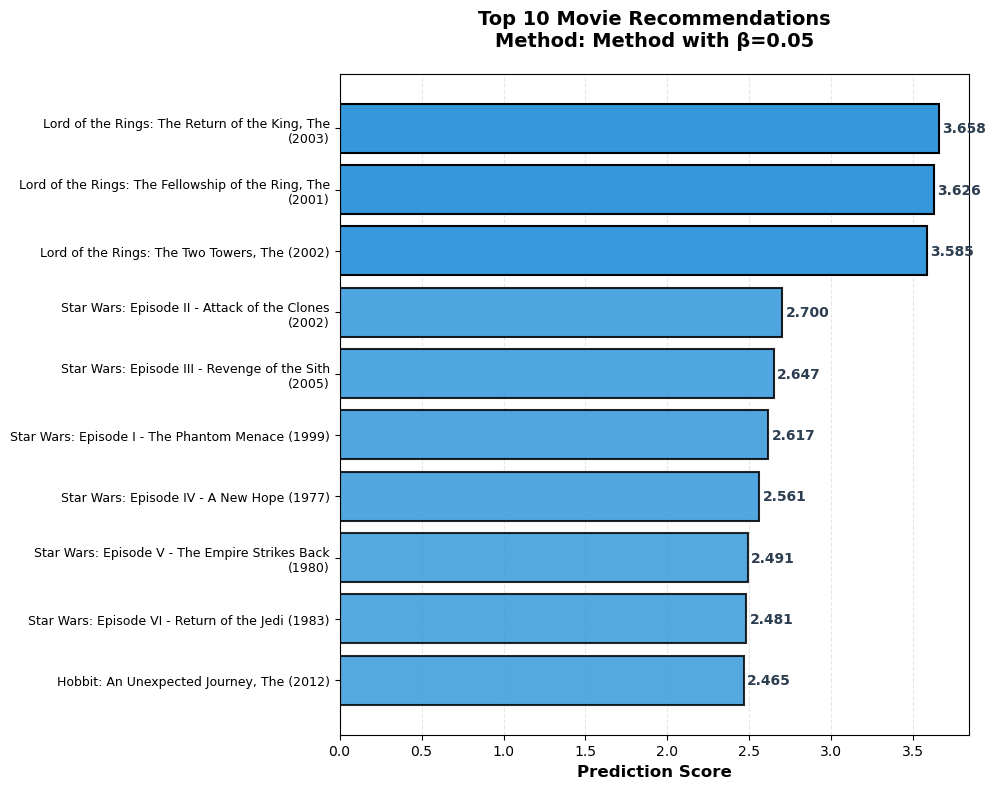


Top 10 recommendations:
   1. Lord of the Rings: The Return of the King, The (2003) | Score: 3.6579
   2. Lord of the Rings: The Fellowship of the Ring, The (2001) | Score: 3.6265
   3. Lord of the Rings: The Two Towers, The (2002)      | Score: 3.5849
   4. Star Wars: Episode II - Attack of the Clones (2002) | Score: 2.7000
   5. Star Wars: Episode III - Revenge of the Sith (2005) | Score: 2.6474
   6. Star Wars: Episode I - The Phantom Menace (1999)   | Score: 2.6166
   7. Star Wars: Episode IV - A New Hope (1977)          | Score: 2.5610
   8. Star Wars: Episode V - The Empire Strikes Back (1980) | Score: 2.4909
   9. Star Wars: Episode VI - Return of the Jedi (1983)  | Score: 2.4814
  10. Hobbit: An Unexpected Journey, The (2012)          | Score: 2.4647

────────────────────────────────────────────────────────────────────────────────
METHOD: Method with β=1
────────────────────────────────────────────────────────────────────────────────
'Lord of the Rings: The Fellowship of the R

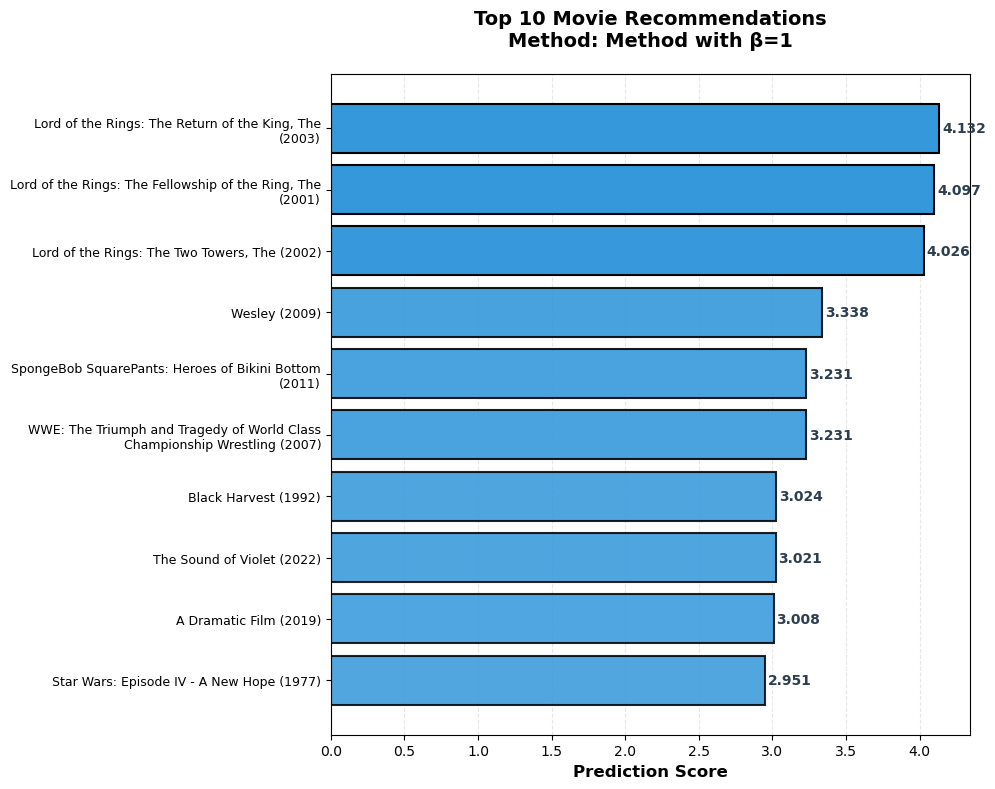


Top 10 recommendations:
   1. Lord of the Rings: The Return of the King, The (2003) | Score: 4.1323
   2. Lord of the Rings: The Fellowship of the Ring, The (2001) | Score: 4.0973
   3. Lord of the Rings: The Two Towers, The (2002)      | Score: 4.0259
   4. Wesley (2009)                                      | Score: 3.3380
   5. SpongeBob SquarePants: Heroes of Bikini Bottom (2011) | Score: 3.2307
   6. WWE: The Triumph and Tragedy of World Class Championship Wrestling (2007) | Score: 3.2307
   7. Black Harvest (1992)                               | Score: 3.0236
   8. The Sound of Violet (2022)                         | Score: 3.0209
   9. A Dramatic Film (2019)                             | Score: 3.0076
  10. Star Wars: Episode IV - A New Hope (1977)          | Score: 2.9510

GENERATING COMPARISON VISUALIZATION
Saved: recommendation_plots\02_comparison_all_methods.pdf


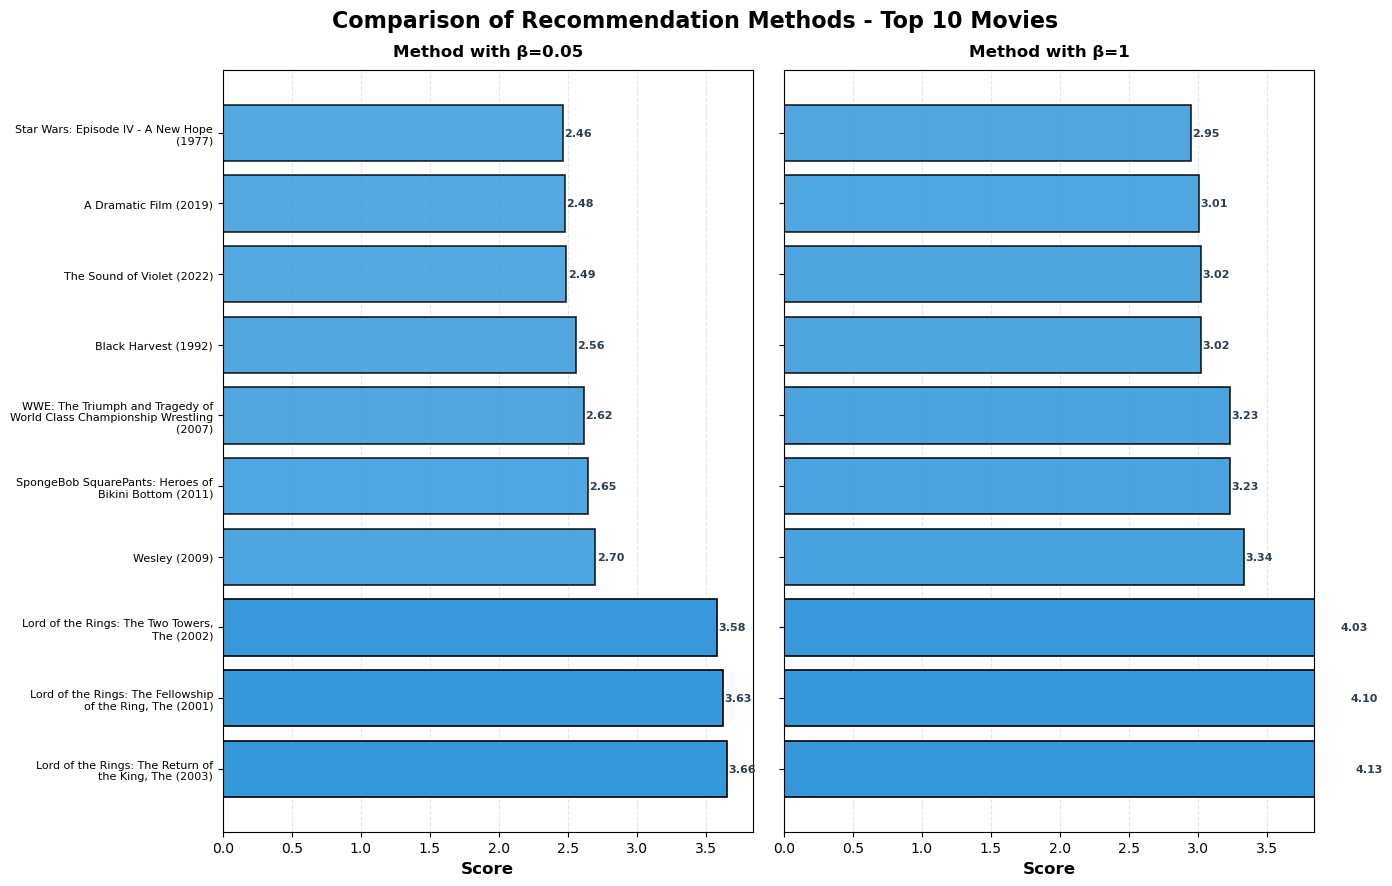


GENERATING SCORE DISTRIBUTION VISUALIZATIONS
Saved: recommendation_plots\03_distribution_Method_with_β=0.05.pdf

Method with β=0.05:
  Shapiro-Wilk W-statistic: 0.5688
  p-value: 0.0000e+00
  → Distribution deviates from NORMAL (p < 0.05)
  Skewness: 6.2511
  Kurtosis: 102.2633


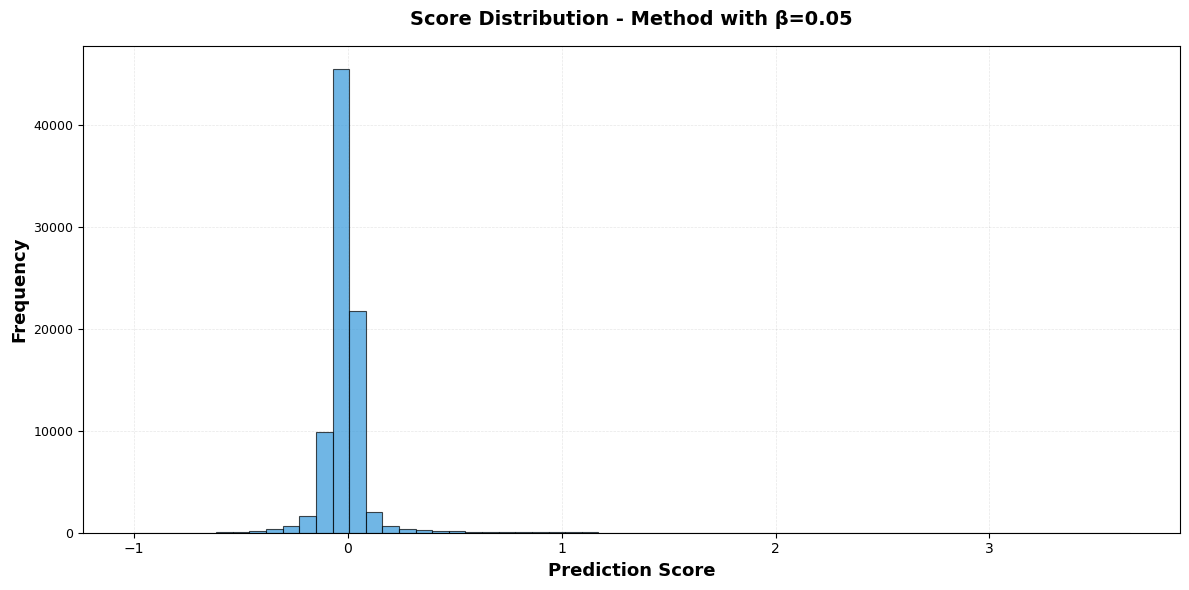

Saved: recommendation_plots\03_distribution_Method_with_β=1.pdf

Method with β=1:
  Shapiro-Wilk W-statistic: 0.9771
  p-value: 1.2889e-27
  → Distribution deviates from NORMAL (p < 0.05)
  Skewness: -0.5381
  Kurtosis: 1.4720


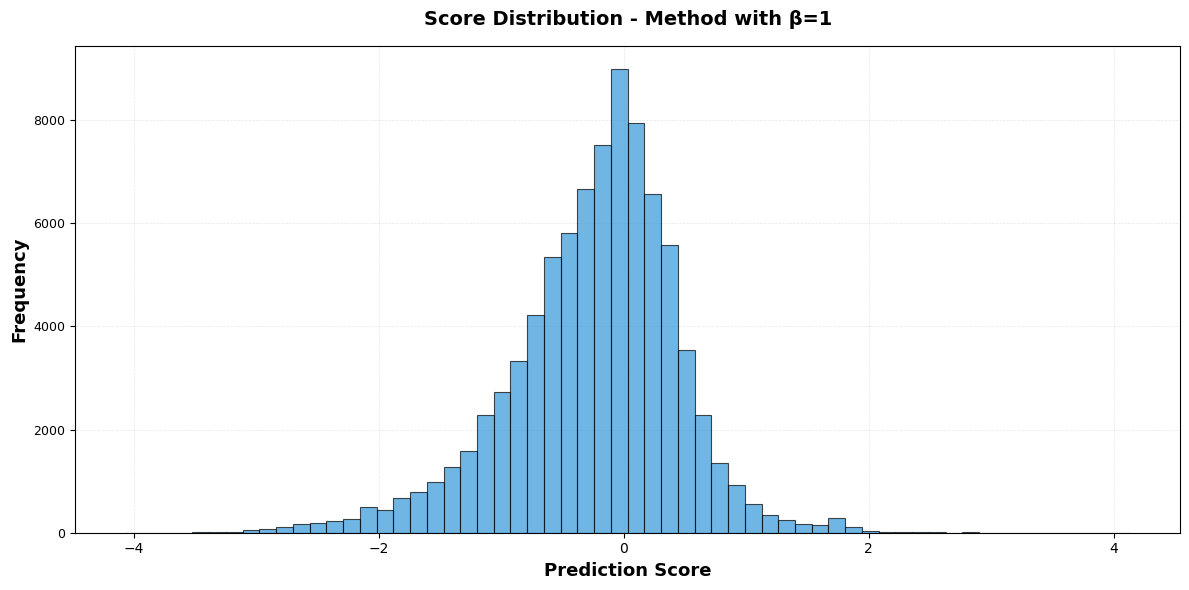


GENERATING STATISTICS SUMMARY
Saved: recommendation_plots\04_statistics_summary.pdf


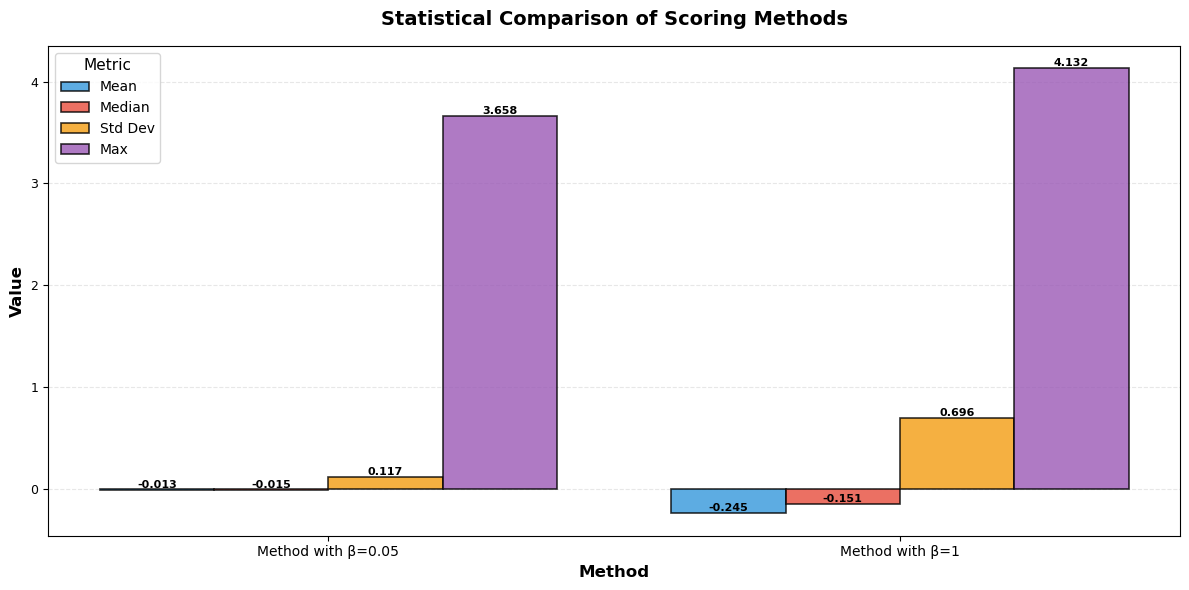


VISUALIZATION COMPLETE!

All plots saved to: recommendation_plots/

Generated files:
  1. 01_recommendations_Method_with_β0.05.pdf
  2. 01_recommendations_Method_with_β1.pdf
  3. 02_comparison_all_methods.pdf
  4. 03_distribution_Method_with_β0.05.pdf
  5. 03_distribution_Method_with_β1.pdf
  6. 04_statistics_summary.pdf


These PDFs are ready for inclusion in your report!
They can be imported in LaTeX with: \includegraphics{file.pdf}


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from textwrap import wrap
from scipy import stats
import os



# Create output directory for plots
OUTPUT_DIR = "recommendation_plots"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Set style for publication-quality plots
plt.style.use('default')  # Clean white background
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.titlesize'] = 16
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['figure.facecolor'] = 'white'

def wrap_title(title, max_width=45):
    """
    Wrap long movie titles intelligently.
    Splits at punctuation or spaces, max_width characters per line.
    """
    if len(title) <= max_width:
        return title
    
   
    if '(' in title and ')' in title:
        parts = title.split('(')
        if len(parts) == 2:
            main_title = parts[0].strip()
            year = '(' + parts[1]
            if len(main_title) <= max_width - 7:
                return main_title + '\n' + year
    
    # Otherwise use textwrap
    wrapped = '\n'.join(wrap(title, width=max_width))
    return wrapped

print("\n" + "="*80)
print("MOVIE RECOMMENDATIONS VISUALIZATION FOR REPORT")
print("="*80)

if prerequis_ok:
    try:
        target_movie_title = "Lord of the Rings: The Fellowship of the Ring"
        target_movie_id = None
        target_movie_index = None

        # Search for the movie
        for movie_id, title in movie_id_to_title.items():
            if target_movie_title in title:
                target_movie_id = movie_id
                break

        if target_movie_id and target_movie_id in movie_to_index:
            target_movie_index = movie_to_index[target_movie_id]
            print(f"\nDummy user rates '{target_movie_title}' with 5 stars")

            dummy_user_ratings = [(target_movie_index, 5.0)]
            new_user_factor, new_user_bias = fit_new_user(
                dummy_user_ratings,
                item_factors,
                item_biases,
                K,
                lambda_reg,
                tau_reg
            )

            print(f"User factors computed. User bias = {new_user_bias:.4f}")

          
            scoring_methods = {
                'Method with β=0.05': predict_all_for_user_without_user_bias(
                     new_user_factor, item_factors, new_user_bias, item_biases, 0.05
                ),
                'Method with β=1': predict_all_for_user_without_user_bias(
                    new_user_factor, item_factors, new_user_bias, item_biases, 1
                )
            }

            top_n = 10  

           
            
            method_colors = {
                'Method with β=0.05': '#3498DB',     
                'Method with β=1': '#3498DB'         
            }

           

            print(f"\n{'='*80}")
            print("GENERATING INDIVIDUAL METHOD VISUALIZATIONS")
            print(f"{'='*80}")

            for method_name, all_predictions in scoring_methods.items():
                print(f"\n{'─'*80}")
                print(f"METHOD: {method_name}")
                print(f"{'─'*80}")

                # Sort all movies by prediction score
                top_movie_indices = np.argsort(all_predictions)[::-1]

                # Find the rank of the target movie
                target_rank = np.where(top_movie_indices == target_movie_index)[0][0] + 1
                target_score = all_predictions[target_movie_index]

                print(f"'{target_movie_title}' is ranked #{target_rank} with score {target_score:.4f}")

                # Collect top N movies
                movies = []
                scores = []
                movie_ids_list = []

                shown = 0
                for i in top_movie_indices:
                    if shown >= top_n:
                        break

                    movie_id = index_to_movie[i]
                    title = movie_id_to_title.get(movie_id, "Unknown title")
                    score = all_predictions[i]

                    # Wrap long titles
                    display_title = wrap_title(title, max_width=50)

                    movies.append(display_title)
                    scores.append(score)
                    movie_ids_list.append(movie_id)

                    shown += 1

                # Create figure
                fig, ax = plt.subplots(figsize=(10, 8))
                
                base_color = method_colors[method_name]
                
                # Create horizontal bars
                y_pos = np.arange(len(movies))
                bars = ax.barh(y_pos, scores, 
                              color=base_color, 
                              alpha=0.8,
                              edgecolor='black',
                              linewidth=1.5)
                
                # Add gradient effect to bars
                for bar, score in zip(bars, scores):
                    bar.set_alpha(0.5 + 0.5 * (score / max(scores)))
                
                # Add score labels on bars
                for i, (bar, score) in enumerate(zip(bars, scores)):
                    width = bar.get_width()
                    ax.text(width + 0.02, bar.get_y() + bar.get_height()/2,
                           f'{score:.3f}',
                           ha='left', va='center',
                           fontweight='bold',
                           fontsize=10,
                           color='#2C3E50')
                
                # Customize plot
                ax.set_yticks(y_pos)
                ax.set_yticklabels(movies)
                ax.invert_yaxis()  # Highest score on top
                ax.set_xlabel('Prediction Score', fontweight='bold', fontsize=12)
                ax.set_title(f'Top {top_n} Movie Recommendations\nMethod: {method_name}',
                            fontweight='bold', fontsize=14, pad=20)
                
                # Add grid
                ax.grid(True, axis='x', alpha=0.3, linestyle='--')
                ax.set_axisbelow(True)
                
                plt.tight_layout()
                
                # Save as PDF
                safe_method_name = method_name.replace('/', '_').replace(' ', '_').replace('(', '').replace(')', '')
                pdf_path = os.path.join(OUTPUT_DIR, f'01_recommendations_{safe_method_name}.pdf')
                plt.savefig(pdf_path, format='pdf', dpi=300, bbox_inches='tight')
                print(f"Saved: {pdf_path}")
                
                plt.show()
                plt.close()

                # Print text summary
                print(f"\nTop {top_n} recommendations:")
                for rank, (movie, score) in enumerate(zip(movies, scores), 1):
                    movie_single_line = movie.replace('\n', ' ')
                    print(f"  {rank:2d}. {movie_single_line:<50} | Score: {score:.4f}")

         

            print(f"\n{'='*80}")
            print("GENERATING COMPARISON VISUALIZATION")
            print(f"{'='*80}")

          
            comparison_data = {}
            
            for method_name, all_predictions in scoring_methods.items():
                top_movie_indices = np.argsort(all_predictions)[::-1]
                
                movies_list = []
                scores_list = []
                
                shown = 0
                for i in top_movie_indices:
                    if shown >= top_n:
                        break

                    movie_id = index_to_movie[i]
                    title = movie_id_to_title.get(movie_id, "Unknown title")
                    score = all_predictions[i]

                    # Wrap title (shorter for 3-column layout)
                    display_title = wrap_title(title, max_width=35)

                    movies_list.append(display_title)
                    scores_list.append(score)
                    shown += 1

                comparison_data[method_name] = {
                    'movies': movies_list,
                    'scores': scores_list
                }

            # Create subplots
            fig, axes = plt.subplots(1, 2, figsize=(14, 9), sharey=True)
            fig.suptitle(f'Comparison of Recommendation Methods - Top {top_n} Movies',
                        fontweight='bold', fontsize=16, y=0.98)

            # Plot each method
            for idx, (method_name, data) in enumerate(comparison_data.items()):
                ax = axes[idx]
                movies = data['movies']
                scores = data['scores']
                
                base_color = method_colors[method_name]
                
                # Create bars
                y_pos = np.arange(len(movies))
                bars = ax.barh(y_pos, scores,
                              color=base_color,
                              alpha=0.75,
                              edgecolor='black',
                              linewidth=1.2)
                
                # Add gradient
                for bar, score in zip(bars, scores):
                    bar.set_alpha(0.5 + 0.5 * (score / max(scores)))
                
                # Add score labels
                for i, (bar, score) in enumerate(zip(bars, scores)):
                    width = bar.get_width()
                    ax.text(width + 0.01, bar.get_y() + bar.get_height()/2,
                           f'{score:.2f}',
                           ha='left', va='center',
                           fontsize=8,
                           fontweight='bold',
                           color='#2C3E50')
                
                # Customize
                ax.set_yticks(y_pos)
                ax.set_yticklabels(movies, fontsize=8)
                ax.invert_yaxis()
                ax.set_xlabel('Score', fontweight='bold')
                ax.set_title(method_name, fontweight='bold', fontsize=12, pad=10)
                ax.grid(True, axis='x', alpha=0.3, linestyle='--')
                ax.set_axisbelow(True)
                
                # Set consistent x-axis limits
                if idx > 0:
                    ax.set_xlim(axes[0].get_xlim())
            
            plt.tight_layout()
            
            # Save
            pdf_path = os.path.join(OUTPUT_DIR, '02_comparison_all_methods.pdf')
            plt.savefig(pdf_path, format='pdf', dpi=300, bbox_inches='tight')
            print(f"Saved: {pdf_path}")
            
            plt.show()
            plt.close()

         

            print(f"\n{'='*80}")
            print("GENERATING SCORE DISTRIBUTION VISUALIZATIONS")
            print(f"{'='*80}")

            for method_name, all_predictions in scoring_methods.items():
                fig, ax = plt.subplots(figsize=(12, 6))
                
                base_color = method_colors[method_name]
                
                # Create histogram only
                n, bins, patches = ax.hist(all_predictions, bins=60, 
                                          color=base_color,
                                          alpha=0.7,
                                          edgecolor='black',
                                          linewidth=0.8)
                
                # Statistics for console output
                mean_val = np.mean(all_predictions)
                median_val = np.median(all_predictions)
                std_val = np.std(all_predictions)
                
                # Perform normality test (Shapiro-Wilk)
                sample_size = min(5000, len(all_predictions))
                sample = np.random.choice(all_predictions, sample_size, replace=False)
                statistic, p_value = stats.shapiro(sample)
                
                # Customize plot
                ax.set_xlabel('Prediction Score', fontweight='bold', fontsize=13)
                ax.set_ylabel('Frequency', fontweight='bold', fontsize=13)
                ax.set_title(f'Score Distribution - {method_name}',
                           fontweight='bold', fontsize=14, pad=15)
                
                ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
                ax.set_axisbelow(True)
                
                plt.tight_layout()
                
                # Save
                safe_method_name = method_name.replace('/', '_').replace(' ', '_').replace('(', '').replace(')', '')
                pdf_path = os.path.join(OUTPUT_DIR, f'03_distribution_{safe_method_name}.pdf')
                plt.savefig(pdf_path, format='pdf', dpi=300, bbox_inches='tight')
                print(f"Saved: {pdf_path}")
                
                # Print interpretation
                print(f"\n{method_name}:")
                print(f"  Shapiro-Wilk W-statistic: {statistic:.4f}")
                print(f"  p-value: {p_value:.4e}")
                if p_value > 0.05:
                    print(f"  → Distribution appears to be NORMAL (p > 0.05)")
                else:
                    print(f"  → Distribution deviates from NORMAL (p < 0.05)")
                print(f"  Skewness: {stats.skew(all_predictions):.4f}")
                print(f"  Kurtosis: {stats.kurtosis(all_predictions):.4f}")
                
                plt.show()
                plt.close()

      

            print(f"\n{'='*80}")
            print("GENERATING STATISTICS SUMMARY")
            print(f"{'='*80}")

            # Compute statistics
            stats_data = []
            for method_name, all_predictions in scoring_methods.items():
                stats_data.append({
                    'Method': method_name,
                    'Mean': np.mean(all_predictions),
                    'Median': np.median(all_predictions),
                    'Std Dev': np.std(all_predictions),
                    'Min': np.min(all_predictions),
                    'Max': np.max(all_predictions)
                })

            # Create grouped bar chart
            fig, ax = plt.subplots(figsize=(12, 6))

            metrics = ['Mean', 'Median', 'Std Dev', 'Max']
            x = np.arange(len(scoring_methods))
            width = 0.2
            
            colors_metrics = ['#3498DB', '#E74C3C', '#F39C12', '#9B59B6']

            for i, metric in enumerate(metrics):
                values = [s[metric] for s in stats_data]
                bars = ax.bar(x + i * width, values, width,
                             label=metric,
                             color=colors_metrics[i],
                             alpha=0.8,
                             edgecolor='black',
                             linewidth=1.2)
                
                # Add value labels
                for bar in bars:
                    height = bar.get_height()
                    ax.text(bar.get_x() + bar.get_width()/2., height,
                           f'{height:.3f}',
                           ha='center', va='bottom',
                           fontsize=8, fontweight='bold')

            ax.set_xlabel('Method', fontweight='bold', fontsize=12)
            ax.set_ylabel('Value', fontweight='bold', fontsize=12)
            ax.set_title('Statistical Comparison of Scoring Methods',
                        fontweight='bold', fontsize=14, pad=15)
            ax.set_xticks(x + width * 1.5)
            ax.set_xticklabels([s['Method'] for s in stats_data], fontsize=10)
            ax.legend(title='Metric', loc='upper left', fontsize=10, title_fontsize=11)
            ax.grid(True, axis='y', alpha=0.3, linestyle='--')
            ax.set_axisbelow(True)
            
            plt.tight_layout()
            
            pdf_path = os.path.join(OUTPUT_DIR, '04_statistics_summary.pdf')
            plt.savefig(pdf_path, format='pdf', dpi=300, bbox_inches='tight')
            print(f"Saved: {pdf_path}")
            
            plt.show()
            plt.close()

          

            print(f"\n{'='*80}")
            print("VISUALIZATION COMPLETE!")
            print(f"{'='*80}")
            print(f"\nAll plots saved to: {OUTPUT_DIR}/")
            print("\nGenerated files:")
            print("  1. 01_recommendations_Method_with_β0.05.pdf")
            print("  2. 01_recommendations_Method_with_β1.pdf")
            print("  3. 02_comparison_all_methods.pdf")
            print("  4. 03_distribution_Method_with_β0.05.pdf")
            print("  5. 03_distribution_Method_with_β1.pdf")
            print("  6. 04_statistics_summary.pdf")
            print(f"\n{'='*80}")
            print("\nThese PDFs are ready for inclusion in your report!")
            print("They can be imported in LaTeX with: \\includegraphics{file.pdf}")

        else:
            print(f"Movie not found: '{target_movie_title}'")

    except Exception as e:
        print(f"Error in visualization: {e}")
        import traceback
        traceback.print_exc()

else:
    print("Prerequisites not met. Please ensure all required variables are defined.")

## Embeding representations